# 📓 Cas d'usage IA — Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle

**Auteur·e** : `Joelle Germanos`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `25/08/2026`  
**Dernière mise à jour** : `04/10/2026`


>⚠️  Le lien ci-dessous renvoie vers mon dépôt GitHub. Le notebook est exécutable uniquement avec l'ensemble du code et des fichiers présents dans ce dépôt.
> https://github.com/joellegermanos-prog/ia-atos-simplon-certification-joellegermanos.git

## 0. Imports & configuration

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import shap
import joblib
import pytest

from scipy import sparse
from IPython.display import display
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    recall_score, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight
%matplotlib inline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.insert(0, str(Path.cwd().parent / "src"))

import importlib
import evaluation_utils
import reporting
import evaluate
import config

from config import (
    DATA_PATH,
    MODELS_DIR,
    PROJECT_ROOT,
    RANDOM_STATE,
    REPORTS_DIR,
    SCENARIOS,
    TEST_SIZE,
)

from evaluate import evaluate_requested_models

from preprocess import (
    BASE_CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    ORDINAL_FEATURES,
    SENSITIVE_FEATURES,
    TEXT_FEATURE,
    build_preprocessor,
    get_all_features,
    get_categorical_features,
    get_numeric_features,
    get_ordinal_features,
    load_dataset,
)

from reporting import create_benchmark, print_benchmark

from train import (
    load_scenario_dataset,
    print_training_summary,
    split_train_holdout,
    train_requested_models,
    fit_pipeline_with_text_fallback,
)

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)

Python : 3.12.10
Pandas : 2.2.2


## 0.5 Traçabilité de la session

In [2]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi"          
DATASET_SOURCE = "../data/dataset_trajectoire_emploi.csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "2026-08-14"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-10-05T01:30
Python       : 3.12.10
NumPy        : 1.26.4
Pandas       : 2.2.2
Git commit   : dfa1c49
Dataset      : dataset_trajectoire_emploi (source=../data/dataset_trajectoire_emploi.csv, version=2026-08-14)


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une agence nationale de l'emploi (service public). L'optimisation des politiques publiques de l'emploi et le développement d'outils d'aide à la décision imposent la mise en place de solutions d'aiguillage rapides et fiables.   
L'enjeu métier est de classer avec précision le délai potentiel de retour à l'emploi des usagers dès le premier entretien de cadrage. L'agence souhaite en particulier identifier les situations présentant un risque d'inactivité de longue durée (plus de 12 mois) afin d'éviter de priver ces usagers d'un accompagnement renforcé indispensable. 
Le recours à l'IA est motivé par la nécessité d'assister les conseillers avec un système d'aide à la décision capable d'exploiter des données hybrides et hétérogènes (numériques, catégorielles et synthèses textuelles rédigées lors des entretiens).

### 1.2 Énoncé du problème IA

Le problème se formule comme une tâche d'apprentissage supervisé de **classification multiclasse à 3 catégories distinctes**. 

L'objectif est de prédire la classe de délai potentiel de retour à l'emploi d'un usager à partir d'un ensemble de données d'entrée hybrides comprenant des variables tabulaires (socio-professionnelles, administratives, géographiques) et du texte libre (synthèse rédigée lors du premier entretien).

- **Variable cible** : `classe_retour_emploi`.
  - **Classe 0 (Rapide)** : Retour à l'emploi en moins de 6 mois.
  - **Classe 1 (Moyen)** : Retour à l'emploi entre 6 et 12 mois.
  - **Classe 2 (Risque)** : Risque de chômage de longue durée supérieur à 12 mois.

- **Variables explicatives** :
  - **Données tabulaires** : `age`, `niveau_diplome`, `anciennete_poste_ans`, `code_rome_vise`, `code_insee_commune`, `est_allocataire`, `nationalite_hors_ue`.
  - **Données textuelles** : `synthese_entretien` (notes rédigées par le conseiller). 

### 1.3 Bénéficiaires & impacts

- **Bénéficiaires directs** : Les **conseillers à l'emploi**, qui utilisent la solution comme un outil d'aide à la décision lors de l'entretien d'orientation.
- **Bénéficiaires indirects** :
  - Les **usagers (demandeurs d'emploi)**, réorientés de façon adaptée selon leur niveau de risque.
  - L'**agence nationale de l'emploi**, qui optimise la gestion et l'attribution de ses ressources d'accompagnement.
- **Impacts des erreurs de prédiction** :
  - **Erreur critique** : Classer à tort une situation de risque élevé (chômage de longue durée) en niveau de risque nul (retour rapide). Cela prive l'usager d'un accompagnement renforcé indispensable, générant un préjudice humain grave et un coût financier important.
  - **Erreurs secondaires** : mal évaluer un niveau de risque sans passer de la classe 2 à la classe 0. L'erreur 2→1 (risque longue durée classé « moyen ») est supposée moins grave que 2→0, car l'usager reçoit un suivi intermédiaire. Cette hypothèse est posée en phase de cadrage, sans données chiffrées sur l'efficacité du dispositif « moyen » pour des publics à risque.
        
### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA et §7.2| Justification de la révision |
|---|---|---|---|---|
| **Métier** | Réduction des erreurs critiques (Classe 2 prédite en Classe 0) | Taux d'erreurs critiques $5\%$ |Taux d'erreurs critiques $< 8.5\%$ | Cible initiale. La cible de 5 % exigerait un seuil de 0,75, soit 64,5 % d'abstention, incompatible avec la capacité de revue (≤ 30 %). Elle a donc été révisée à 8,5 %. |
| **Modèle** | Accuracy, F1-score macro et Matrice de confusion | Maximisation de l'Accuracy et du F1-score macro | Équilibre du F1-score macro avec focalisation prioritaire sur le Rappel (Recall) de la classe 2 | Le déséquilibre de la cible et les valeurs manquantes imposent de favoriser la détection de la classe minoritaire à risque pour limiter les faux négatifs critiques ($2 \to 0$).|
| **Opérationnel** | Temps de réponse de l'API (inférence en entretien) | Latence adaptée à un entretien en face-à-face | Temps de réponse API $< 500\text{ ms}$ (requête HTTP POST) | Nécessaire pour traiter les données hybrides sans ralentir l'échange avec l'usager. |

### 1.5 Risques éthiques & réglementaires anticipés

**Variables sensibles et risques de discrimination**

- **Nationalité** : la variable `nationalite_hors_ue` est susceptible d'introduire une discrimination directe ou indirecte. Son utilisation doit faire l'objet d'une justification explicite et d'une analyse d'impact. Dans une démarche de réduction des biais, son retrait et l'évaluation de son effet sur les performances du modèle doivent être documentés.

- **Âge** : la variable `age` constitue une donnée liée à un critère protégé contre les discriminations. Son utilisation peut conduire à des traitements différenciés entre groupes d'âge. L'impact de cette variable doit être évalué au moyen d'analyses de fairness afin de vérifier l'absence de biais significatifs.

**Biais liés aux données textuelles**

- **Verbatims d'entretien** : la variable `synthese_entretien` contient des commentaires rédigés par les conseillers. Ces textes peuvent refléter des appréciations subjectives, des biais cognitifs ou des pratiques de saisie hétérogènes. Ils peuvent également contenir indirectement des informations corrélées à des caractéristiques protégées et influencer les prédictions du modèle.

**Conformité au RGPD**

- Le traitement repose sur plusieurs données à caractère personnel (âge, situation administrative, localisation géographique, synthèses d'entretien). À ce titre, il doit respecter les principes fondamentaux du RGPD, notamment :
  - la **minimisation des données** (ne collecter et n'utiliser que les données strictement nécessaires à la finalité poursuivie) ;
  - la **transparence** vis-à-vis des personnes concernées ;
  - la **traçabilité** des traitements et des décisions produites par le système.

**Transparence des décisions algorithmiques**

- L'utilisation d'un modèle d'IA dans un contexte de service public impose une attention particulière à l'explicabilité des résultats et à la capacité de justifier les recommandations produites. Les décisions finales doivent rester compréhensibles, documentées et sous contrôle humain.

### 1.6 📝 Synthèse cadrage

Ce projet répond au besoin d'une agence nationale de l'emploi d'orienter 2 500 usagers via une classification supervisée à 3 classes (rapide, moyen, risque de longue durée) à partir de données hybrides tabulaires et textuelles (`synthese_entretien`). 

Le **critère de succès** dominant est la réduction de l'erreur critique — classer à tort un risque de longue durée (niveau 2) en retour rapide (niveau 0) —, qui prive l'usager d'un accompagnement renforcé indispensable et engendre un coût humain et financier grave. 

Le **principal risque éthique identifié** réside dans la présence de variables protégées (`nationalite_hors_ue`, `age`) et de variables proxy susceptibles d'introduire une discrimination directe ou indirecte dans la prédiction. Dans ce contexte, la solution relève d'un système d'IA à haut risque au sens de l'AI Act (domaine de l'accès à l'emploi), ce qui impose une supervision humaine effective du conseiller lors de l'orientation plutôt qu'une automatisation intégrale de la décision.

---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| *Agence nationale de l'emploi* | *CSV* | *2 500 lignes × 10 colonnes* | *csv* | *lecture seule* | *version=2026-08-14* |


#### 2.2 Chargement

In [3]:
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "dataset_trajectoire_emploi.csv"

if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable. Vérifier le chemin ../data/dataset_trajectoire_emploi.csv")

df = pd.read_csv(RAW_PATH)

print(f"Fichier : {RAW_PATH}")
print("Dimensions :", df.shape)
print("Variables :", df.columns.tolist())

Fichier : ..\data\dataset_trajectoire_emploi.csv
Dimensions : (2500, 10)
Variables : ['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | Identifiant unique du demandeur d'emploi | Catégoriel (identifiant) | 2500 valeurs uniques | ❌ | ⚠️ Identifiant : risque d'identification si croisé avec une autre source |
| `age` | Âge de l'usager en années | Numérique | 18 – 63 ans | ❌ | ✅ Critère protégé contre la discrimination (article 225-1 du Code pénal)|
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégoriel ordinal | Sans diplôme / Bac / Bac+2 / Bac+5 | ❌ | ⚠️ Proxy socio-économique |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique | 0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégoriel nominal, cardinalité faible à modéré | 50 modalités (ex: D1503, G1302…), cardinalité faible à modérée| ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégoriel nominal, haute cardinalité | Ensemble de codes INSEE à 5 chiffres (haute cardinalité) | ❌ | ⚠️ Proxy socio-économique et territorial|
| `est_allocataire` | Statut d'indemnisation de l'usager | Catégoriel binaire | 1 (Oui), 0 (Non) | ❌ | ⚠️ Proxy de socio-économique |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | Catégoriel binaire | 1 = hors UE, 0 = UE | ❌ | ✅ Critère protégé contre la discrimination (article 225-1 du Code pénal)|
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte libre | Texte libre de longueur variable (notes du conseiller) | ❌ | ⚠️ Peut contenir des données sensibles non structurées - à vérifier |
| `classe_retour_emploi` | Classe de délai de retour à l'emploi constatée | Catégoriel (cible) | 0 : <6 mois  / 1 : 6-12 mois / 2 : >12 mois | ✅ | ❌ |

### 2.4 📝 Synthèse acquisition

**Origine et volumétrie**
* **Origine des données** : Extraction du système d'information opérationnel de suivi des demandeurs d'emploi (historique des parcours usagers et verbatims saisis par les conseillers).
* **Volumétrie** : Échantillon de **2 500 usagers** comportant **10 variables** (9 variables explicatives de nature hybride et 1 variable cible).

**Qualité apparente et choix de préparation des données**
* **Variables structurées** : Les variables numériques (`age`, `anciennete_poste_ans`) et binaires (`est_allocataire`, `nationalite_hors_ue`) présentent une structure immédiatement exploitable.
* **Gestion de la cardinalité** :
  * `code_insee_commune` : **Très haute cardinalité** (quasi-identifiant), nécessitant une extraction géographique (département/région) pour éviter le surapprentissage.
  * `code_rome_vise` : **Cardinalité faible à modérée** (50 modalités). Le choix est fait de **conserver les 50 codes bruts** afin de maintenir la finesse métier.
* **Données textuelles** : La variable `synthese_entretien` (texte libre) nécessite un traitement NLP (nettoyage, détection d'entités) avant modélisation.

**Variables sensibles et éthiques repérées**
* **Variables protégées (cadre légal)** : `age` et `nationalite_hors_ue` constituent des critères de discrimination prohibés (art. 225-1 du Code pénal) et sont strictement encadrées par le RGPD et l'AI Act.
* **Proxies socio-économiques** : `code_insee_commune`, `niveau_diplome` et `est_allocataire` peuvent refléter indirectement des fragilités territoriales ou financières, imposant un suivi de l'équité (*fairness*) du modèle.
* **Données non structurées à risque** : Le champ `synthese_entretien` peut contenir des mentions indirectes relatives à la vie privée ou à la santé des usagers.

---
## 3. Exploration & analyse des données (EDA)

### 3.1 Premier coup d'œil

In [4]:
display(df.head())
display(df.info())
display(df.describe(include="all").T)
print("Colonnes du dataset :")
print(df.columns.tolist())

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usager_id,2500,2500,ID_0000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2378.0,NaN,NaN,NaN,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
niveau_diplome,2416,4,Bac,966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_poste_ans,2500.0,NaN,NaN,NaN,2.9716,2.979548,0.0,0.8,2.0,4.1,22.6
code_rome_vise,2500,50,H1206,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_insee_commune,2500,2407,34045,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est_allocataire,2456.0,NaN,NaN,NaN,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,NaN,NaN,NaN,0.118,0.322673,0.0,0.0,0.0,0.0,1.0
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe_retour_emploi,2500.0,NaN,NaN,NaN,0.8064,0.719671,0.0,0.0,1.0,1.0,2.0


Colonnes du dataset :
['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 3.2 Qualité des données 

#### 3.2.1 Qualité des données : manquants et doublons

In [5]:
missing = pd.DataFrame({
    "Valeurs manquantes": df.isna().sum(),
    "Pourcentage (%)": (100 * df.isna().mean()).round(2).astype(str) + " %"
}).sort_values("Valeurs manquantes", ascending=False)

display(missing)

print("Nombre de doublons :", df.duplicated().sum())
print("Nombre d'identifiants usager dupliqués :", df["usager_id"].duplicated().sum())

,Valeurs manquantes,Pourcentage (%)
age,122,4.88 %
niveau_diplome,84,3.36 %
synthese_entretien,81,3.24 %
est_allocataire,44,1.76 %
usager_id,0,0.0 %
anciennete_poste_ans,0,0.0 %
code_rome_vise,0,0.0 %
code_insee_commune,0,0.0 %
nationalite_hors_ue,0,0.0 %
classe_retour_emploi,0,0.0 %


Nombre de doublons : 0
Nombre d'identifiants usager dupliqués : 0


#### 3.2.2 Détection des valeurs aberrantes (méthode IQR) sur les variables numériques

In [6]:
def detect_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ["age", "anciennete_poste_ans"]:
    outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
    print(f"\n--- {col} ---")
    print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre de valeurs : {len(outliers)} ({len(outliers)/df[col].notna().sum()*100:.2f} %)")
    if len(outliers) > 0:
        print(outliers.sort_values(ascending=False).head(10))


--- age ---
Bornes IQR : [-5.50, 86.50]
Nombre de valeurs : 0 (0.00 %)

--- anciennete_poste_ans ---
Bornes IQR : [-4.15, 9.05]
Nombre de valeurs : 126 (5.04 %)
1875    22.6
1540    22.0
1075    20.2
2277    19.6
8       18.3
1313    18.2
311     17.4
2203    17.3
214     17.0
1582    16.7
Name: anciennete_poste_ans, dtype: float64


>📝 **Synthèse(§3.2)**
>- Valeurs manquantes modérées sur 4 variables sur 10 (`age` ~4,9 %, `niveau_diplome` ~3,4 %,
  `est_allocataire` ~1,8 %, `synthese_entretien` ~3,2 %), taux ne remettant pas en cause
  l'exploitabilité du dataset, mais nécessitant une stratégie d'imputation explicite en **§4**.
>- Aucun doublon exact détecté, ni sur l'ensemble des colonnes ni sur `usager_id`.
>- La détection IQR ne révèle aucun outlier sur `age` — les valeurs extrêmes (18-63 ans) restent dans des plages parfaitement plausibles.
Sur `anciennete_poste_ans`, en revanche, la détection IQR révèle un nombre important d'outliers au-delà de ~9 ans (jusqu'à 22,6 ans d'ancienneté)
126 observations sont identifiées comme valeurs extrêmes selon la règle IQR. Elles ne sont pas supprimées à ce stade, car elles peuvent correspondre à des situations réelles et devront être examinées au regard des contraintes métier.

### 3.3 Distribution des variables

#### 3.3.1 Distribution des variables numériques

Âge :


count    2378.000000
mean       40.566442
std        13.225242
min        18.000000
25%        29.000000
50%        41.000000
75%        52.000000
max        63.000000
Name: age, dtype: float64


Ancienneté :


count    2500.000000
mean        2.971600
std         2.979548
min         0.000000
25%         0.800000
50%         2.000000
75%         4.100000
max        22.600000
Name: anciennete_poste_ans, dtype: float64

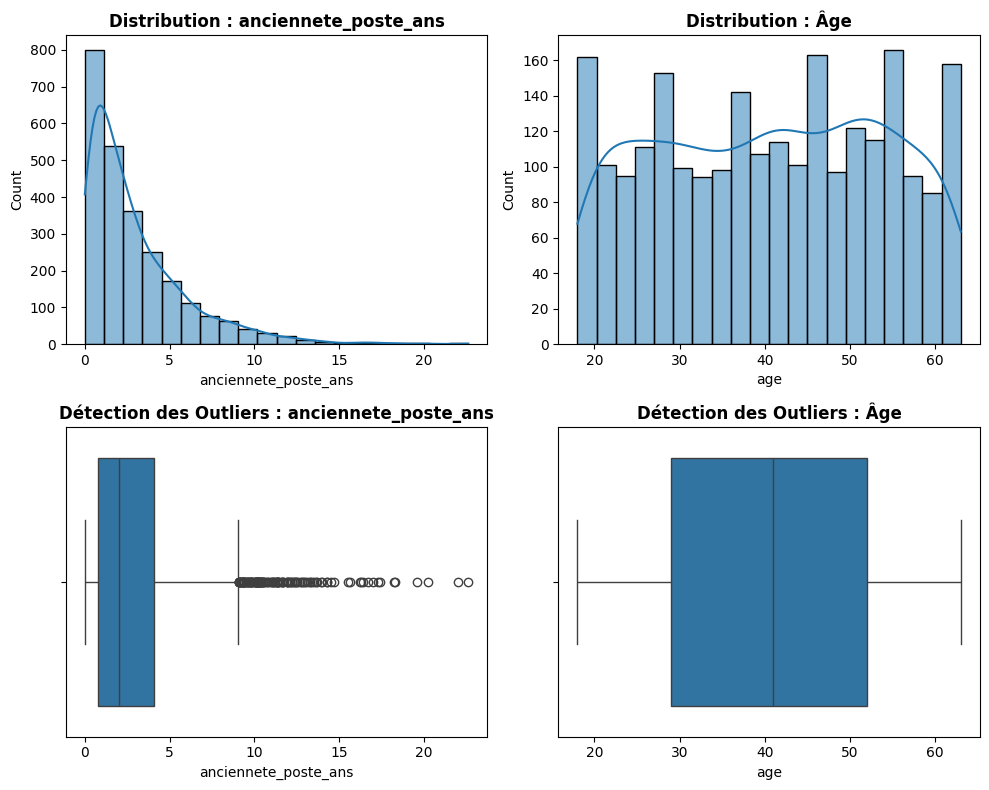

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0, 0])

axes[0, 1].set_title("Distribution : Âge", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0, 1])

axes[1, 0].set_title("Détection des Outliers : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])

axes[1, 1].set_title("Détection des Outliers : Âge", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="age", ax=axes[1, 1])

plt.tight_layout()

print("Âge :")
display(df["age"].describe())
print("\nAncienneté :")

display(df["anciennete_poste_ans"].describe())

#### 3.3.2 Analyse des variables catégorielles

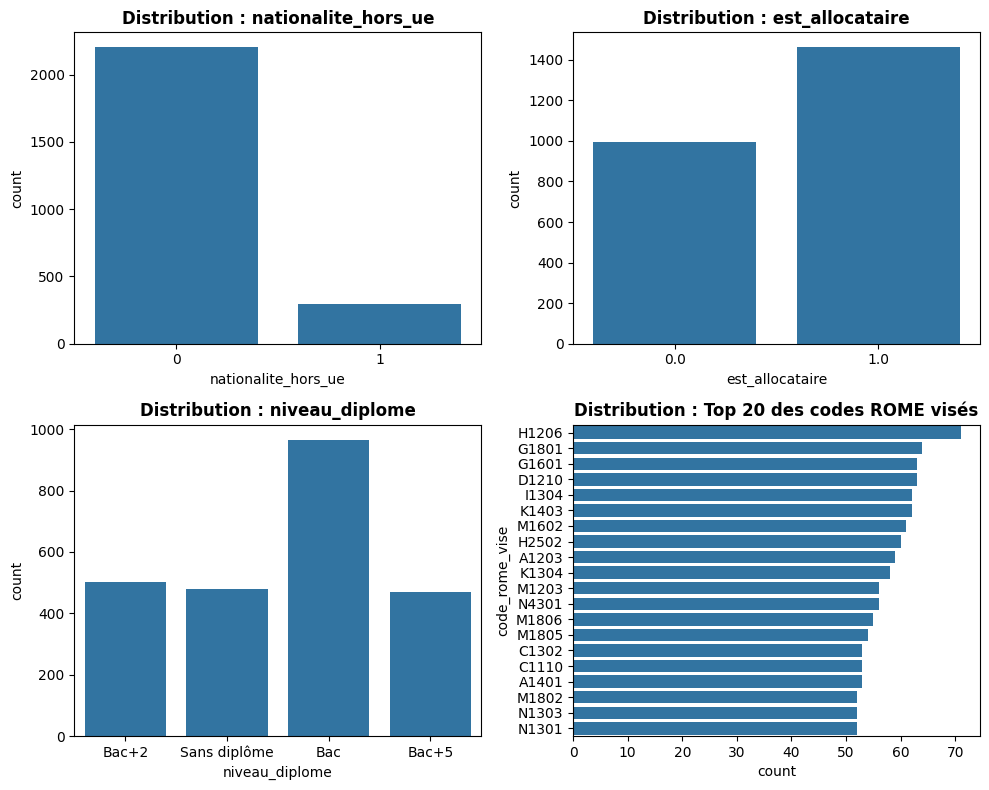

Répartition nationalite_hors_ue :
nationalite_hors_ue
0    0.882
1    0.118
Name: proportion, dtype: float64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : nationalite_hors_ue", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="nationalite_hors_ue", ax=axes[0, 0])

axes[0, 1].set_title("Distribution : est_allocataire", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="est_allocataire", ax=axes[0, 1])

axes[1, 0].set_title("Distribution : niveau_diplome", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="niveau_diplome", ax=axes[1, 0])

top10_rome = df["code_rome_vise"].value_counts().head(20).index
axes[1, 1].set_title("Distribution : Top 20 des codes ROME visés", fontsize=12, fontweight="bold")
sns.countplot(data=df, y="code_rome_vise", order=top10_rome, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Répartition nationalite_hors_ue :")
print(df["nationalite_hors_ue"].value_counts(normalize=True).round(3))

#### 3.3.3 Analyse de la variable textuelle

In [9]:
# Échantillon à l'œil nu
print("\nÉchantillon de 10 synthèses d'entretien :")
for texte in df["synthese_entretien"].dropna().sample(10, random_state=RANDOM_STATE):
    print("-", texte)


Échantillon de 10 synthèses d'entretien :
- Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.
- Candidat très dynamique, mobilité nationale validée. Projet clair.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Perte de confiance importante. Risque d'exclusion, barrière de la langue.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Problème ponctuel de mobilité géographique. Zone mal desservie.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.


In [10]:
# Valeurs manquantes / vides
n_na = df["synthese_entretien"].isna().sum()
n_vide = (df["synthese_entretien"].fillna("").str.strip() == "").sum()
print(f"Valeurs manquantes : {n_na} ({n_na/len(df)*100:.1f} %)")
print(f"Chaînes vides ou blanches : {n_vide}")

Valeurs manquantes : 81 (3.2 %)
Chaînes vides ou blanches : 81


Textes uniques : 9
Doublons de texte (hors vides) : 2410



synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
NaN                                                                               81
Name: count, dtype: int64

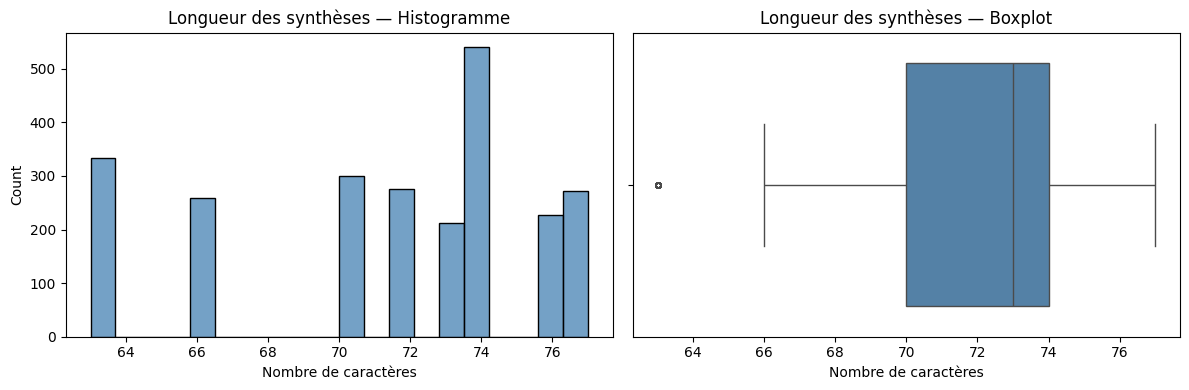

count    2419.000000
mean       71.338570
std         4.516476
min        63.000000
25%        70.000000
50%        73.000000
75%        74.000000
max        77.000000
Name: texte_len, dtype: float64


In [11]:
# Doublons
n_unique_text = df["synthese_entretien"].nunique(dropna=True)
n_dup_text = df["synthese_entretien"].dropna().duplicated().sum()

print(f"Textes uniques : {n_unique_text}")
print(f"Doublons de texte (hors vides) : {n_dup_text}\n")
display(df["synthese_entretien"].value_counts(dropna=False).head(15))

df["texte_len"] = df["synthese_entretien"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["texte_len"].dropna(), bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Longueur des synthèses — Histogramme")
axes[0].set_xlabel("Nombre de caractères")

sns.boxplot(x=df["texte_len"].dropna(), ax=axes[1], color="steelblue", fliersize=4)
axes[1].set_title("Longueur des synthèses — Boxplot")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

print(df["texte_len"].describe())

#### 3.3.4 Exploration de regroupements potentiels

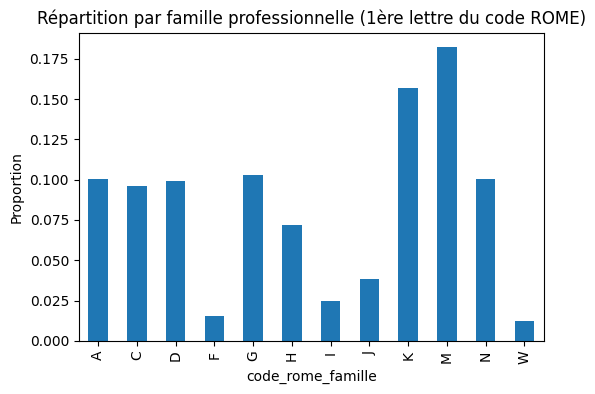

ROME uniques      : 50
Familles ROME     : 12


In [12]:
# Répartition par famille professionnelle (1ère lettre du code ROME)
df["code_rome_famille"] = df["code_rome_vise"].str[0]

# Visualisation complémentaire : répartition par famille
plt.figure(figsize=(6, 4))
df["code_rome_famille"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Répartition par famille professionnelle (1ère lettre du code ROME)")
plt.ylabel("Proportion")
plt.show()
print("ROME uniques      :", df["code_rome_vise"].nunique())
print("Familles ROME     :", df["code_rome_famille"].nunique())

In [13]:
df["groupe_age"] = pd.cut(
    df["age"], bins=[0, 25, 45, 100],
    labels=["=<25", "26-45", ">45"]
)

distribution = df["groupe_age"].value_counts().reindex(["=<25", "26-45", ">45"])
distribution_pct = df["groupe_age"].value_counts(normalize=True).reindex(["=<25", "26-45", ">45"]) * 100

tableau = pd.DataFrame({
    "effectif": distribution,
    "pourcentage": distribution_pct.round(1)
})
print(tableau)

            effectif  pourcentage
groupe_age                       
=<25             421         17.7
26-45           1008         42.4
>45              949         39.9


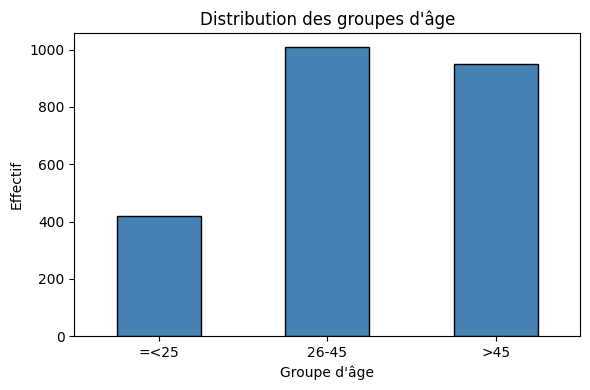

In [14]:
ordre = ["=<25", "26-45", ">45"]
distribution = df["groupe_age"].value_counts().reindex(ordre)

plt.figure(figsize=(6, 4))
distribution.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution des groupes d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nombre de départements     : 96


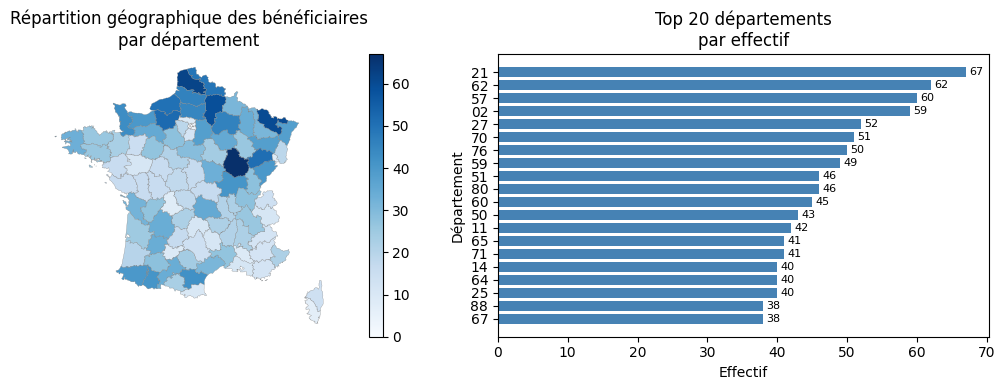

In [15]:
# Carte de répartition géographique : département + Top 20

# Comme code_insee_commune contient généralement les 5 chiffres INSEE
df["code_insee_commune"] = df["code_insee_commune"].astype(str).str.zfill(5)
df["departement"] = df["code_insee_commune"].astype(str).str[:2]
print("Nombre de départements     :", df["departement"].nunique())

# Correction DROM (codes à 3 chiffres tronqués par le str[:2])
is_drom = df["code_insee_commune"].astype(str).str.startswith("97")
df.loc[is_drom, "departement"] = df["code_insee_commune"].astype(str).str[:3]

# --- Effectifs par département ---
dep_counts = df["departement"].value_counts().reset_index()
dep_counts.columns = ["code", "effectif"]

# --- Chargement du fond de carte départemental ---
# !pip install geopandas
france = gpd.read_file("../data/departements.geojson")

# --- Carte : répartition par département ---
carte_dep = france.merge(dep_counts, left_on="code", right_on="code", how="left")
carte_dep["effectif"] = carte_dep["effectif"].fillna(0)

# --- Top 20 départements ---
top20 = dep_counts.sort_values("effectif", ascending=False).head(20)

# --- Affichage : carte + top 20 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})

carte_dep.plot(column="effectif", cmap="Blues", legend=True, ax=axes[0],
               edgecolor="grey", linewidth=0.2)
axes[0].set_title("Répartition géographique des bénéficiaires\npar département")
axes[0].axis("off")

axes[1].barh(top20["code"].astype(str), top20["effectif"], color="steelblue")
axes[1].invert_yaxis()  # le département le plus représenté en haut
axes[1].set_title("Top 20 départements\npar effectif")
axes[1].set_xlabel("Effectif")
axes[1].set_ylabel("Département")

for i, v in enumerate(top20["effectif"]):
    axes[1].text(v + 0.5, i, str(int(v)), va="center", fontsize=8)

plt.tight_layout()
plt.show()

>📝 **Synthèse(§3.3)**
>
>**Variables numériques :**
>- `age`: Distribution quasi-uniforme entre 18 et 63 ans (moyenne 40,6, médiane 41), aucun outlier détecté (boxplot sans point aberrant). 
>- `anciennete_poste_ans`: Distribution très asymétrique à droite (moyenne 2,97, médiane 2, max 22,6). Le boxplot révèle un nombre important d'outliers au-delà de ~9 ans.
>
>**Variables catégorielles :**
>- `nationalite_hors_ue` : fort déséquilibre, 88,2% / 11,8%. À anticiper pour tout test de fairness (le sous-groupe minoritaire sera statistiquement fragile, risque de sur- ou sous-performance du modèle sur cette population).
>- `est_allocataire` : répartition plus équilibrée (~40% / 60%).
>- `niveau_diplome` : "Bac" nettement dominant (~38%), les trois autres modalités (Sans diplôme, Bac+2, Bac+5) réparties de façon comparable (~19% chacune).
>- `code_rome_vise` : La variable présente 50 modalités distinctes réparties au sein de 12 familles professionnelles (première lettre du code ROME). Cette cardinalité peut être considérée comme faible à modérée au regard de la taille du jeu de données (2 500 observations).
La répartition par famille professionnelle montre une distribution hétérogène : les familles M et K sont les plus représentées (environ 18 % et 16 % des observations), tandis que certaines familles comme W, F ou J sont beaucoup plus rares (< 4 %). Cette disparité traduit un déséquilibre naturel des métiers ciblés par les usagers.
>- `departement` : 96 départements représentés sur les 2500 usagers. Le département le plus représenté totalise ~67 usagers, sans concentration extrême (le top 20 s'échelonne de 38 à 67) — la répartition est diffuse, ce qui est plutôt rassurant pour le risque de ré-identification par la seule variable département (contrairement au niveau commune, beaucoup plus problématique).
>
>**Variable textuelle :**
>- `synthese_entretien` :
81 valeurs manquantes/vides (3,2%).
Sur les 2419 valeurs restantes, on ne compte que 9 textes uniques — malgré des doublons quasi systématiques (2410 doublons détectés).
La longueur est resserrée entre 63 et 77 caractères (cohérent avec un champ templaté, pas du texte libre spontané).
cette variable n'est pas du texte libre au sens propre, mais un champ à choix quasi-fermé (9 phrases-types récurrentes, ex. "Barrière de la langue", "Situation d'illettrisme numérique constatée", "Problème ponctuel de mobilité géographique").

### 3.4 Variable cible : équilibre des classes / distribution

Distribution de la variable cible :


classe_retour_emploi
1    44.48%
0    37.44%
2    18.08%
Name: proportion, dtype: object

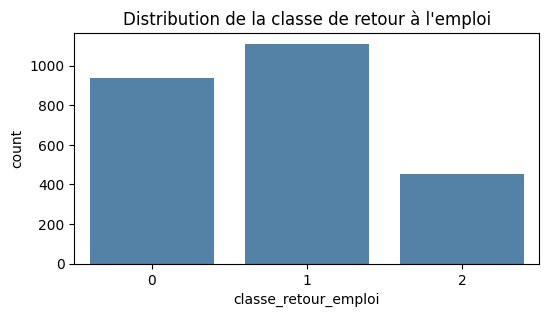

In [16]:
# Distribution de la cible
print("Distribution de la variable cible :")
display((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="classe_retour_emploi",color="steelblue")
plt.title("Distribution de la classe de retour à l'emploi")
plt.show()


>📝 **Synthèse (§3.4)**
>
>**Répartition observée**
>
>- Classe 1 (retour 6-12 mois) : 44,48%
>- Classe 0 (retour <6 mois) : 37,44%
>- Classe 2 (retour >12 mois) : 18,08%
>
>La cible est modérément déséquilibrée. La classe 2 (retour >12 mois) est la minoritaire, avec un peu moins de la moitié de l'effectif de la classe majoritaire (18,08% vs 44,48%).

### 3.5 Corrélations & relations entre variables

#### 3.5.1 Matrice de corrélation

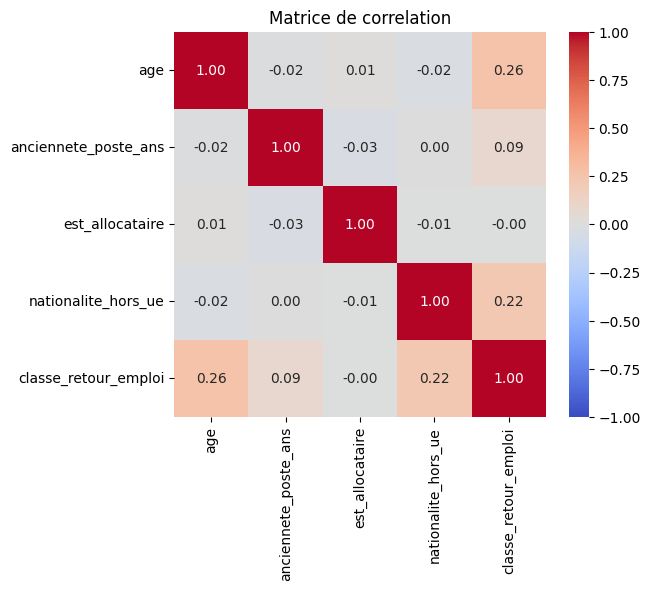

In [17]:
# Matrice de correlation entre variables numériques et la cible
num_cols = ["age", "anciennete_poste_ans", "est_allocataire", "nationalite_hors_ue", "classe_retour_emploi"]
corr = df[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de correlation")
plt.show()

#### 3.5.2 Pairplot numériques par la cible

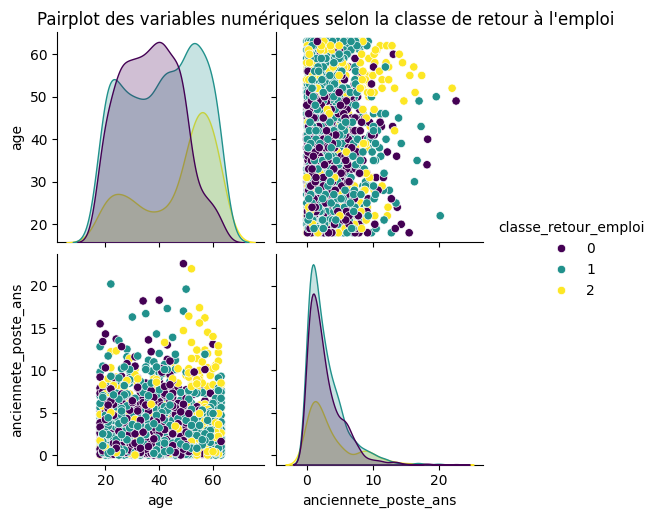

In [18]:
num_vars = ["age", "anciennete_poste_ans"]
sns.pairplot(df[num_vars + ['classe_retour_emploi']],
             hue='classe_retour_emploi', palette='viridis', diag_kind='kde')
plt.suptitle("Pairplot des variables numériques selon la classe de retour à l'emploi", y=1.02)
plt.show()


#### 3.5.3 Croisements : numériques vs cible (moyenne par classe)


Moyenne des variables numériques par classe cible :
                            age  anciennete_poste_ans
classe_retour_emploi                                 
0                     36.791855              2.782799
1                     41.296890              2.875899
2                     46.482679              3.598009


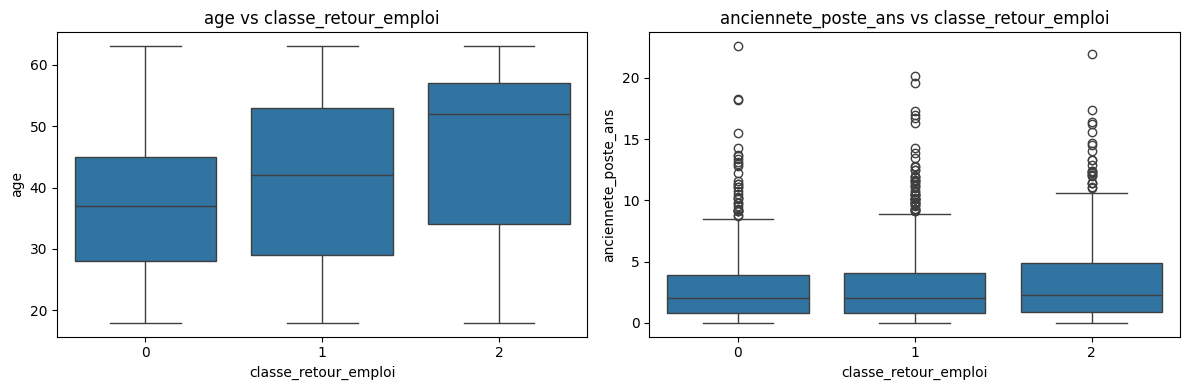

In [19]:
print("\nMoyenne des variables numériques par classe cible :")
print(df.groupby('classe_retour_emploi')[num_vars].mean())

fig, axes = plt.subplots(1, len(num_vars), figsize=(12, 4))
for i, col in enumerate(num_vars):
    sns.boxplot(x='classe_retour_emploi', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs classe_retour_emploi')
plt.tight_layout()
plt.show()

#### 3.5.4 Croisements : catégorielles vs cible

In [20]:
pd.set_option('display.max_rows', None)  # évite toute troncature de l'affichage

cat_vars = ['niveau_diplome', 'nationalite_hors_ue', 'est_allocataire',
            'departement', 'code_rome_vise', 'synthese_entretien']

for col in cat_vars:
    ct_full = pd.crosstab(df[col], df['classe_retour_emploi'], normalize='index')
    ct_raw = pd.crosstab(df[col], df['classe_retour_emploi'])
    print(f"\n--- {col} vs classe_retour_emploi")
    print(ct_full.round(3).to_string())
pd.reset_option('display.max_rows')


--- niveau_diplome vs classe_retour_emploi
classe_retour_emploi      0      1      2
niveau_diplome                           
Bac                   0.377  0.481  0.142
Bac+2                 0.377  0.495  0.128
Bac+5                 0.635  0.293  0.072
Sans diplôme          0.119  0.467  0.414

--- nationalite_hors_ue vs classe_retour_emploi
classe_retour_emploi      0      1      2
nationalite_hors_ue                      
0                     0.406  0.440  0.154
1                     0.139  0.481  0.380

--- est_allocataire vs classe_retour_emploi
classe_retour_emploi      0      1      2
est_allocataire                          
0.0                   0.379  0.435  0.186
1.0                   0.371  0.452  0.177

--- departement vs classe_retour_emploi
classe_retour_emploi      0      1      2
departement                              
01                    0.357  0.393  0.250
02                    0.186  0.424  0.390
03                    0.412  0.412  0.176
04                    0

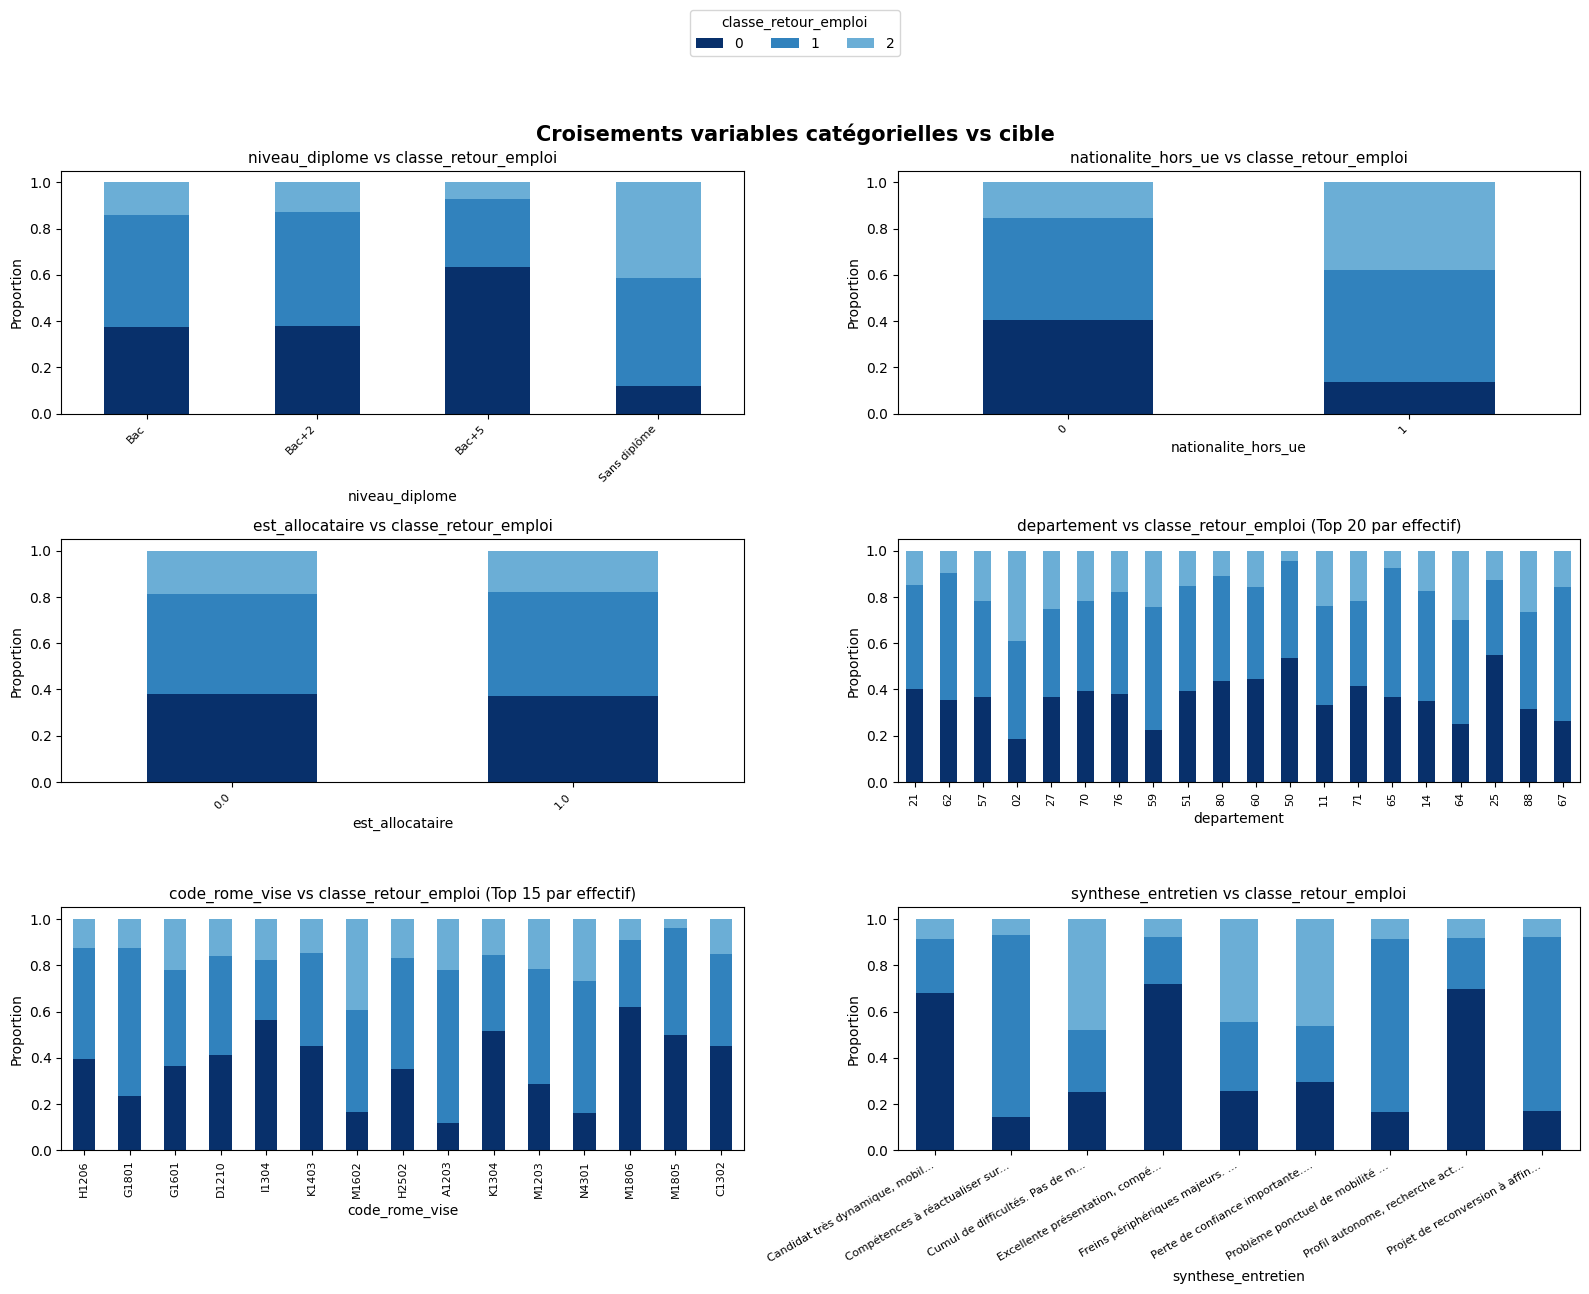

In [21]:
palette_bleue = ['#08306b', '#3182bd', '#6baed6']

n_vars = len(cat_vars)
n_cols = 2
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):

    ct_full = pd.crosstab(
        df[col],
        df['classe_retour_emploi'],
        normalize='index'
    )

    if col == "departement":
        top_n = df[col].value_counts().head(20).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 20 par effectif)"
        rotation, ha = 90, "center"

    elif col == "code_rome_vise":
        top_n = df[col].value_counts().head(15).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 15 par effectif)"
        rotation, ha = 90, "center"

    elif col == "synthese_entretien":
        ct = ct_full.copy()
        ct.index = [
            txt[:30] + "..."
            if len(str(txt)) > 30
            else txt
            for txt in ct.index
        ]
        titre_extra = ""
        rotation, ha = 30, "right"

    else:
        ct = ct_full
        titre_extra = ""
        rotation, ha = 45, "right"

    ct.plot(
        kind='bar',
        stacked=True,
        color=palette_bleue,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(
        f'{col} vs classe_retour_emploi{titre_extra}',
        fontsize=11
    )

    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(col)

    axes[i].tick_params(axis='x', rotation=rotation)

    for label in axes[i].get_xticklabels():
        label.set_ha(ha)
        label.set_fontsize(8)

# Masquer les axes inutilisés
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

# Légende unique
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="classe_retour_emploi",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.suptitle(
    "Croisements variables catégorielles vs cible",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

>📝 **Synthèse (§3.5)**
>
> **Analyse de corrélation**
>
>La matrice de corrélation met en évidence une **faible dépendance entre les variables explicatives**, suggérant l'absence de multicolinéarité significative dans le jeu de données. Les corrélations observées entre variables sont toutes proches de zéro, ce qui indique que chaque variable apporte potentiellement une information complémentaire au modèle.
>Concernant la cible `classe_retour_emploi`, les corrélations les plus élevées sont observées pour :
>- **`age` : 0,26** → association positive modérée avec le délai de retour à l'emploi ;
>- **`nationalite_hors_ue` : 0,22** → association positive modérée avec la cible ;
>- **`anciennete_poste_ans` : 0,09** → relation faible ;
>- **`est_allocataire` : ≈ 0** → absence de relation linéaire notable.
>Ces résultats suggèrent que l'âge et la nationalité hors UE contiennent un signal prédictif plus marqué que les autres variables numériques étudiées. Toutefois, la corrélation ne permet pas d'établir un lien de causalité et ne mesure que les relations linéaires.
>
>D'un point de vue éthique, les variables `age` et `nationalite_hors_ue` sont particulièrement sensibles car elles correspondent à des **critères protégés contre la discrimination**. Leur corrélation avec la cible justifie la réalisation d'analyses complémentaires de fairness afin d'évaluer l'impact de leur utilisation sur l'équité du modèle.
>
>Enfin, l'absence de corrélations fortes entre variables explicatives réduit le risque de redondance dans les données et confirme que chacune contribue à décrire une dimension différente du profil des usagers.
>
>**Analyse des croisements**
>
>**Numériques** : 
>- `age` porte un vrai signal monotone (36,8 → 41,3 → 46,5 ans selon la classe) et sépare visiblement les distributions dans le pairplot ;
>- `anciennete_poste_ans` n'apporte quasiment rien (2,78 → 2,88 → 3,60 ans, aucune séparation visuelle), sans colinéarité entre les deux (r=-0,015).
>
>**Catégorielles** : 
>
>-Le `niveau_de_diplome` apparaît comme une variable informative. Les profils **Bac+5** présentent une proportion plus importante de retours à l'emploi rapides (classe 0), tandis que les profils **sans diplôme** sont davantage représentés dans les classes de retour à l'emploi les plus longues (classe 2). Cette tendance suggère une influence du niveau de qualification sur la rapidité de réinsertion professionnelle.
>
>-La variable `nationalite_hors_ue` montre des différences visibles entre les deux groupes. Les usagers de nationalité hors UE présentent une proportion plus élevée de retours à l'emploi tardifs (classe 2) et une proportion plus faible de retours rapides (classe 0). Cette observation confirme le caractère potentiellement prédictif de la variable, tout en justifiant une vigilance particulière au regard des enjeux de discrimination et d'équité.
>
>-Les distributions observées pour les allocataires et les non-allocataires sont très proches. Cette variable semble donc contenir peu d'information discriminante vis-à-vis du délai de retour à l'emploi, ce qui rejoint les résultats obtenus lors de l'analyse des corrélations.
>
>-Des variations apparaissent selon les départements, avec certains territoires présentant une proportion plus élevée de retours rapides ou au contraire de retours plus longs. Ces écarts peuvent refléter des différences locales du marché de l'emploi, du tissu économique ou de l'offre de services. La variable peut donc constituer un proxy territorial ou socio-économique à surveiller dans l'analyse des biais.
>
>-Les répartitions diffèrent sensiblement selon les métiers ciblés. Certains codes ROME affichent une forte proportion de classe 0 tandis que d'autres présentent davantage de classes 1 ou 2. Cette variable apparaît comme une source d'information métier pertinente, traduisant probablement les différences de tension entre secteurs d'activité et métiers.
>
>-Les verbatims normalisés montrent des profils de répartition parfois très contrastés selon le contenu de l'entretien. Certaines synthèses associées à des difficultés importantes ou à des freins périphériques présentent davantage de retours à l'emploi longs, tandis que les profils décrits comme autonomes ou dynamiques semblent davantage associés à des retours plus rapides. Ces résultats confirment la richesse informationnelle des données textuelles mais soulignent également le risque d'introduire des biais liés aux appréciations subjectives des conseillers.

### 3.6 Analyse des biais & variables sensibles

In [22]:
# Vérification empirique du biais lexical suspecté sur synthese_entretien (cf. §2.4)
texte = df["synthese_entretien"].fillna("").str.lower()

# Recherche de mentions explicites de critères sensibles
patterns = {
    "age_mention": r"\b(?:\d+\s*ans|jeune|âgé|senior|ans\b)",
    "origine_mention": r"\b(?:étranger|immigr|nationalité|origine)",
    "genre_mention": r"\b(?:madame|monsieur)",
    "handicap_mention": r"\b(?:handicap|rqth|invalidité|incapacité)\b",
    "sante_mention": r"\b(?:maladie|santé|arrêt maladie|dépression|accident)\b",
    "famille_mention": r"\b(?:parent isolé|famille|enfant|garde d'enfant|monoparental)\b",
    "religion_mention": r"\b(?:religion|musulman|chrétien|juif)\b"
}
for label, pattern in patterns.items():
    n = texte.str.contains(pattern, regex=True, na=False).sum()
    print(f"{label} : {n} occurrences sur {texte.notna().sum()} textes ({n/len(df)*100:.1f} %)")

# Le texte permet-il de prédire une variable sensible ? (signal de biais lexical implicite)
tfidf = TfidfVectorizer(max_features=200, min_df=5)
X_text = tfidf.fit_transform(texte)

for sensible_col in ["nationalite_hors_ue", "groupe_age"]:
    y = df[sensible_col]
    mask = y.notna()
    if y[mask].nunique() < 2:
        continue
    clf = LogisticRegression(max_iter=1000)  # multi_class retiré (déprécié, comportement par défaut = multinomial)
    scoring = "roc_auc_ovr" if y[mask].nunique() > 2 else "roc_auc"
    scores = cross_val_score(clf, X_text[mask.values], y[mask], cv=5, scoring=scoring)
    print(f"\nAUC texte → {sensible_col} : {scores.mean():.3f} (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)")

age_mention : 0 occurrences sur 2500 textes (0.0 %)
origine_mention : 0 occurrences sur 2500 textes (0.0 %)
genre_mention : 0 occurrences sur 2500 textes (0.0 %)
handicap_mention : 0 occurrences sur 2500 textes (0.0 %)
sante_mention : 0 occurrences sur 2500 textes (0.0 %)
famille_mention : 0 occurrences sur 2500 textes (0.0 %)
religion_mention : 0 occurrences sur 2500 textes (0.0 %)

AUC texte → nationalite_hors_ue : 0.542 (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)

AUC texte → groupe_age : 0.545 (proche de 0.5 = aucun signal lexical fort permettant de prédire la nationalité ou l'âge n'a été détecté)


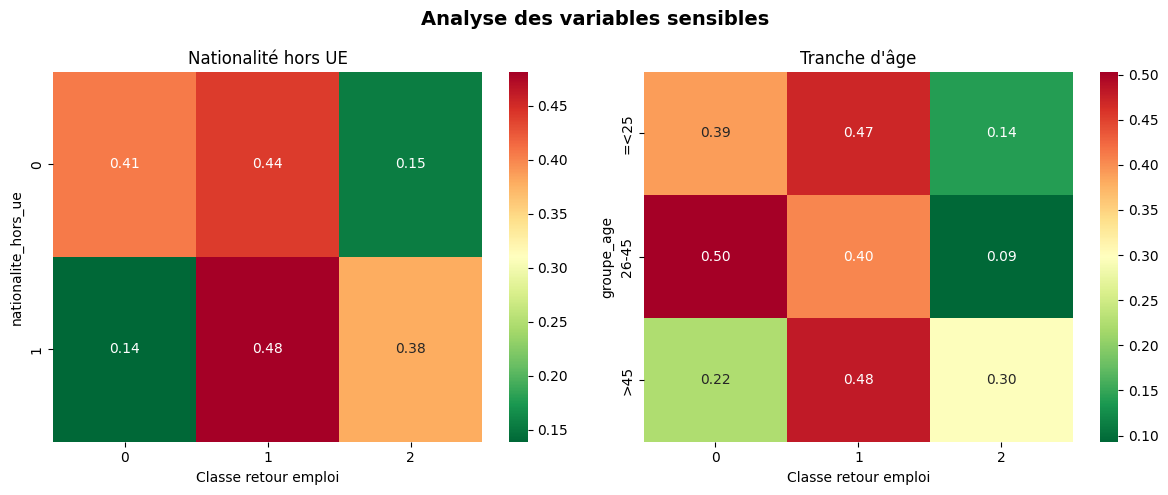

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Nationalité hors UE
ct_nat = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_nat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[0]
)

axes[0].set_title("Nationalité hors UE")
axes[0].set_xlabel("Classe retour emploi")
axes[0].set_ylabel("nationalite_hors_ue")

# 2. Groupe d'âge
ct_age = pd.crosstab(
    df["groupe_age"],
    df["classe_retour_emploi"],
    normalize="index"
)
sns.heatmap(
    ct_age,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[1]
)

axes[1].set_title("Tranche d'âge")
axes[1].set_xlabel("Classe retour emploi")
axes[1].set_ylabel("groupe_age")

plt.suptitle("Analyse des variables sensibles", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [24]:
# Fonction de calcul du Disparate Impact (règle des 4/5)
def disparate_impact(df, sensitive_col, target_col, positive_value,
                      min_group_size=None):
    
    grp = df.groupby(sensitive_col, observed=True)[target_col]
    sizes = grp.size()
    selection_rate = grp.apply(lambda x: (x == positive_value).mean())

    n_exclus = 0
    if min_group_size is not None:
        keep = sizes[sizes >= min_group_size].index
        n_exclus = len(selection_rate) - len(keep)
        selection_rate = selection_rate.loc[keep]

    sr_min, sr_max = selection_rate.min(), selection_rate.max()
    di = sr_min / sr_max  # toujours ≤ 1 par construction (min/max)

    verdict = "⚠️ Signal" if di < 0.8 else "✅ OK"

    return {
        "Variable": sensitive_col,
        "N groupes": len(selection_rate),
        "N groupes exclus (< seuil)": n_exclus,
        "Selection Rate min": round(sr_min, 3),
        "Selection Rate max": round(sr_max, 3),
        "DI": round(di, 3),
        "Verdict": verdict
    }

In [25]:
# Critères de discrimination

sensitive_vars = ["nationalite_hors_ue", "groupe_age"]

results = []
for var in sensitive_vars:
    results.append(
        disparate_impact(
            df=df, sensitive_col=var, target_col="classe_retour_emploi",
            positive_value=0
        )
    )

di_table = pd.DataFrame(results).sort_values(by="DI").reset_index(drop=True)
di_table

,Variable,N groupes,N groupes exclus (< seuil),Selection Rate min,Selection Rate max,DI,Verdict
0,nationalite_hors_ue,2,0,0.139,0.406,0.342,⚠️ Signal
1,groupe_age,3,0,0.224,0.503,0.446,⚠️ Signal


>**📝Synthèse(§3.6)**
>
>La variable `synthese_entretien` présente le niveau d'association le plus élevé avec la cible, ce qui souligne sa forte valeur prédictive. Toutefois, elle repose sur seulement neuf formulations types réutilisées dans l'ensemble du jeu de données, ce qui limite la diversité réelle du contenu textuel.
>
>Une analyse spécifique des verbatims n'a révélé aucune mention explicite de critères protégés tels que l'âge, l'origine, la nationalité ou le genre etc. De plus, les tests réalisés pour prédire l'âge et la nationalité à partir du texte seul ont obtenu des performances proches du hasard (AUC ≈ 0,54), suggérant l'absence de signal lexical fort. Les verbatims ne semblent donc pas agir comme des proxys directs des caractéristiques protégées étudiées, même si l'existence de signaux indirects ou faibles ne peut être totalement exclue.
>
>Les analyses exploratoires montrent que l'âge et la nationalité sont associés au délai de retour à l'emploi. Les heatmaps mettent notamment en évidence une surreprésentation des usagers de nationalité hors UE et des personnes de 50 ans et plus dans les classes de retour à l'emploi les plus longues. Ces variables contiennent donc un signal prédictif réel vis-à-vis de la cible, ce qui justifie les analyses de fairness et de Disparate Impact réalisées afin d'évaluer l'impact potentiel du modèle sur ces populations et de limiter les risques de discrimination.
>Les analyses d'équité mettent en évidence des disparités significatives selon certains groupes protégés, avec un Disparate Impact de **0,446 pour l'âge** et de **0,342 pour la nationalité**, valeurs inférieures au seuil de référence de 0,8 généralement utilisé pour détecter un risque de discrimination.


### 3.7 📝 Synthèse EDA

> **1. La cible présente un déséquilibre modéré mais significatif**
>
> La répartition des classes est relativement hétérogène : la classe 2 (*retour à l'emploi supérieur à 12 mois*) représente environ 18 % des observations, contre 37 % pour la classe 0 et 44 % pour la classe 1. Ce déséquilibre reste compatible avec une modélisation multiclasses, mais il impose une vigilance particulière sur la capacité du modèle à détecter correctement les situations de retour à l'emploi long.
>
> **2. L'âge est la variable numérique la plus discriminante**
>
> L'analyse exploratoire met en évidence une augmentation régulière de l'âge moyen entre les trois classes de retour à l'emploi (36,8 → 41,3 → 46,5 ans). Cette progression suggère une relation forte entre l'âge et le délai de retour à l'emploi, faisant de cette variable un candidat important pour la modélisation. À l'inverse, l'ancienneté dans le dernier poste semble apporter un signal plus limité. Toutefois, ces constats reposent sur une analyse descriptive et devront être confirmés par l'évaluation des performances réelles des modèles.
>
> **3. Plusieurs variables catégorielles apportent un signal prédictif significatif**
>
> Les analyses montrent que les variables `synthese_entretien`, `niveau_diplome`, `code_rome_vise`, `departement` et `nationalite_hors_ue` présentent des différences marquées de répartition selon la classe cible. Ces variables semblent capturer des dimensions complémentaires de l'employabilité des usagers et constituent des candidates pertinentes pour la prédiction du délai de retour à l'emploi. Leur utilisation devra néanmoins être analysée au regard des enjeux d'équité, notamment pour les variables susceptibles d'agir comme des proxys socio-économiques, territoriaux ou démographiques.
>
> **4. La variable textuelle constitue une source d'information particulièrement riche**
>
> La variable `synthese_entretien` présente le niveau d'association le plus élevé avec la cible, ce qui témoigne de sa forte valeur informative. Bien qu'elle ne comporte que neuf formulations types réutilisées dans l'ensemble du jeu de données, elle capture des informations métier difficiles à représenter dans les variables structurées. Les analyses réalisées n'ont révélé aucune mention explicite de critères protégés et n'ont pas mis en évidence de capacité significative du texte à prédire l'âge ou la nationalité (AUC ≈ 0,54). Les verbatims ne semblent donc pas agir comme des proxys directs des caractéristiques protégées étudiées.
>
> **5. Des risques de biais doivent être pris en compte**
>
> Les variables `age` et `nationalite_hors_ue`, qui correspondent à des critères protégés contre la discrimination, présentent un lien observable avec la cible. Les analyses de fairness mettent en évidence des disparités importantes entre groupes (DI âge = 0,446 ; DI nationalité = 0,342). Les heatmaps confirment également que les personnes de 45 ans et plus ainsi que les usagers de nationalité hors UE sont davantage représentés dans les classes de retour à l'emploi les plus longues. Ces résultats justifient une analyse approfondie de l'impact des variables sensibles sur les performances et l'équité du modèle.
>
> **Hypothèses de travail pour la modélisation**
>
>- Bien que `synthese_entretien` ne comporte actuellement que neuf formulations distinctes, il s'agit de texte rédigé par les conseillers et susceptible d'évoluer dans le temps. La variable sera donc traitée comme une donnée textuelle plutôt que comme une simple variable catégorielle. 
>
>- La variable `code_rome_vise` sera conservée à son niveau de granularité initial. Malgré ses 50 modalités distinctes, sa cardinalité reste modérée au regard des 2 500 observations disponibles. Regrouper les codes ROME par famille professionnelle conduirait à perdre une partie de l'information métier portée par les spécialités visées, alors que certaines différences observées entre métiers semblent fortement liées au délai de retour à l'emploi.
> 
>- À l'inverse, la variable `code_insee_commune` présente une cardinalité beaucoup plus élevée et un risque accru de surapprentissage lié à la présence de nombreuses modalités faiblement représentées. Afin de réduire cette complexité tout en conservant une information géographique pertinente, elle sera transformée en variable `departement`, offrant un niveau d'agrégation plus robuste et plus facilement interprétable.
> 
>- Les variables sensibles `age` et `nationalite_hors_ue`, identifiées comme critères protégés contre la discrimination et associées à la cible, feront l'objet de scénarios spécifiques de suppression afin d'évaluer leur contribution réelle à la performance prédictive et leur impact sur l'équité du modèle.
>
>- Les variables `departement`, `niveau_diplome` et `est_allocataire`, susceptibles d'agir comme des proxys indirects, seront surveillées à l'aide des analyses SHAP afin d'évaluer leur poids dans les décisions du modèle et leur influence potentielle sur les risques de biais.

---
## 4. Préparation des données

## 4.1 Train/test split

In [26]:
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

In [27]:
# Chargement des données et création des jeux Train / Holdout
resultats_par_scenario = {}

print("\n Résumé des scénarios de modélisation")
print("=" * 140)

for scenario_name, scenario_cfg in SCENARIOS.items():

    X, y = load_scenario_dataset(
        data_path=RAW_PATH,
        scenario_name=scenario_name
    )

    X_train, X_holdout, y_train, y_holdout = split_train_holdout(
        X=X,
        y=y
    )

    resultats_par_scenario[scenario_name] = {
        "X_train": X_train,
        "X_holdout": X_holdout,
        "y_train": y_train,
        "y_holdout": y_holdout,
    }

    print(f"\n📌 Scénario : {scenario_name}")
    print(f"   Description : {scenario_cfg.get('description', 'N/A')}")
    print(f"   Variables   : {X_train.shape[1]}")
    print(f"   Train       : {X_train.shape[0]} lignes × {X_train.shape[1]} colonnes")
    print(f"   Holdout     : {X_holdout.shape[0]} lignes × {X_holdout.shape[1]} colonnes")
    print(f"   Colonnes    : {', '.join(X_train.columns)}")

print("\n⚙️ Paramètres du découpage")
print("-" * 140)
print(f"TEST_SIZE    = {TEST_SIZE}")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print("=" * 140)


 Résumé des scénarios de modélisation

📌 Scénario : multimodal_complet
   Description : Variables tabulaires, texte et variables sensibles.
   Variables   : 8
   Train       : 2000 lignes × 8 colonnes
   Holdout     : 500 lignes × 8 colonnes
   Colonnes    : age, anciennete_poste_ans, niveau_diplome, code_rome_vise, departement, est_allocataire, nationalite_hors_ue, synthese_entretien

📌 Scénario : multimodal_ethique
   Description : Variables tabulaires et texte sans variables sensibles.
   Variables   : 6
   Train       : 2000 lignes × 6 colonnes
   Holdout     : 500 lignes × 6 colonnes
   Colonnes    : anciennete_poste_ans, niveau_diplome, code_rome_vise, departement, est_allocataire, synthese_entretien

📌 Scénario : texte_seul
   Description : Variable texte uniquement.
   Variables   : 1
   Train       : 2000 lignes × 1 colonnes
   Holdout     : 500 lignes × 1 colonnes
   Colonnes    : synthese_entretien

📌 Scénario : tabulaire_seul
   Description : Variables tabulaires uniquemen

In [28]:
print(" Typologie des variables utilisées dans le projet\n")
print(f" Variables numériques ({len(get_numeric_features())})")
display(get_numeric_features())

print(f"\n Variables ordinales ({len(get_ordinal_features())})")
display(get_ordinal_features())

print(f"\n Variables catégorielles ({len(get_categorical_features())})")
display(get_categorical_features())

print("\n Variable textuelle")
display(TEXT_FEATURE)


 Typologie des variables utilisées dans le projet

 Variables numériques (2)


['age', 'anciennete_poste_ans']


 Variables ordinales (1)


{'niveau_diplome': ['Sans diplôme', 'Bac', 'Bac+2', 'Bac+5']}


 Variables catégorielles (4)


['code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue']


 Variable textuelle


'synthese_entretien'

## 4.2 Preprocessing

In [29]:
from preprocess import build_preprocessor

# Construction du préprocesseur global
preprocessor = build_preprocessor()

print("✅ Préprocesseur créé avec succès")
print("Ce pipeline centralise l'ensemble des opérations de préparation des données (imputation, encodage et vectorisation du texte) afin de garantir la reproductibilité des expériences et d'éviter toute fuite de données."
)

display(preprocessor)

✅ Préprocesseur créé avec succès
Ce pipeline centralise l'ensemble des opérations de préparation des données (imputation, encodage et vectorisation du texte) afin de garantir la reproductibilité des expériences et d'éviter toute fuite de données.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'anciennete_poste_ans']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Sans '
                                                                              'diplôme',
                                                                              'Bac',
                                                                              'Bac+2',
                                                                              'Bac+5']],
                                                                 encoded_missing_value=-1,
                                                                 handle_un...
                                 Pipeline(steps=[('cleaner', TextCleaner()),
                                                 ('tfidf',
                                                  TfidfVectorizer(max_features=1000,
                                                                  min_df=2,
                                                                  ngram_range=(2,
                                                                               3),
                                                                  stop_words=['a',
                                                                              'afin',
                                                                              'ainsi',
                                                                              'au',
                                                                              'aux',
                                                                              'avec',
                                                                              'ce',
                                                                              'ces',
                                                                              'cet',
                                                                              'cette',
                                                                              'comme',
                                                                              'dans',
                                                                              'de',
                                                                              'des',
                                                                              'du',
                                                                              'elle',
                                                                              'elles',
                                                                              'en',
                                                                              'est',
                                                                              'et',
                                                                              'il',
                                                                              'ils',
                                                                              'je',
                                                                              'la',
                                                                              'le',
                                                                              'les',
                                                                              'leur',
                                                 

### 4.3 Scénarios de jeux de données

Les scénarios ci-dessous permettent d’évaluer séparément :

- la performance maximale du modèle ;
- l’impact du retrait des variables sensibles directes ;
- les contributions respectives du texte et des données tabulaires.

> `usager_id` est exclu de tous les scénarios, car il s’agit d’un identifiant technique sans valeur prédictive légitime.

| Scénario | Variables conservées | Variables exclues | Justification |
|---|---|---|---|
| **S1 – Multimodal complet** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` | `usager_id` | Scénario de référence visant la performance prédictive maximale. Il mobilise toutes les variables exploitables afin de mesurer le niveau de performance atteignable avant atténuation des risques de biais. |
| **S2 – Multimodal éthique** | `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `synthese_entretien`| `usager_id`, `age`, `nationalite_hors_ue` | Scénario d’atténuation des biais reposant sur le retrait des deux variables sensibles directes. Il permet de mesurer le coût en performance de cette suppression tout en conservant les informations métier et le texte. |
| **S3 – Texte seul** | `synthese_entretien` | Toutes les variables tabulaires et `usager_id` | Scénario NLP permettant de mesurer la capacité prédictive du texte seul et de vérifier si les synthèses d’entretien concentrent une part importante du signal associé à la cible. |
| **S4 – Tabulaire seul** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `departement` | `synthese_entretien`, `code_rome_vise`, `est_allocataire`, `nationalite_hors_ue`, `usager_id` | Scénario de référence tabulaire permettant d’évaluer la performance obtenue sans information textuelle et de comparer la contribution des données structurées à celle du texte. |

#### Logique de comparaison

- **S1 → S2** : mesure le coût du retrait des variables sensibles directes `age` et `nationalite_hors_ue`.
- **S3 → S4** : compare la contribution prédictive du texte à celle des variables tabulaires.
- **S1 → S3 et S4** : mesure la valeur ajoutée de la combinaison multimodale par rapport à chaque modalité utilisée séparément.

**Le même protocole de prétraitement, de validation et d’évaluation est appliqué à tous les scénarios. Seul le périmètre des variables varie, afin de garantir une comparaison équitable des performances.**



### 4.4 📝 Synthèse préparation

Les données ont été préparées au moyen d’un pipeline reproductible reposant sur un `ColumnTransformer` intégré à un `Pipeline` scikit-learn afin de garantir la cohérence des traitements et de prévenir toute fuite de données entre les étapes de prétraitement et de modélisation.

- Les **variables numériques** (`age`, `anciennete_poste_ans`) sont imputées par la médiane puis standardisées à l’aide d’un `StandardScaler`.
- La **variable ordinale** (`niveau_diplome`) est imputée par la modalité la plus fréquente puis encodée à l’aide d’un `OrdinalEncoder` respectant l’ordre métier des niveaux de diplôme (*Sans diplôme < Bac < Bac+2 < Bac+5*).
- Les **variables catégorielles nominales** (`code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`) sont imputées puis transformées par encodage One-Hot afin de permettre leur utilisation par les algorithmes de machine learning.
- La **variable textuelle** `synthese_entretien` est nettoyée puis vectorisée par TF-IDF afin de permettre son exploitation par les modèles de classification.

Bien que la variable `synthese_entretien` ne comporte actuellement que neuf formulations distinctes, celles-ci correspondent à des commentaires rédigés par les conseillers et sont donc susceptibles d'évoluer au fil du temps (nouvelles formulations, nouvelles situations métier, évolution des pratiques de saisie). Dans ce contexte, un encodage One-Hot figé sur les catégories observées lors de l'entraînement présenterait une faible capacité d'adaptation : toute nouvelle formulation apparaîtrait comme une catégorie inconnue et nécessiterait potentiellement une reconstruction du pipeline.

Le choix du TF-IDF permet au contraire de conserver la nature textuelle de la variable et d'améliorer la robustesse du système. Une nouvelle formulation partageant du vocabulaire avec des formulations déjà observées pourra être projetée dans un espace de représentation cohérent sans nécessiter de réentraînement immédiat de l'encodeur. Ce choix privilégie ainsi la **pérennité**, la **généralisation** et la **maintenabilité** du modèle en production, plutôt qu'une optimisation spécifique aux neuf formulations actuellement présentes dans le jeu de données.

Afin d'évaluer le compromis entre performance prédictive et réduction des risques de biais, quatre scénarios ont été construits :

- **S1 – Multimodal complet** : ensemble des variables disponibles ;
- **S2 – Multimodal éthique** : suppression des variables sensibles directes (`age`, `nationalite_hors_ue`) ;
- **S3 – Texte seul** : utilisation exclusive de la variable `synthese_entretien` ;
- **S4 – Tabulaire seul** : utilisation exclusive des variables structurées.

La traçabilité et la comparabilité des expérimentations sont assurées par l'utilisation d'un unique pipeline de prétraitement, d'un même protocole de validation croisée, d'un même découpage train/holdout et des mêmes métriques d'évaluation pour l'ensemble des scénarios. Seul le périmètre des variables diffère entre les configurations, ce qui garantit une comparaison équitable des performances observées.

### 4.5 Assertions de qualité

In [30]:
TEST_PATH = PROJECT_ROOT / "tests" / "test_preprocess.py"
pytest.main([
    str(TEST_PATH),
    "-vv",
    "-s",
    "--capture=no",
])

========================================================================================================== test session starts ===========================================================================================================
platform win32 -- Python 3.12.10, pytest-8.3.3, pluggy-1.6.0 -- C:\Users\a895479\projet\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\a895479\projet\certification
configfile: pytest.ini
plugins: anyio-4.14.2
collecting ... collected 6 items

..\tests\test_preprocess.py::test_dataset_is_not_empty Dataset complet non vide : 2500 lignes
PASSED
..\tests\test_preprocess.py::test_target_has_no_missing_values Valeurs manquantes dans la cible : 0
PASSED
..\tests\test_preprocess.py::test_dataset_has_no_duplicates Doublons dans le dataset : 0
PASSED
..\tests\test_preprocess.py::test_target_contains_expected_classes Classes observées dans classe_retour_emploi : [0, 1, 2]
PASSED
..\tests\test_preprocess.py::test_preprocessing_preserves_rows Répar

<ExitCode.OK: 0>

---
## 5. Modélisation & entraînement

### 5.0 Familles de modèles candidates

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn, XGBoost) | *Oui, très adapté : données principalement tabulaires, taille du dataset limitée 2500 lignes< 1M, classification supervisée 3 classes. TF-IDF permet également d'intégrer le texte.* | faible | élevée | aucune | ***Retenue** — approche principale. Constitue la baseline et les meilleurs candidats pour comparer les performances. XGBoost / Random Forest particulièrement adaptés aux données tabulaires ; Logistic Regression utile comme baseline interprétable.* |
| Deep Learning (Keras / PyTorch) | *non : possible pour le NLP, mais le dataset est limité et le problème peut être traité efficacement avec TF-IDF + ML classique.* | élevé (GPU train) | faible | aucune (modèle local) | *Écartée — ROI insuffisant. Complexité et coût supplémentaires peu justifiés par rapport à XGBoost/Random Forest + TF-IDF sur ce dataset.* |
| SLM local (Ollama, modèles ≤ 7B) | *Peu adapté au cœur du problème : un SLM pourrait analyser/générer du texte, mais n'est pas nécessaire pour la classification supervisée demandée* | moyen | moyenne | aucune | Écartée pour la classification. Peut être envisagée ultérieurement pour enrichir l'analyse NLP ou générer des explications, mais pas nécessaire pour le modèle prédictif principal. |
| LLM API + RAG | *Non pour la prédiction du délai : le problème est une classification supervisée avec une cible connue, pas un système de questions/réponses sur un corpus documentaire.* | élevé (€/token) | faible | forte (OpenAI / Anthropic / Mistral) | Écartée — inadéquation fonctionnelle. RAG n'apporte pas de valeur nécessaire à la classification. Une API LLM pourrait éventuellement être utilisée en complément pour l'analyse du texte, mais pas comme modèle principal |
| Architecture agentique (multi-LLM, tools) | *Non : aucune orchestration multi-étapes ni action autonome n'est nécessaire pour prédire la classe de retour à l'emploi.* | très élevé | très faible | forte | Écartée — surdimensionnée. L'agentique apporterait une complexité disproportionnée par rapport à une tâche de classification bien définie. |

>**📝Synthèse(§5.0)**
>
>La famille **ML classique** est retenue, notamment avec Scikit-learn et XGBoost, car elle est adaptée aux données tabulaires et textuelles du projet tout en offrant un bon compromis entre performance, coût et explicabilité.
>Les approches **Deep Learning, SLM, LLM/RAG et agentiques** sont écartées car elles sont plus complexes et coûteuses, sans bénéfice suffisant pour ce problème de classification supervisée.
>La contrainte décisive est donc **le rapport performance/coût/explicabilité**, particulièrement important dans un contexte d’orientation des demandeurs d’emploi.

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Logistic Regression | linéaire | Baseline robuste, rapide à entraîner, adaptée aux données tabulaires et aux représentations TF-IDF. Permet d'établir un niveau de performance de référence facilement interprétable. | faible / faible | élevée |
| Random Forest | ensemble (bagging) | Modèle robuste aux interactions non linéaires et aux variables catégorielles encodées. Nécessite peu de réglages et constitue une référence classique sur les données tabulaires. | moyen / faible | moyenne |
| XGBoost | ensemble (gradient boosting) | Référence de l'état de l'art sur les données tabulaires. Capable de capturer des relations complexes entre variables et souvent performant sur des jeux de données de taille modérée. | élevé / faible | moyenne |
| LightGBM | ensemble (gradient boosting) | Variante optimisée du boosting conçue pour réduire les temps d'entraînement et d'inférence tout en conservant un niveau de performance élevé. Particulièrement adaptée aux jeux de données tabulaires structurés. | moyen / faible | moyenne |

Ces quatre modèles couvrent des approches complémentaires :

- Modèle linéaire explicable (Logistic Regression) ;
- Ensemble par bagging (Random Forest) ;
- Gradient boosting classique (XGBoost) ;
- Gradient boosting optimisé (LightGBM).

Cette diversité permet de comparer les compromis entre performance prédictive, explicabilité, coût de calcul et équité.

### 5.2 Entraînement & validation croisée

In [31]:
results_std = train_requested_models(
    requested_model_type="all",
    requested_scenario="all",
    config_name="balanced",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

print(f"Nombre de modèles entraînés : {len(results_std)}")


Combinaison 1/16
Algorithme    : random_forest
Scénario      : multimodal_complet
Configuration : balanced
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6190 | F1 classe 2 : 0.5455 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.6486 | F1 classe 2 : 0.5652 | Recall classe 2 : 0.7222 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6793 | F1 classe 2 : 0.5965 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 18.06%
  Fold 4/5 | F1 macro : 0.6485 | F1 classe 2 : 0.5509 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 20.55%
  Fold 5/5 | F1 macro : 0.6736 | F1 classe 2 : 0.5647 | Recall classe 2 : 0.6575 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.6538 +/- 0.0215
Résumé Recall classe 2 CV : 0.6853 +/- 0.0353
Résumé Erreur critique 2→0 CV : 15.19% +/- 4.17%
Entraînement terminé en 0.9375 seconde(s).

Combinaison

### 5.3 Métriques retenues & justification

### Grille de métriques d'évaluation

| Catégorie | Métrique | Description | Interprétation |
|---|---|---|---|
| **Performance globale** | **F1 macro** | Moyenne non pondérée des F1-scores calculés classe par classe. | Métrique principale de sélection. Traite les trois classes à égalité, indépendamment de leur fréquence — important ici car la classe 2 est minoritaire. |
| **Risque métier** | **Recall classe 2** | Part des profils réellement classe 2 correctement détectés par le modèle. | Critère prioritaire compte tenu de l'asymétrie de coût : un faux négatif sur cette classe (profil à risque non détecté) est la conséquence la plus coûteuse pour l'usager. |
| **Risque métier** | **F1 classe 2** | Moyenne harmonique de la précision et du recall, sur la seule classe 2. | Mesure synthétique de la qualité de détection de la population la plus sensible (à lire en complément du rappel).|
| **Risque critique** | **Taux d'erreur grave (classe 2 → classe 0)** | Part des profils réellement classe 2 prédits à tort comme classe 0 (aucun risque détecté). | Erreur la plus grave du système : elle conduit à ne proposer aucun accompagnement renforcé à des profils qui en auraient le plus besoin. Correspond au poids le plus élevé de la matrice de coûts métier (§5.5). Cible initiale définie : < 5 %. |
| **Robustesse** | **Écart-type du F1 macro (validation croisée)** | Variabilité du F1 macro entre les folds de validation croisée. | Un faible écart-type garantit un modèle stable, dont la performance annoncée est fiable en conditions réelles de production. |
| **Arbitrage métier** | **Coût métier combiné** | Combinaison pondérée des erreurs 2→0 et 0→2. | Permet de comparer les modèles selon le coût opérationnel réel de leurs erreurs et sert de critère principal d'arbitrage entre configurations. |


### 5.4 Comparaison des modèles : tableau de scores CV

Avant de lancer la phase de recherche d'hyperparamètres par GridSearchCV, une première comparaison a été réalisée avec les configurations balanced définies par défaut pour chaque algorithme. Cette étape constitue la baseline de référence du projet et permet d'identifier les scénarios et modèles les plus prometteurs avant toute optimisation.

Les résultats présentés ci-dessous proviennent d'une validation croisée stratifiée à 5 folds réalisée exclusivement sur le jeu d'entraînement

In [32]:
print_training_summary(results_std)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario           | Modèle                | Configuration | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| ------------------ | --------------------- | ------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet | LightGBM              | balanced      |       0.692 | 0.019 |           0.622 |        0.037 |             10.77 % |
| Multimodal complet | Régression logistique | balanced      |       0.665 | 0.013 |           0.666 |        0.033 |             14.92 % |
| Multimodal complet | Random Forest         | balanced      |       0.654 | 0.021 |           0.685 |        0.035 |             15.19 % |
| Multimodal complet | XGBoost               | balanced      |       0.711 | 0.019 |           0.671 |        0.039 |             10.22 % |
| Multimodal éthique | LightGBM              | balanced      |       0.621 | 0.018 |           0.544 |        0.039 |             16

> Lecture avec l'écart-type. L'écart-type du F1 macro entre folds est de 0,013 à 0,028. Des différences inférieures à environ 0,03 (par exemple LightGBM 0,692 et XGBoost 0,711 sur S1) ne sont pas interprétables comme une supériorité d'un algorithme.

**Première analyse comparative**

Cette première comparaison met en évidence trois enseignements majeurs :
- Le scénario multimodal complet domine nettement les autres scénarios, confirmant la complémentarité entre données tabulaires et textuelles.
- XGBoost apparaît comme le candidat le plus équilibré avant optimisation, avec le meilleur compromis entre F1 macro, rappel de la classe 2 et limitation des erreurs critiques.
- Le retrait des variables sensibles entraîne une perte de performance mesurable, ce qui justifie une analyse approfondie du compromis entre efficacité prédictive et exigences éthiques.

Ces résultats servent de point de départ à la phase suivante de recherche d'hyperparamètres par GridSearchCV, dont l'objectif est d'améliorer les performances tout en réduisant les erreurs critiques associées aux situations de chômage longue durée.

### 5.5 Recherche d'hyperparamètres (GridSearchCV)

Afin d'identifier la configuration la plus adaptée aux objectifs métier du projet, une recherche systématique d'hyperparamètres a été réalisée à l'aide de `GridSearchCV`. Cette méthode consiste à explorer automatiquement plusieurs combinaisons d'hyperparamètres pour chaque algorithme étudié (Random Forest, Logistic Regression, LightGBM et XGBoost).

Afin de garantir la fiabilité des résultats et de limiter le risque de surapprentissage (*overfitting*), chaque combinaison est évaluée par **validation croisée stratifiée réalisée exclusivement sur le jeu d'entraînement**. Le jeu de test reste strictement isolé et n'intervient à aucun moment dans le processus d'optimisation.

Contrairement à une approche classique visant uniquement à maximiser une métrique globale comme l'accuracy ou le F1-score macro, la recherche d'hyperparamètres a été conçue pour tenir compte des enjeux métier spécifiques du cas d'usage :

- la qualité globale de classification (`F1 macro`) ;
- la capacité à détecter les situations de chômage longue durée (`Recall classe 2`) ;
- la qualité de classification de la classe critique (`F1 classe 2`) ;
- la réduction des erreurs critiques de type **2→0**, correspondant à des usagers à risque de chômage longue durée classés à tort comme susceptibles de retrouver rapidement un emploi ;
- la maîtrise des fausses alertes de type **0→2**, correspondant à des usagers orientés à tort vers un accompagnement renforcé.

Le coût métier retenu pour le réglage est 3 × erreurs(2→0) + 1 × erreurs(0→2). Les erreurs 2→1 n'y ont aucun poids. Le choix des hyperparamètres n'a donc pas cherché à les réduire.

#### 5.5.1 GridSearchCV XGBoost

In [33]:
for module_name in ["train", "config", "preprocess", "evaluation_utils"]:
    sys.modules.pop(module_name, None)

from train import (
    grid_search_xgboost_class_2,
    grid_search_random_forest_class_2,
    grid_search_logistic_regression_class_2,
    grid_search_lightgbm_class_2,
    load_scenario_dataset,
    split_train_holdout,
    train_requested_models,
    print_training_summary,
)

In [34]:
grid_searches_gb = {}
resultats_gb = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Gradient Boost/XGBoost : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_xgboost_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_gb[scenario_name] = grid_search
    resultats_gb.append(resultats_scenario)

resultats_cv_gb = pd.concat(
    resultats_gb,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_gb.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé:", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Gradient Boost/XGBoost : multimodal_complet
GridSearchCV Gradient Boost/XGBoost : multimodal_ethique
GridSearchCV Gradient Boost/XGBoost : texte_seul
GridSearchCV Gradient Boost/XGBoost : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 200, 'classifier__subsample': 0.9}
F1 macro retenu : 0.709295
F1 classe 2 associé: 0.627505

multimodal_ethique
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 400, 'classifier__subsample': 0.9}
F1 macro retenu : 0.659577
F1 classe 2 associé: 0.570638

texte_seul
Meilleurs paramètres : {'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__n_e

#### 5.5.2 GridSearchCV Random Forest

In [35]:
grid_searches_rfc = {}
resultats_rfc = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Random Forest : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_random_forest_class_2(
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        scenario_name=scenario_name,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_rfc[scenario_name] = grid_search
    resultats_rfc.append(resultats_scenario)

resultats_cv_rfc = pd.concat(
    resultats_rfc,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_rfc.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Random Forest : multimodal_complet
GridSearchCV Random Forest : multimodal_ethique
GridSearchCV Random Forest : texte_seul
GridSearchCV Random Forest : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 500, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.646243
F1 classe 2 associé : 0.557977

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_depth': 18, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300, 'classifier__n_jobs': 1, 'classifier__random_state': 42}
F1 macro retenu : 0.635018
F1 classe 2 associé : 0.540133

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__max_depth': None, 'classifier__max_features

#### 5.5.3 GridSearchCV Logistic Regression

In [36]:
grid_searches_logreg = {}
resultats_logreg = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV Logistic Regression : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_logistic_regression_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_logreg[scenario_name] = grid_search
    resultats_logreg.append(resultats_scenario)

resultats_cv_logreg_grid = pd.concat(
    resultats_logreg,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_logreg.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV Logistic Regression : multimodal_complet
GridSearchCV Logistic Regression : multimodal_ethique
GridSearchCV Logistic Regression : texte_seul
GridSearchCV Logistic Regression : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__C': 1.0, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.643363
F1 classe 2 associé : 0.552414

multimodal_ethique
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.63375
F1 classe 2 associé : 0.540382

texte_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__max_iter': 2000, 'classifier__solver': 'lbfgs'}
F1 macro retenu : 0.618979
F1 classe 2 associé : 0.50809

tabulaire_seul
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__

#### 5.5.4 GridSearchCV LightGBM

In [37]:
grid_searches_lgbm = {}
resultats_lgbm = []

for scenario_name in SCENARIOS:
    print(f"GridSearchCV LightGBM : {scenario_name}")

    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    grid_search, resultats_scenario = grid_search_lightgbm_class_2(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        cv_folds=5,
        n_jobs=-1,
    )

    resultats_scenario.insert(0, "scenario", scenario_name)
    grid_searches_lgbm[scenario_name] = grid_search
    resultats_lgbm.append(resultats_scenario)

resultats_cv_lgbm_grid = pd.concat(
    resultats_lgbm,
    ignore_index=True,
)

for scenario_name, grid_search in grid_searches_lgbm.items():
    print(f"\n{scenario_name}")
    print("Meilleurs paramètres :", grid_search.best_params_)
    best_index = grid_search.best_index_
    cv_results = grid_search.cv_results_
    print("F1 macro retenu :", round(float(cv_results["mean_test_f1_macro"][best_index]), 6))
    print("F1 classe 2 associé :", round(float(cv_results["mean_test_f1_class_2"][best_index]), 6))

GridSearchCV LightGBM : multimodal_complet
GridSearchCV LightGBM : multimodal_ethique
GridSearchCV LightGBM : texte_seul
GridSearchCV LightGBM : tabulaire_seul

multimodal_complet
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 2.5}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 350, 'classifier__num_leaves': 15}
F1 macro retenu : 0.712104
F1 classe 2 associé : 0.643649

multimodal_ethique
Meilleurs paramètres : {'classifier__class_weight': {0: 1.0, 1: 1.0, 2: 4.0}, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'classifier__n_estimators': 150, 'classifier__num_leaves': 15}
F1 macro retenu : 0.645379
F1 classe 2 associé : 0.561169

texte_seul
Meilleurs paramètres : {'classifier__class_weight': None, 'classifier__colsample_bytree': 0.9, 'classifier__learning_rate': 0.03, 'classifier__min_child_samples': 10, 'clas

**Meilleur modèle par scénario, selon le F1 de la classe 2 :**

Le tableau suivant est calculé directement à partir des candidats évalués par les quatre GridSearchCV. Les égalités sont départagées par le rappel de la classe 2, puis par le taux d'erreur critique 2→0.

In [38]:
comparaison_gridsearch = pd.concat(
    [
        resultats_cv_gb.assign(model_type="xgboost"),
        resultats_cv_rfc.assign(model_type="random_forest"),
        resultats_cv_logreg_grid.assign(model_type="logistic_regression"),
        resultats_cv_lgbm_grid.assign(model_type="lightgbm"),
    ],
    ignore_index=True,
)

meilleurs_modeles_par_scenario = (
    comparaison_gridsearch
    .sort_values(
        [
            "scenario",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ],
        ascending=[True, False, False, False, True],
    )
    .groupby("scenario", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(
    meilleurs_modeles_par_scenario[
        [
            "scenario",
            "model_type",
            "params",
            "mean_test_f1_macro",
            "mean_test_f1_class_2",
            "mean_test_recall_class_2",
            "mean_test_error_2_to_0",
        ]
    ]
)


,scenario,model_type,params,mean_test_f1_macro,mean_test_f1_class_2,mean_test_recall_class_2,mean_test_error_2_to_0
0,multimodal_complet,lightgbm,"{'classifier__class_weight': {0: 1.0, 1: 1.0, ...",0.717103,0.649815,0.704642,0.088318
1,multimodal_ethique,xgboost,"{'classifier__colsample_bytree': 0.9, 'classif...",0.659577,0.570638,0.726750,0.115944
2,tabulaire_seul,lightgbm,"{'classifier__class_weight': None, 'classifier...",0.568162,0.479841,0.361948,0.143493
3,texte_seul,random_forest,"{'classifier__class_weight': None, 'classifier...",0.634969,0.541650,0.660502,0.190449


In [39]:
all_results = []

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : multimodal_complet
Configuration : best_class_2_complet
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6701 | F1 classe 2 : 0.6200 | Recall classe 2 : 0.8611 | Erreur critique 2→0 : 4.17%
  Fold 2/5 | F1 macro : 0.6696 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 9.72%
  Fold 3/5 | F1 macro : 0.7448 | F1 classe 2 : 0.6554 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 9.72%
  Fold 4/5 | F1 macro : 0.6827 | F1 classe 2 : 0.6102 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 9.59%
  Fold 5/5 | F1 macro : 0.6936 | F1 classe 2 : 0.5792 | Recall classe 2 : 0.7260 | Erreur critique 2→0 : 9.59%

Résumé F1 macro CV : 0.6922 +/- 0.0278
Résumé Recall classe 2 CV : 0.7765 +/- 0.0502
Résumé Erreur critique 2→0 CV : 8.56% +/- 2.20%
Entraînement terminé en 0.8958 seconde(s).


In [40]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : xgboost
Scénario      : multimodal_ethique
Configuration : best_class_2_ethique
Description   : Variables tabulaires et texte sans variables sensibles.
Dimensions train   : (2000, 6)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6523 | F1 classe 2 : 0.5918 | Recall classe 2 : 0.8056 | Erreur critique 2→0 : 2.78%
  Fold 2/5 | F1 macro : 0.6471 | F1 classe 2 : 0.5397 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6860 | F1 classe 2 : 0.5806 | Recall classe 2 : 0.7500 | Erreur critique 2→0 : 12.50%
  Fold 4/5 | F1 macro : 0.6484 | F1 classe 2 : 0.5934 | Recall classe 2 : 0.7397 | Erreur critique 2→0 : 13.70%
  Fold 5/5 | F1 macro : 0.6640 | F1 classe 2 : 0.5476 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 12.33%

Résumé F1 macro CV : 0.6596 +/- 0.0145
Résumé Recall classe 2 CV : 0.7268 +/- 0.0576
Résumé Erreur critique 2→0 CV : 11.59% +/- 4.67%
Entraînement terminé en 4.2323 seconde(s).


In [41]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)


Combinaison 1/1
Algorithme    : random_forest
Scénario      : texte_seul
Configuration : best_class_2_text
Description   : Variable texte uniquement.
Dimensions train   : (2000, 1)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6068 | F1 classe 2 : 0.5376 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 11.11%
  Fold 2/5 | F1 macro : 0.6405 | F1 classe 2 : 0.5556 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 20.83%
  Fold 3/5 | F1 macro : 0.6555 | F1 classe 2 : 0.5618 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 19.44%
  Fold 4/5 | F1 macro : 0.6282 | F1 classe 2 : 0.5269 | Recall classe 2 : 0.6027 | Erreur critique 2→0 : 28.77%
  Fold 5/5 | F1 macro : 0.6439 | F1 classe 2 : 0.5263 | Recall classe 2 : 0.6164 | Erreur critique 2→0 : 15.07%

Résumé F1 macro CV : 0.6350 +/- 0.0166
Résumé Recall classe 2 CV : 0.6605 +/- 0.0418
Résumé Erreur critique 2→0 CV : 19.04% +/- 5.94%
Entraînement terminé en 1.0820 seconde(s).


In [42]:
all_results.extend(results)

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)


Combinaison 1/1
Algorithme    : lightgbm
Scénario      : tabulaire_seul
Configuration : best_class_2_tab
Description   : Variables tabulaires uniquement, sans texte.
Dimensions train   : (2000, 4)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.5527 | F1 classe 2 : 0.5172 | Recall classe 2 : 0.6250 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.5118 | F1 classe 2 : 0.4545 | Recall classe 2 : 0.4861 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.5363 | F1 classe 2 : 0.5399 | Recall classe 2 : 0.6111 | Erreur critique 2→0 : 11.11%
  Fold 4/5 | F1 macro : 0.5212 | F1 classe 2 : 0.4615 | Recall classe 2 : 0.4932 | Erreur critique 2→0 : 21.92%
  Fold 5/5 | F1 macro : 0.5635 | F1 classe 2 : 0.5054 | Recall classe 2 : 0.6438 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.5371 +/- 0.0192
Résumé Recall classe 2 CV : 0.5718 +/- 0.0680
Résumé Erreur critique 2→0 CV : 14.08% +/- 4.60%
Entraînement terminé en 0.2531 seconde(s).


In [43]:
print_training_summary(all_results)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario           | Modèle        | Configuration        | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| ------------------ | ------------- | -------------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet | LightGBM      | best_class_2_complet |       0.692 | 0.028 |           0.776 |        0.050 |              8.56 % |
| Multimodal éthique | XGBoost       | best_class_2_ethique |       0.660 | 0.015 |           0.727 |        0.058 |             11.59 % |
| Tabulaire seul     | LightGBM      | best_class_2_tab     |       0.537 | 0.019 |           0.572 |        0.068 |             14.08 % |
| Texte seul         | Random Forest | best_class_2_text    |       0.635 | 0.017 |           0.661 |        0.042 |             19.04 % |
Nombre de modèles : 4
Temps de fit final cumulé : 6.463 seconde(s)


### 5.6 Évaluation finale sur le test set

In [44]:
import importlib
evaluation_utils = importlib.import_module("evaluation_utils")
reporting = importlib.import_module("reporting")
evaluate = importlib.import_module("evaluate")

importlib.reload(evaluation_utils)
importlib.reload(reporting)
importlib.reload(evaluate)

create_benchmark = reporting.create_benchmark
print_benchmark = reporting.print_benchmark
evaluate_requested_models = evaluate.evaluate_requested_models

In [45]:
all_evaluation_results = []

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="multimodal_complet",
    config_name="best_class_2_complet",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_ethique",
    config_name="best_class_2_ethique",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="texte_seul",
    config_name="best_class_2_text",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="balanced",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="tabulaire_seul",
    config_name="best_class_2_tab",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : xgboost | multimodal_complet
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.7360
F1 macro          : 0.7171
F1 weighted       : 0.7368
F1 classe 0       : 0.7923
F1 classe 1       : 0.7361
F1 classe 2       : 0.6230
Recall classe 2    : 0.6333
Precision classe 2 : 0.6129
Erreur critique 2 -> 0 : 6
Erreur critique 0 -> 2 : 7
Latence p95       : 21.903 ms
Temps CPU / 1 000 prédictions : 104.062 ms
ROC-AUC OVR macro : 0.8775

Matrice de confusion :
[[145  35   7]
 [ 28 166  29]
 [  6  27  57]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.81      0.78      0.79       187
       Retour moyen       0.73      0.74      0.74       223
Risque longue durée       0.61      0.63      0.62        90

           accuracy                           0.74       500
          macro avg       0.72      0.72      0.72       500
       wei

### 5.7 📝 Synthèse modélisation

Ce tableau synthétise les performances des meilleurs modèles issus de notre benchmark global. Il met en regard deux approches de paramétrage :

- Les configurations de base (`balanced`) : Elles appliquent un rééquilibrage a priori des classes (via les poids de classes ou des heuristiques standards) pour contrer le déséquilibre inhérent au jeu de données.

- Le tuning ciblé par Grid Search (`best_class_2_...`) : Il s'agit d'une optimisation par recherche sur grille (Grid Search) spécifiquement orientée vers les objectifs métier, notamment la maximisation du Rappel de la classe 2 (profils vulnérables ou nécessitant une attention renforcée) et la minimisation des erreurs critiques (confusion grave de la classe 2 vers la classe 0).

**Ce que le tuning change réellement** 

Pour LightGBM sur S1, le F1 macro en CV est inchangé (0,692 avant et après) ; le recall de la classe 2 passe de 0,622 à 0,776 et l'erreur 2→0 de 10,77 % à 8,56 %. Le gain porte donc sur l'objectif métier (détection de la classe 2), pas sur la performance globale. Pour XGBoost sur S1, le F1 macro est stable (0,711 avant, 0,709 après la grille).

**Vérification sur le holdout**

Sur S1, XGBoost balanced non réglé obtient 6 erreurs 2→0 et 7 fausses alertes (F1 macro 0,717), contre 7 erreurs 2→0 et 21 fausses alertes (F1 macro 0,694) pour le LightGBM réglé retenu. Avec le coût métier du notebook (3 × erreur 2→0 + 1 × erreur 0→2), cela donne 25 contre 42 : le modèle réglé n'est pas meilleur sur ce critère sur le holdout. 

Sur S2, le modèle réglé est légèrement meilleur (coût 49 contre 53). Avec 90 usagers à risque, ces écarts restent dans l'incertitude statistique. Le choix du modèle retenu repose sur la CV, pas sur le holdout, comme le protocole l'exige.

In [46]:
all_evaluation_results.extend(evaluation_results)
benchmark_path = REPORTS_DIR / "benchmark_all_all_balanced.csv"

benchmark = create_benchmark(
    results=all_evaluation_results,
    output_path=benchmark_path,
)

display(benchmark)

,rang,model_type,scenario,config,accuracy,f1_macro,recall_classe_2,precision_classe_2,erreur_critique_2_vers_0,erreur_critique_0_vers_2,f1_classe_2,roc_auc_ovr_macro,latency_p95_ms,cpu_mean_ms
0,1,xgboost,multimodal_complet,balanced,0.736,0.717147,0.633333,0.612903,6,7,0.622951,0.877540,21.902985,104.06250
1,2,lightgbm,multimodal_complet,best_class_2_complet,0.708,0.693819,0.755556,0.482270,7,21,0.588745,0.870295,56.956110,18.90625
2,3,xgboost,multimodal_ethique,best_class_2_ethique,0.664,0.645548,0.644444,0.464000,7,28,0.539535,0.815335,16.218265,74.53125
3,4,random_forest,texte_seul,best_class_2_text,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.741739,11.621835,9.06250
4,5,random_forest,texte_seul,balanced,0.654,0.637023,0.644444,0.479339,12,32,0.549763,0.737975,93.693915,63.12500
5,6,xgboost,multimodal_ethique,balanced,0.654,0.634175,0.577778,0.504854,11,20,0.538860,0.811341,72.663230,109.53125
6,7,random_forest,tabulaire_seul,balanced,0.624,0.612014,0.588889,0.524752,10,6,0.554974,0.765720,96.757880,62.96875
7,8,lightgbm,tabulaire_seul,best_class_2_tab,0.566,0.556723,0.600000,0.415385,9,13,0.490909,0.762609,16.023590,12.03125


---
## 6. Analyse des scénarios & arbitrages


**Analyse de performance S1 vs S2**

Le scénario `multimodal_complet` obtient les meilleurs résultats globaux en combinant les données tabulaires et textuelles. Cette approche confirme que les deux sources d'information apportent une valeur prédictive complémentaire par rapport aux scénarios mono-modalité.

Le modèle basé uniquement sur le tabulaire (LightGBM) montre des performances nettement inférieures, avec un F1-macro de 0,537 et un taux d'erreur critique élevé (14,08 %). Cela prouve que les données textuelles apportent une information cruciale pour la prédiction.

Le modèle sur texte seul (Random Forest) s'en sort honorablement avec un F1-macro de 0,635 et un Recall de 66,1 %, mais il pèche sur l'erreur critique qui grimpe à 19,04 %, ce qui en fait l'option la plus risquée sur le plan métier.

Un arbitrage existe toutefois entre les deux scénarios les plus performants :

| | lightgbm (best_class_2_complet) | XGBoost (best_class_2_ethique) |Ecart S1 S2|
|---|---|---|---|
| F1 macro CV| 0.692 | 0.660 | -0.039 |
| Recall classe 2 | 0.776 | 0.727 | -0.049 |
| Erreur critique 2→0 | 8.56% | 11.59% | +3.03 |
| $\sigma(F1)$ | 0.028 | 0.015| -0.013 |
| $\sigma(Recall C2)$ | 0.050 | 0.058 | +0.008 |

En appliquant des contraintes éthiques pour le S2, les performances baissent légèrement mais restent solides avec un F1-macro de 0,660 et un Recall de 72,7 %. L'erreur critique augmente modérément à 11,59 %.


**Audit équité - Disparate impact du modèle S1 vs S2**

In [47]:
import json

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "train.py").is_file()
    and (path / "data" / "dataset_trajectoire_emploi.csv").is_file()
)

sys.path.insert(0, str(ROOT / "src"))

from config import DATA_PATH, MODELS_DIR
from train import load_scenario_dataset

# Charge le modèle S1 et les indices de son holdout.
model_path_s1 = MODELS_DIR / (
    "cisia_emploi_lightgbm_multimodal_complet_best_class_2_complet.joblib"
)
metadata_path_s1 = model_path_s1.with_suffix(".json")

model_s1 = joblib.load(model_path_s1)
metadata_s1 = json.loads(metadata_path_s1.read_text(encoding="utf-8"))
holdout_indices_s1 = [
    int(index) for index in metadata_s1["dataset"]["test_indices"]
]

X_s1, y_s1 = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_complet",
)

X_holdout_s1 = X_s1.loc[holdout_indices_s1]
y_holdout_s1 = y_s1.loc[holdout_indices_s1]
predictions_s1 = model_s1.predict(X_holdout_s1)

results_s1 = pd.DataFrame({
    "age": X_holdout_s1["age"].to_numpy(),
    "nationalite_hors_ue": X_holdout_s1["nationalite_hors_ue"].to_numpy(),
    "reel": y_holdout_s1.to_numpy(),
    "prediction": predictions_s1,
})

results_s1["tranche_age"] = (
    pd.cut(
        pd.to_numeric(results_s1["age"], errors="coerce"),
        bins=[-np.inf, 26, 46, np.inf],
        labels=["≤25", "26-45", ">45"],
        right=False,
    )
    .astype("object")
    .fillna("Non renseigné")
)

results_s1["nationalite"] = (
    pd.to_numeric(results_s1["nationalite_hors_ue"], errors="coerce")
    .map({0: "UE", 1: "Hors UE"})
    .fillna("Non renseignée")
)

def audit_classe_2(data, groupe_colonne):
    audit = data.dropna(subset=[groupe_colonne]).copy()
    lignes = []

    for groupe, sous_groupe in audit.groupby(
        groupe_colonne,
        observed=True,
        sort=True,
    ):
        reel_c2 = sous_groupe["reel"].eq(2)
        predit_c2 = sous_groupe["prediction"].eq(2)

        tp = (reel_c2 & predit_c2).sum()
        fn = (reel_c2 & ~predit_c2).sum()
        fp = (~reel_c2 & predit_c2).sum()
        tn = (~reel_c2 & ~predit_c2).sum()

        lignes.append({
            "groupe": groupe,
            "effectif": len(sous_groupe),
            "taux_prediction_classe_2": predit_c2.mean(),
            "taux_label_classe_2": reel_c2.mean(),
            "FNR_classe_2": fn / (fn + tp) if fn + tp else np.nan,
            "FPR_classe_2": fp / (fp + tn) if fp + tn else np.nan,
            "Recall_classe_2": tp / (tp + fn) if tp + fn else np.nan,
        })

    table = pd.DataFrame(lignes).sort_values(
        "taux_prediction_classe_2"
    ).reset_index(drop=True)

    def ratio_min_max(colonne):
        taux = table[colonne].dropna()
        maximum = taux.max()
        return taux.min() / maximum if maximum > 0 else np.nan

    di_predictions = ratio_min_max("taux_prediction_classe_2")
    di_labels = ratio_min_max("taux_label_classe_2")

    taux_max_predictions = table["taux_prediction_classe_2"].max()
    taux_max_labels = table["taux_label_classe_2"].max()

    table["DI_prediction_vs_max"] = (
        table["taux_prediction_classe_2"] / taux_max_predictions
        if taux_max_predictions > 0 else np.nan
    )
    table["DI_label_vs_max"] = (
        table["taux_label_classe_2"] / taux_max_labels
        if taux_max_labels > 0 else np.nan
    )

    return table, di_predictions, di_labels


for groupe in ["tranche_age", "nationalite"]:
    tableau, di_predictions, di_labels = audit_classe_2(results_s1, groupe)

    print(f"\nS1 — Classe 2 selon {groupe}")
    print(f"DI des prédictions classe 2 : {di_predictions:.3f}")
    print(f"DI des labels classe 2      : {di_labels:.3f}")

    display(
        tableau.style.format(
            {
                "taux_prediction_classe_2": "{:.1%}",
                "taux_label_classe_2": "{:.1%}",
                "FNR_classe_2": "{:.1%}",
                "FPR_classe_2": "{:.1%}",
                "Recall_classe_2": "{:.1%}",
                "DI_prediction_vs_max": "{:.3f}",
                "DI_label_vs_max": "{:.3f}",
            },
            na_rep="N/A",
        )
    )


S1 — Classe 2 selon tranche_age
DI des prédictions classe 2 : 0.397
DI des labels classe 2      : 0.229


,groupe,effectif,taux_prediction_classe_2,taux_label_classe_2,FNR_classe_2,FPR_classe_2,Recall_classe_2,DI_prediction_vs_max,DI_label_vs_max
0,26-45,199,17.1%,7.0%,50.0%,14.6%,50.0%,0.397,0.229
1,Non renseigné,22,18.2%,22.7%,60.0%,11.8%,40.0%,0.422,0.739
2,≤25,84,22.6%,13.1%,27.3%,15.1%,72.7%,0.525,0.426
3,>45,195,43.1%,30.8%,15.0%,24.4%,85.0%,1.000,1.000



S1 — Classe 2 selon nationalite
DI des prédictions classe 2 : 0.467
DI des labels classe 2      : 0.441


,groupe,effectif,taux_prediction_classe_2,taux_label_classe_2,FNR_classe_2,FPR_classe_2,Recall_classe_2,DI_prediction_vs_max,DI_label_vs_max
0,UE,444,25.0%,15.8%,28.6%,16.3%,71.4%,0.467,0.441
1,Hors UE,56,53.6%,35.7%,10.0%,33.3%,90.0%,1.000,1.000


**Analyse selon la tranche d'âge**
- Disparité des prédictions (DI = 0.397) : L'indice d'impact disparate global est très bas (bien en deçà du seuil critique de 0.80), ce qui montre un déséquilibre marqué dans la façon dont le modèle cible la classe 2 selon l'âge.   
- Le groupe le plus touché / favorisé : Les seniors (>45 ans) affichent un taux de prédiction de la classe 2 de 43.1% (pour un taux réel de 30.8%), ce qui sert de référence maximale. En revanche, la tranche 26-45 ans n'est prédite qu'à 17.1%.   
- Performance et erreurs critiques (FNR vs Recall) : 
    - Le modèle est très performant sur les plus de 45 ans avec un Recall de 85.0% et un faible taux de faux négatifs (FNR) de 15.0%.   
    - À l'inverse, pour la tranche 26-45 ans, le modèle rate la moitié des cas réels : le FNR grimpe à 50.0% (et un Recall de 50.0%), ce qui signifie qu'un nombre important d'usagers de cette tranche d'âge en risque réel de chômage longue durée ne sont pas détectés et risquent d'être privés d'accompagnement renforcé.

**Analyse selon la nationalité**
- Disparité des prédictions (DI = 0.467) : Là aussi, le Disparate Impact est faible (0.467), révélant un traitement asymétrique entre les groupes.   
- Écart entre les groupes :  Le groupe Hors UE (effectif de 56) a un taux de prédiction de classe 2 de 53.6% (pour un taux réel de 35.7%), tandis que le groupe  UE (effectif de 444) est prédit à 25.0% (pour un taux réel de 15.8%).   
- Performance : Le modèle détecte beaucoup mieux la classe 2 pour les ressortissants hors UE (Recall de 90.0%, FNR de 10.0%) que pour le groupe UE (Recall de 71.4%, FNR de 28.6%). 
Cependant, le taux de faux positifs (FPR) est également plus élevé pour les Hors UE (33.3% contre 16.3%), ce qui signifie un taux plus fort de fausses alarmes (sur-ciblage) sur cette population.   

In [48]:
import json
# Localise la racine du projet.
ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "train.py").is_file()
    and (path / "data" / "dataset_trajectoire_emploi.csv").is_file()
)

sys.path.insert(0, str(ROOT / "src"))

from config import DATA_PATH, MODELS_DIR
from train import load_scenario_dataset

# Charge l'artefact S2 et son holdout enregistré.
model_path = MODELS_DIR / (
    "cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib"
)
metadata_path = model_path.with_suffix(".json")

model_s2 = joblib.load(model_path)
metadata_s2 = json.loads(metadata_path.read_text(encoding="utf-8"))
holdout_indices = [int(index) for index in metadata_s2["dataset"]["test_indices"]]

# Données d'entrée S2 et labels du holdout.
X_s2, y_s2 = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_ethique",
)

# Jeu complet utilisé uniquement pour récupérer les attributs de groupe.
X_audit, y_audit = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_complet",
)

assert X_s2.index.equals(X_audit.index), (
    "Les jeux S2 et complet ne sont pas alignés."
)

X_holdout_s2 = X_s2.loc[holdout_indices]
X_groupes = X_audit.loc[holdout_indices]
y_holdout_s2 = y_s2.loc[holdout_indices]

predictions_s2 = model_s2.predict(X_holdout_s2)

results_s2 = pd.DataFrame({
    "age": X_groupes["age"].to_numpy(),
    "nationalite_hors_ue": X_groupes["nationalite_hors_ue"].to_numpy(),
    "reel": y_holdout_s2.to_numpy(),
    "prediction": predictions_s2,
})

results_s2["tranche_age"] = (
    pd.cut(
        pd.to_numeric(results_s2["age"], errors="coerce"),
        bins=[-np.inf, 26, 46, np.inf],
        labels=["≤25", "26-45", ">45"],
        right=False,
    )
    .astype("object")
    .fillna("Non renseigné")
)

results_s2["nationalite"] = (
    pd.to_numeric(results_s2["nationalite_hors_ue"], errors="coerce")
    .map({0: "UE", 1: "Hors UE"})
    .fillna("Non renseignée")
)

def audit_classe_2(data, groupe_colonne):
    lignes = []

    for groupe, sous_groupe in data.groupby(
        groupe_colonne,
        observed=True,
        sort=True,
    ):
        reel_c2 = sous_groupe["reel"].eq(2)
        predit_c2 = sous_groupe["prediction"].eq(2)

        tp = (reel_c2 & predit_c2).sum()
        fn = (reel_c2 & ~predit_c2).sum()
        fp = (~reel_c2 & predit_c2).sum()
        tn = (~reel_c2 & ~predit_c2).sum()

        lignes.append({
            "groupe": groupe,
            "effectif": len(sous_groupe),
            "taux_prediction_classe_2": predit_c2.mean(),
            "taux_label_classe_2": reel_c2.mean(),
            "FNR_classe_2": fn / (fn + tp) if fn + tp else np.nan,
            "FPR_classe_2": fp / (fp + tn) if fp + tn else np.nan,
            "Recall_classe_2": tp / (tp + fn) if tp + fn else np.nan,
        })

    table = pd.DataFrame(lignes).sort_values(
        "taux_prediction_classe_2"
    ).reset_index(drop=True)

    def ratio_min_max(colonne):
        taux = table[colonne].dropna()
        maximum = taux.max()
        return taux.min() / maximum if maximum > 0 else np.nan

    di_predictions = ratio_min_max("taux_prediction_classe_2")
    di_labels = ratio_min_max("taux_label_classe_2")

    taux_max_predictions = table["taux_prediction_classe_2"].max()
    taux_max_labels = table["taux_label_classe_2"].max()

    table["DI_prediction_vs_max"] = (
        table["taux_prediction_classe_2"] / taux_max_predictions
        if taux_max_predictions > 0 else np.nan
    )
    table["DI_label_vs_max"] = (
        table["taux_label_classe_2"] / taux_max_labels
        if taux_max_labels > 0 else np.nan
    )

    return table, di_predictions, di_labels

for groupe in ["tranche_age", "nationalite"]:
    tableau, di_predictions, di_labels = audit_classe_2(results_s2, groupe)

    print(f"\nS2 — Classe 2 selon {groupe}")
    print(f"DI des prédictions classe 2 : {di_predictions:.3f}")
    print(f"DI des labels classe 2      : {di_labels:.3f}")

    display(
        tableau.style.format(
            {
                "taux_prediction_classe_2": "{:.1%}",
                "taux_label_classe_2": "{:.1%}",
                "FNR_classe_2": "{:.1%}",
                "FPR_classe_2": "{:.1%}",
                "Recall_classe_2": "{:.1%}",
                "DI_prediction_vs_max": "{:.3f}",
                "DI_label_vs_max": "{:.3f}",
            },
            na_rep="N/A",
        )
    )


S2 — Classe 2 selon tranche_age
DI des prédictions classe 2 : 0.717
DI des labels classe 2      : 0.229


,groupe,effectif,taux_prediction_classe_2,taux_label_classe_2,FNR_classe_2,FPR_classe_2,Recall_classe_2,DI_prediction_vs_max,DI_label_vs_max
0,26-45,199,20.6%,7.0%,35.7%,17.3%,64.3%,0.717,0.229
1,≤25,84,26.2%,13.1%,9.1%,16.4%,90.9%,0.912,0.426
2,Non renseigné,22,27.3%,22.7%,20.0%,11.8%,80.0%,0.950,0.739
3,>45,195,28.7%,30.8%,41.7%,15.6%,58.3%,1.000,1.000



S2 — Classe 2 selon nationalite
DI des prédictions classe 2 : 0.662
DI des labels classe 2      : 0.441


,groupe,effectif,taux_prediction_classe_2,taux_label_classe_2,FNR_classe_2,FPR_classe_2,Recall_classe_2,DI_prediction_vs_max,DI_label_vs_max
0,UE,444,23.6%,15.8%,35.7%,16.0%,64.3%,0.662,0.441
1,Hors UE,56,35.7%,35.7%,35.0%,19.4%,65.0%,1.000,1.000


**Analyse selon la tranche d'âge**

- Amélioration du Disparate Impact : Le DI des prédictions passe à 0.717 (contre 0.397 pour S1), ce qui montre un comportement globalement plus équilibré entre les tranches d'âge, même si on reste sous le seuil d'alerte de 0.80.
- Inversion des dynamiques de performance :
    - Contrairement au scénario S1, les seniors (>45 ans) ne sont plus les mieux détectés : leur Recall chute à 58.3% et leur taux de faux négatifs (FNR) monte à 41.7%.
    - À l'inverse, les plus jeunes (≤25 ans) bénéficient d'un excellent Recall de 90.9% (et un très bas FNR de 9.1%).
- Taux de prédiction : Le modèle S2 prédit la classe 2 de manière beaucoup plus homogène selon l'âge (variant de 20.6% pour les 26-45 ans à 28.7% pour les plus de 45 ans).

**Analyse selon la nationalité**

- Meilleure parité : Le DI des prédictions pour la nationalité s'améliore également, passant de 0.467 (dans S1) à 0.662 (dans S2).
- Équilibrage du Recall :
    - Le groupe UE a un Recall de 64.3% (et un FNR de 35.7%).   
    - Le groupe Hors UE a un Recall très proche de 65.0% (et un FNR de 35.0%).
    - Contrairement à S1 où le modèle favorisait fortement le rappel des Hors UE au détriment des autres, le modèle S2 offre des performances beaucoup plus proches entre les deux groupes sur ce plan.
- Taux de prédiction : Le taux de prédiction de la classe 2 est de 23.6% pour les ressortissants UE et de 35.7% pour les Hors UE, ce qui reflète plus fidèlement l'écart des taux réels de labels (15.8% vs 35.7%). 

>**Bilan comparatif entre S1 et S2 (Best Class2):**   
>
>**Équité globale (Disparate Impact) :** S2 est meilleur. Le score de parité s'améliore à la fois pour l'âge (passe de 0,397 à 0,717) et pour la nationalité (passe de 0,467 à 0,662), se rapprochant du seuil d'acceptabilité (0,80). le DI des prédictions S2 (0,717) dépasse celui des labels (0,229). Cela reflète aussi un moindre rappel sur les seniors (85,0 % → 58,3 %), donc un arbitrage et pas un simple gain.
>
>**Répartition des prédictions : S1 est trop polarisé**, ciblant massivement les seniors (43,1 %) et les non-UE (53,6 %). S2 propose un lissage plus équilibré et modéré (taux entre 20,6 % et 28,7 %).   
>
>**Erreurs critiques (FNR) : S2 corrige les asymétries majeures**. Alors que S1 laissait de côté la moitié des 26-45 ans (50 % d'erreur) et favorisait les non-UE, S2 stabilise et équilibre les taux d'erreur entre les groupes.   
>
>En résumé : S2 atténue partiellement les écarts, le DI reste sous 0,80 (0,717 pour l'âge, 0,662 pour la nationalité), sans garantie d'équité, avec un risque résiduel via les proxys (departement, code_rome_vise, texte).

### 6.1 Tableau comparatif

| Scénario | Modèle | CV F1 macro | CV Recall classe 2 | CV erreur (2→0) | Coût inférence (CPU / préd.) | Latence p95 | Explicabilité | Dépendance fournisseur | Biais | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| S1 — multimodal_complet | lightgbm (best_class_2_complet) | **0.692** | **0.776** | 8.56% | **14.37 ms** | 17.89 ms | Moyenne | Aucune | Variables sensibles incluses — biais non mitigé | **Candidat techniquement optimal** mais biais non traité |
| S2 — multimodal_ethique | xgboost (best_class_2_ethique) | **0.660** | **0.727** | **11.59%**| 46.25 ms | **9.92 ms** | Moyenne | Aucune | Il s'agit uniquement d'une mitigation par exclusion de variables sensibles directes | **Compromis à privilégier pour un pilote contrôlé** : S2 exclut directement les variables sensibles et réduit les écarts de taux de prédiction de classe 2 entre groupes selon le DI. |
| S3 — texte_seul | random_forest (best_class_2_text) | 0.635 | 0.661 | 19.04% | 17.96ms | 24.91 ms | Moyenne | Aucune | Pas de variable sensible structurée — risque de biais indirect via le texte non audité | **Écarté sans ambiguïté** : taux d'erreur grave élevé (19,04 %) et latence p95 très élevée. |
| S4 — tabulaire_seul | lightgbm (best_class_2_tab) | 0.537 | 0.572 | 14.08% | **10.15 ms** | **13.05 ms** | Moyenne à élevée | Aucune | Variables sensibles incluses — biais potentiel non mitigé | **Candidat « faible coût » uniquement** : Option à faible coût et latence d'inférence réduite|

*Limite à noter : les mesures de latence/CPU proviennent d'un run unique par combinaison et n'ont pas encore été répétées pour estimer leur variance — une conclusion définitive sur le coût opérationnel nécessiterait plusieurs mesures indépendantes avant publication finale.*

### 6.2 Recommandation finale au client

Nous recommandons de retenir **S2 — multimodal éthique** comme modèle de départ pour un **pilote contrôlé**.

**Ce que S1 apporte, et pourquoi nous ne le retenons pas.** S1 obtient les meilleures performances en validation croisée (F1 macro 0,692 contre 0,660 ; rappel de la classe 2 : 77,6 % contre 72,7 % ; erreur critique 2→0 : 8,56 % contre 11,59 %). Il utilise toutefois l'âge et la nationalité, deux critères protégés (art. 225-1 du Code pénal), et ses prédictions présentent des écarts marqués entre groupes (Disparate Impact : 0,397 pour l'âge, 0,467 pour la nationalité, sous le seuil de 0,80).

**Pourquoi S2.**
1. **Conformité.** S2 exclut ces deux variables : il n'y a plus de discrimination directe, et la minimisation des données (RGPD) est respectée. L'interface ne collecte ni l'âge ni la nationalité.(§8.3)
2. **Écarts de prédiction réduits.** Le Disparate Impact passe de 0,397 à 0,717 pour l'âge et de 0,467 à 0,662 pour la nationalité. Il reste sous 0,80 : l'amélioration est réelle, mais partielle.
3. **Adapté à un pilote.** S2 conserve le texte et les variables métier, et reste explicable (SHAP) (§7.1).

**Un compromis mesuré, mais non gratuit.** Sur le holdout, le retrait de ces deux variables coûte environ 5 points de F1 macro (0,694 → 0,646) et 11 points de rappel sur la classe 2 (75,6 % → 64,4 %), avec 7 fausses alertes de plus (21 → 28). Le nombre d'erreurs critiques 2→0 est identique (7). Avec 90 usagers à risque, ces écarts ne sont pas statistiquement distinguables. Le choix de S2 repose donc d'abord sur l'argument juridique et éthique, et non sur une supériorité démontrée de performance ou d'équité.

**Limites à garder en tête.**
- Le retrait des variables directes ne supprime pas les biais indirects : le département, le métier visé et le texte peuvent jouer le rôle de proxys.
- Les écarts de détection entre tranches d'âge persistent : en S2, le rappel des plus de 45 ans baisse (85,0 % → 58,3 %). Ce suivi doit être poursuivi en production.
- Le coût d'inférence de S2 est plus élevé que celui de S1 (46 ms contre 14 ms de CPU par prédiction), sans incidence sur l'objectif de latence.

**Conclusion.** S2 offre le meilleur équilibre entre performance, explicabilité et réduction de la discrimination directe, sans prétendre à l'équité complète. Il est recommandé pour un pilote contrôlé, sous supervision humaine des dossiers incertains (§7.2).

### 6.3 📝 Synthèse arbitrages

L'audit comparatif met en évidence un arbitrage entre la performance prédictive et l'équité des prédictions.

**1. Le texte est la source d'information la plus utile, et la combinaison avec le tabulaire apporte un gain modeste**
Le tabulaire seul est nettement en retrait (S4 : F1 macro 0,537, erreur critique 14,08 %). Les scénarios multimodaux (S1 : 0,692 ; S2 : 0,660) font mieux que le texte seul (S3 : 0,635), mais l'écart de F1 macro entre S2 et S3 (0,025) est du même ordre que l'écart-type entre folds (0,015 à 0,028) et n'est donc pas interprétable à lui seul. L'avantage de la combinaison est plus net sur la classe à risque : rappel de la classe 2 de 72,7 % pour S2 contre 66,1 % pour S3, et erreur critique 2→0 de 11,59 % contre 19,04 %. Les options mono-modalité présentent ainsi un taux d'erreur critique trop élevé pour un usage d'aide à l'orientation.

**2. Le meilleur candidat technique (S1) comporte des écarts de traitement non traités**
S1 (multimodal complet) obtient les meilleurs résultats en validation croisée : F1 macro 0,692, rappel de la classe 2 de 77,6 % et erreur critique 2→0 de 8,56 %. Il utilise cependant l'âge et la nationalité, critères protégés, et ses prédictions présentent des écarts marqués entre groupes (Disparate Impact : 0,397 pour l'âge, 0,467 pour la nationalité, sous le seuil de 0,80). Ce niveau expose le projet à un risque de discrimination.

**3. S2 : un compromis assumé, qui n'est pas gratuit**
S2 (multimodal éthique) exclut ces deux variables. Il coûte environ 0,03 point de F1 macro en validation croisée (0,692 → 0,660) et son erreur critique CV augmente de 8,56 % à 11,59 %. Sur le holdout, le nombre d'erreurs critiques est identique (7), mais ces écarts ne sont pas statistiquement distinguables avec 90 usagers à risque. En contrepartie, les écarts de prédiction entre groupes diminuent : le Disparate Impact passe de 0,397 à 0,717 pour l'âge et de 0,467 à 0,662 pour la nationalité.

Cette amélioration reste partielle : le DI demeure sous 0,80, et le gain d'équité n'est pas démontré au sens statistique. La détection varie encore selon l'âge (rappel des plus de 45 ans : 85,0 % en S1, 58,3 % en S2). L'exclusion de variables directes n'écarte pas le risque de biais indirect, car le département, le métier visé et le texte peuvent agir comme des proxys.

**Conclusion opérationnelle**
S2 est le compromis le plus défendable : il supprime la discrimination directe, garde un niveau de performance proche de S1 et reste explicable. Il est recommandé pour un pilote contrôlé, sous supervision humaine des dossiers incertains (§7.2) et avec un suivi des écarts entre groupes en production.

---
## 7. Interprétation pour la communication client

### 7.1 Explicabilité (SHAP) et analyse de la matrice de confusion

**Matrice de confusion**

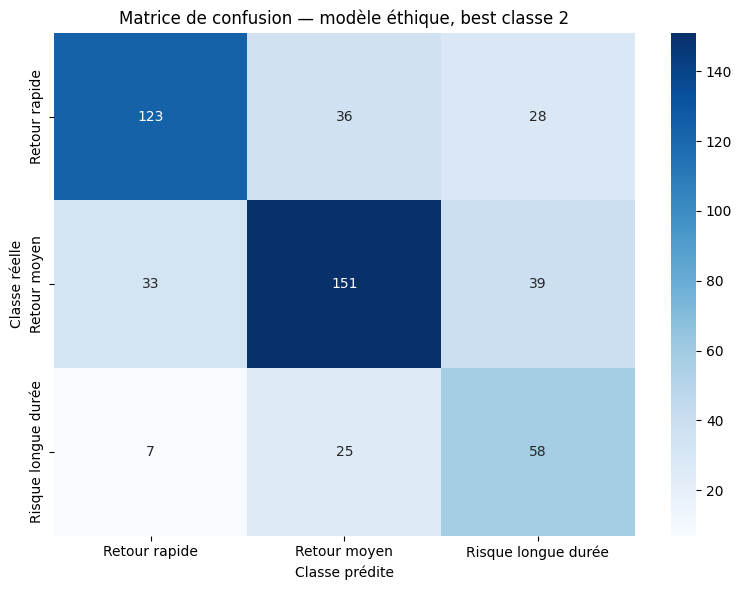

In [49]:
%matplotlib inline
report_name = "cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_evaluation.json"
root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "reports" / report_name).is_file()),
    None,
)
if root is None:
    raise FileNotFoundError(f"Rapport introuvable : {report_name}")

with (root / "reports" / report_name).open(encoding="utf-8") as file:
    report = json.load(file)

class_names = ["Retour rapide", "Retour moyen", "Risque longue durée"]
matrix = report["metrics"]["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Matrice de confusion — modèle éthique, best classe 2")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

L'analyse de la matrice de confusion du scénario **S2 – multimodal_ethique** permet d'évaluer concrètement la capacité du modèle à identifier les usagers nécessitant un accompagnement renforcé ainsi que les impacts opérationnels associés à son utilisation.

**Capacité de détection des cas prioritaires**

Sur les usagers appartenant à la classe **« Risque longue durée »**, le modèle identifie correctement **58 bénéficiaires** nécessitant un accompagnement renforcé.

Les erreurs les plus critiques correspondent aux faux négatifs, c'est-à-dire aux usagers réellement à risque mais classés à tort dans une catégorie moins prioritaire. Le modèle ne commet que **7 erreurs critiques de type "Risque longue durée → Retour rapide"**, ce qui limite le risque de sous-accompagnement des publics les plus fragiles.

Erreurs 2→1 (risque longue durée classé « retour moyen »). 25 usagers à risque sur 90 (27,8 %) sont classés « retour moyen ». Ces erreurs sont plus nombreuses que les erreurs 2→0 (7 sur 90, soit 7,8 %). Nous les avons jugées moins graves car elles conduisent à un suivi intermédiaire plutôt qu'à une absence d'accompagnement. 

**Coût opérationnel : les fausses alertes**

La principale limite observée concerne le nombre de faux positifs.

La matrice de confusion montre que **28 usagers relevant en réalité de la catégorie « Retour rapide »** sont prédits à tort comme appartenant à la catégorie **« Risque longue durée »**.

Ces bénéficiaires pourraient ainsi être orientés vers un accompagnement renforcé sans en avoir strictement besoin. Cette situation traduit un choix assumé du modèle consistant à privilégier la détection des situations à risque au prix d'un nombre plus important de fausses alertes.

L'impact réel de cette charge supplémentaire sur les équipes de conseil n'a pas été évalué dans le cadre du projet et devra être validé avec les parties prenantes métier afin d'en confirmer la soutenabilité opérationnelle.

Dans l'ensemble, le scénario **S2 – multimodal_ethique** présente un comportement cohérent avec l'objectif recherché : limiter les erreurs critiques sur les bénéficiaires les plus vulnérables tout en acceptant une augmentation des fausses alertes. Cette stratégie apparaît compatible avec une logique d'aide à la décision, à condition que les équipes métier soient en capacité d'absorber la charge supplémentaire induite par ces orientations préventives.

Dimensions : (200, 253)
Type après conversion : <class 'numpy.ndarray'>
Dtype après conversion : float64
Dimensions après conversion : (200, 253)


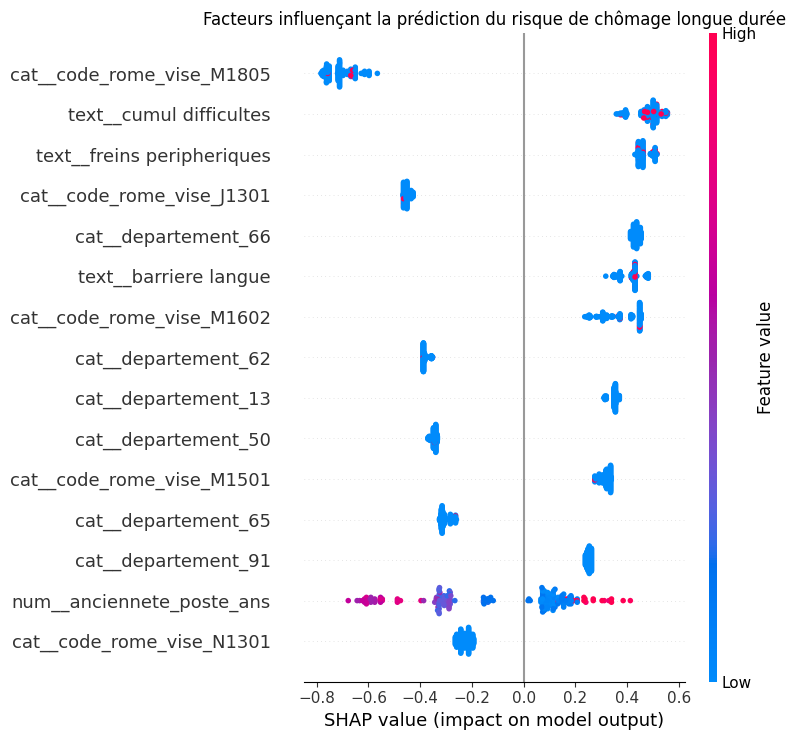

In [50]:
MODEL_PATH = (
    Path("..")
    / "models"
    / "cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib"
)

pipeline = joblib.load(MODEL_PATH)
X, y = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_ethique",
)

X_sample = X.sample(
    n=min(200, len(X)),
    random_state=42
)

preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

# Transformation avec exactement le prétraitement appris pendant le train
X_transformed = preprocessor.transform(X_sample)

print("Dimensions :", X_transformed.shape)

# SHAP TreeExplainer attend une matrice numérique dense
if sparse.issparse(X_transformed):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(
    np.float64,
    copy=False,
)

print("Type après conversion :", type(X_transformed_numeric))
print("Dtype après conversion :", X_transformed_numeric.dtype)
print("Dimensions après conversion :", X_transformed_numeric.shape)

# Vérification avant SHAP
if not np.isfinite(X_transformed_numeric).all():
    raise ValueError(
        "La matrice transformée contient des valeurs NaN ou infinies."
    )

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_transformed_numeric,
    check_additivity=False,
)
if isinstance(shap_values, list):
    shap_values_class_2 = shap_values[2]

else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        shap_values_class_2 = shap_array[:, :, 2]

    elif shap_array.ndim == 2:
        shap_values_class_2 = shap_array

    else:
        raise ValueError(
            f"Forme SHAP non reconnue : {shap_array.shape}"
        )
feature_names = (
    pipeline.named_steps["preprocess"]
    .get_feature_names_out()
)

shap.summary_plot(
    shap_values_class_2,
    X_transformed_numeric,
    feature_names=feature_names,
    max_display=15,
    show=False,
)

plt.title(
    "Facteurs influençant la prédiction du risque de chômage longue durée"
)

importance = np.abs(
    shap_values_class_2
).mean(axis=0)


plt.tight_layout()
plt.show()


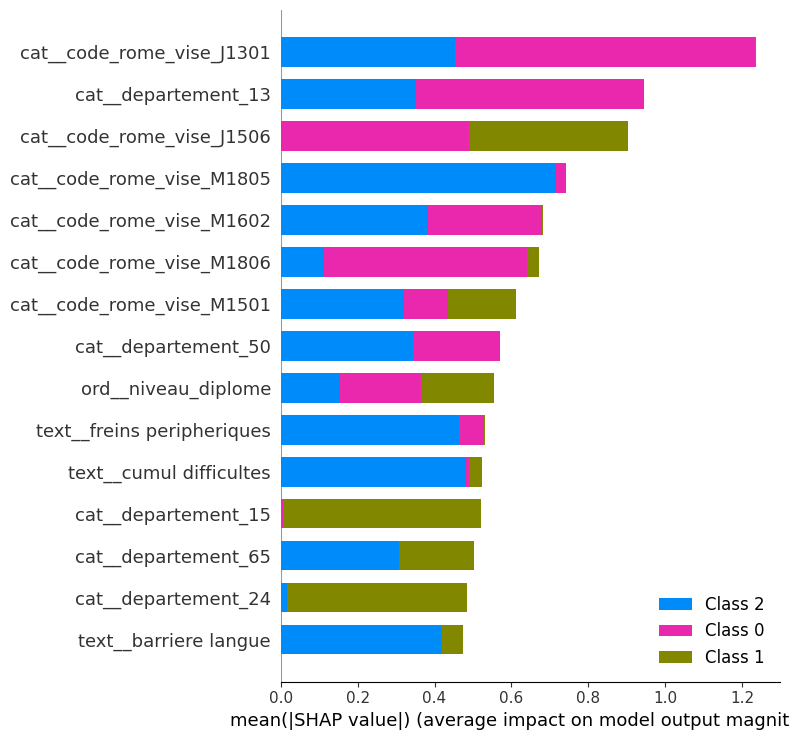

In [51]:
# 1. Extraction des sous-étapes du pipeline
preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

# 2. Transformation des données de l'échantillon
X_transformed = preprocessor.transform(X_sample)

# 3. Conversion propre en numpy array dense
if hasattr(X_transformed, "toarray"):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(np.float64, copy=False)

# 4. Récupération sécurisée des noms de variables (Feature Names)
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    # Si le preprocessor lève NotFittedError ou AttributeError,
    # on génère des noms génériques basés sur le nombre exact de colonnes
    feature_names = [f"Feature_{i}" for i in range(X_transformed_numeric.shape[1])]

# 5. Création du DataFrame
X_transformed_df = pd.DataFrame(
    X_transformed_numeric, 
    columns=feature_names
)

# 6. Explicabilité SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_transformed_df)

# Graphique de synthèse standard
shap.summary_plot(
    shap_values, 
    X_transformed_df, 
    max_display=15, 
    show=True
)

In [52]:
# Importance SHAP agrégée par variable d'origine (classe 2)
feature_names = np.asarray(feature_names)

def variable_origine(nom: str) -> str:
    if nom.startswith("text__"):
        return "synthese_entretien (TF-IDF)"
    for base in ("code_rome_vise", "departement", "est_allocataire"):
        if nom.startswith(f"cat__{base}"):
            return base
    return nom.split("__", 1)[-1]  # num__ / ord__ / autres


origine = np.array([variable_origine(n) for n in feature_names])
lignes = []
for variable in np.unique(origine):
    idx = np.where(origine == variable)[0]
    lignes.append({
        "variable": variable,
        "nb_colonnes": len(idx),
        "importance_shap_moy": np.abs(shap_values_class_2[:, idx].sum(axis=1)).mean(),
    })
importance_variables = (
    pd.DataFrame(lignes)
    .sort_values("importance_shap_moy", ascending=False)
    .reset_index(drop=True)
)
importance_variables["part"] = (
    importance_variables["importance_shap_moy"] / importance_variables["importance_shap_moy"].sum()
)
display(importance_variables.style.format({"importance_shap_moy": "{:.3f}", "part": "{:.1%}"}))

,variable,nb_colonnes,importance_shap_moy,part
0,synthese_entretien (TF-IDF),103,1.520,53.9%
1,code_rome_vise,50,0.769,27.2%
2,anciennete_poste_ans,1,0.240,8.5%
3,niveau_diplome,1,0.155,5.5%
4,departement,96,0.123,4.4%
5,est_allocataire,2,0.016,0.6%


**Analyse SHAP**

L'analyse SHAP valide la cohérence métier du modèle et confirme que les décisions reposent sur des critères explicables et légitimes.

**Prépondérance des freins à l'emploi (Variables textuelles)**
Les facteurs les plus contributifs issus du NLP (`synthese_entretien`) sont directement liés aux obstacles à la réinsertion :
* **`text__cumul difficultes`**, **`text__freins peripheriques`** et **`text__barriere langue`** augmentent significativement la probabilité d'affectation au Risque 2 (retour à l'emploi tardif).
* Ce constat confirme la très forte valeur ajoutée de la synthèse rédigée par le conseiller pour capter la réalité du profil.

**Impact du marché local et des secteurs d'activité**
* **Tension sectorielle (`code_rome_vise`)** : Des métiers spécifiques (ex. `J1301`, `M1805`) structurent fortement la classification, reflétant les disparités de recrutement selon les branches professionnelles.
* **Effet territorial (`departement`)** : L'impact des variables géographiques (ex. `departement_13`, `65`) traduit l'influence des dynamiques locales du marché du travail.

**Audit d'Équité & Conformité AI Act**
* **Absence de discrimination directe** : Les variables protégées (`age`, `nationalite_hors_ue`) ont été totalement exclues du scénario retenu et n'interviennent pas dans la décision.
* **Vigilance sur les proxys** : L'analyse SHAP révèle que les variables `departement` et `code_rome_vise` contribuent aux prédictions. Elles constituent des **proxys potentiels** de facteurs socio-économiques qu'il conviendra de surveiller en production.



**📝 Synthèse(§7.1)**

**1. Un arbitrage éthique assumé et conforme**

Le scénario retenu (**S2 – multimodal_ethique**) exclut les variables `age` et `nationalite_hors_ue` afin de limiter les risques liés à l'utilisation de caractéristiques sensibles ou associées à des critères protégés.

Ce choix s'inscrit dans une démarche d'IA responsable et de minimisation des données, tout en maintenant un niveau de performance compatible avec les objectifs métiers.

**2. Des erreurs critiques maîtrisées au prix d'une charge opérationnelle accrue**

Le modèle parvient à identifier la majorité des usagers nécessitant un accompagnement renforcé et ne commet qu'un nombre limité d'erreurs critiques (**7 faux négatifs de type « Risque longue durée → Retour rapide »**).

La principale contrepartie réside dans l'augmentation des faux positifs (**28 cas**), ce qui pourrait générer une charge supplémentaire pour les équipes de conseil. La soutenabilité de cette charge devra être validée avec les parties prenantes métier.

**Des décisions explicables, fondées sur des critères métier et placées sous surveillance**

Les analyses d'interprétabilité (SHAP) montrent que les prédictions reposent principalement sur des facteurs cohérents avec le contexte métier, tels que les freins à l'emploi, les tensions du marché du travail ou les caractéristiques du parcours du bénéficiaire.

Toutefois, une vigilance continue reste nécessaire afin de surveiller d'éventuels biais indirects liés à certaines variables pouvant agir comme des proxys partiels (par exemple le département de résidence ou le métier visé). Cette surveillance constitue une condition essentielle d'un usage responsable et durable du modèle.


> Le scénario S2 n'est pas le plus performant, mais il offre le compromis le plus équilibré entre performance métier, maîtrise du risque de discrimination et conformité réglementaire. Les erreurs critiques restent limitées, la décision finale demeure supervisée

### 7.2 Analyse des erreurs et stratégies de fallback

In [53]:
# Le holdout ne sert qu'une fois, pour le chiffre final : régler le seuil dessus le contaminerait.
import json
CURRENT_DIR = Path.cwd().resolve()
SEARCH_ROOTS = []
for directory in (CURRENT_DIR, *CURRENT_DIR.parents):
    SEARCH_ROOTS.extend((directory, directory / "certification"))

CERTIFICATION_DIR = next(
    (
        directory
        for directory in SEARCH_ROOTS
        if (directory / "src" / "config.py").is_file()
        and (directory / "data" / "dataset_trajectoire_emploi.csv").is_file()
    ),
    None,
)
if CERTIFICATION_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser la racine certification depuis le répertoire courant."
    )

CERTIFICATION_SRC = str((CERTIFICATION_DIR / "src").resolve())
if CERTIFICATION_SRC in sys.path:
    sys.path.remove(CERTIFICATION_SRC)
sys.path.insert(0, CERTIFICATION_SRC)
for module_name in ("config", "train", "preprocess", "evaluation_utils"):
    sys.modules.pop(module_name, None)


MODEL_TYPE = "xgboost"
SCENARIO_NAME = "multimodal_ethique"
CONFIG_NAME = "best_class_2_ethique"
MODEL_PATH = MODELS_DIR / f"cisia_emploi_{MODEL_TYPE}_{SCENARIO_NAME}_{CONFIG_NAME}.joblib"

# --- Étape 1 : même split train/holdout que train.py ---
# Mêmes TEST_SIZE / RANDOM_STATE / stratification pour retrouver exactement le holdout du modèle.
X, y = load_scenario_dataset(data_path=DATA_PATH, scenario_name=SCENARIO_NAME)
y = y.astype(int)
X_train_full, X_holdout, y_train_full, y_holdout = split_train_holdout(
    X=X, y=y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

metadata = json.loads(MODEL_PATH.with_suffix(".json").read_text(encoding="utf-8"))
holdout_indices = metadata["dataset"]["test_indices"]
if set(X_holdout.index) != set(holdout_indices):
    raise ValueError("Le holdout recalculé ne correspond pas aux test_indices des métadonnées.")
print(f"Racine certification : {CERTIFICATION_DIR}")
print(f"Artefact chargé : {MODEL_PATH.resolve()}")
print(f"Holdout vérifié : identique aux métadonnées (n={len(X_holdout)})")

# --- Étape 2 : second découpage du train pour isoler un jeu de calibration ---
# Le modèle ne doit pas voir ces lignes à l'entraînement, sinon ses probabilités y seraient trop optimistes.
X_train_fit, X_calibration, y_train_fit, y_calibration = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE,
)
print(f"Train fit : n={len(X_train_fit)} | Calibration : n={len(X_calibration)} | Holdout : n={len(X_holdout)}")

# --- Étape 3 : même pipeline et mêmes hyperparamètres, entraîné sur X_train_fit uniquement ---
# Le modèle sauvegardé a vu tout X_train_full, dont X_calibration : on ne peut pas le réutiliser ici.
CALIBRATION_FIT_PATH = MODEL_PATH.with_name(
    f"{MODEL_PATH.stem}_calibration_fit.joblib"
)

if CALIBRATION_FIT_PATH.is_file():
    pipeline_fit = joblib.load(CALIBRATION_FIT_PATH)
    print(f"Pipeline de calibration chargé : {CALIBRATION_FIT_PATH}")
else:
    pipeline_fit, _ = fit_pipeline_with_text_fallback(
        model_type=MODEL_TYPE,
        scenario_name=SCENARIO_NAME,
        config_name=CONFIG_NAME,
        X_train=X_train_fit,
        y_train=y_train_fit,
        classifier_parameters={
            "n_jobs": 1,
            "random_state": RANDOM_STATE,
        },
    )
    joblib.dump(pipeline_fit, CALIBRATION_FIT_PATH)
    print(f"Pipeline entraîné et figé : {CALIBRATION_FIT_PATH}")

# --- Étape 4 : calibration isotonique ajustée sur X_calibration ---
# Les probabilités brutes de XGBoost pondéré ne sont pas des fréquences fiables : on les calibre avant de fixer un seuil.
try:
    from sklearn.frozen import FrozenEstimator  # scikit-learn >= 1.6
    calibrated_model = CalibratedClassifierCV(FrozenEstimator(pipeline_fit), method="isotonic")
except ImportError:
    calibrated_model = CalibratedClassifierCV(pipeline_fit, method="isotonic", cv="prefit")
calibrated_model.fit(X_calibration, y_calibration)
print("Modèle calibré (isotonique) prêt.")

Racine certification : C:\Users\a895479\projet\certification
Artefact chargé : C:\Users\a895479\projet\certification\models\cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique.joblib
Holdout vérifié : identique aux métadonnées (n=500)
Train fit : n=1600 | Calibration : n=400 | Holdout : n=500
Pipeline de calibration chargé : C:\Users\a895479\projet\certification\models\cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_calibration_fit.joblib
Modèle calibré (isotonique) prêt.


Calibration : n=400 | erreurs=138 | erreurs critiques 2→0=14


,count,mean,std,min,25%,50%,75%,max
erreur,,,,,,,,
False,262.0,0.721,0.148,0.362,0.649,0.730,0.834,1.000
True,138.0,0.563,0.162,0.340,0.417,0.512,0.702,0.918


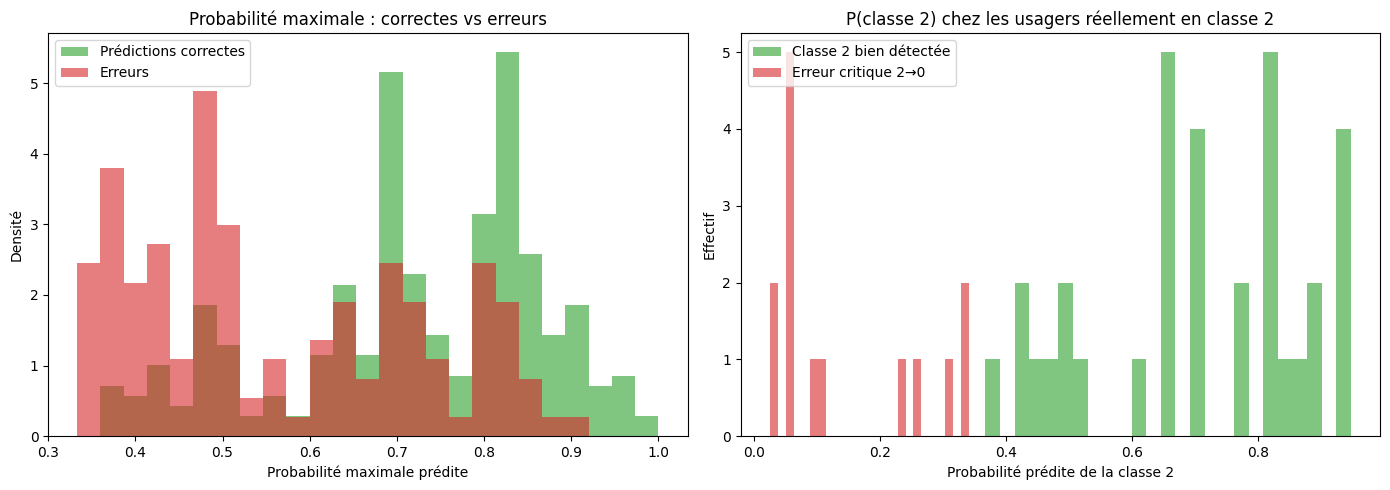

In [54]:
# Distribution des probabilités prédites sur les erreurs : détermination du seuil de rejet
# Étape 5 : toute l'analyse se fait sur X_calibration, jamais sur X_holdout.
proba = calibrated_model.predict_proba(X_calibration)
classes = list(calibrated_model.classes_)
idx_c2 = classes.index(2)
y_pred_calibration = np.asarray(classes)[proba.argmax(axis=1)].astype(int)

analyse = pd.DataFrame({
    "réel": y_calibration.to_numpy(),
    "prédit": y_pred_calibration,
    "p_max": proba.max(axis=1),
    "p_classe_2": proba[:, idx_c2],
}, index=X_calibration.index)
analyse["erreur"] = analyse["réel"] != analyse["prédit"]
analyse["erreur_2_vers_0"] = (analyse["réel"] == 2) & (analyse["prédit"] == 0)

print(f"Calibration : n={len(analyse)} | erreurs={analyse['erreur'].sum()} "
      f"| erreurs critiques 2→0={analyse['erreur_2_vers_0'].sum()}")
display(analyse.groupby("erreur")["p_max"].describe().round(3))

# --- 1) Distribution de la confiance : prédictions correctes vs erreurs ---
bins = np.linspace(1 / len(classes), 1, 26)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(analyse.loc[~analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Prédictions correctes", color="tab:green")
axes[0].hist(analyse.loc[analyse["erreur"], "p_max"], bins=bins, alpha=0.6,
             density=True, label="Erreurs", color="tab:red")
axes[0].set_title("Probabilité maximale : correctes vs erreurs")
axes[0].set_xlabel("Probabilité maximale prédite")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Focus classe 2 : probabilité de la classe 2 chez les vrais classe 2
vrais_c2 = analyse[analyse["réel"] == 2]
axes[1].hist(vrais_c2.loc[vrais_c2["prédit"] == 2, "p_classe_2"], bins=25, alpha=0.6,
             label="Classe 2 bien détectée", color="tab:green")
axes[1].hist(vrais_c2.loc[vrais_c2["erreur_2_vers_0"], "p_classe_2"], bins=25, alpha=0.6,
             label="Erreur critique 2→0", color="tab:red")
axes[1].set_title("P(classe 2) chez les usagers réellement en classe 2")
axes[1].set_xlabel("Probabilité prédite de la classe 2")
axes[1].set_ylabel("Effectif")
axes[1].legend()
plt.tight_layout()
plt.show()

,seuil,taux_abstention,accuracy_acceptés,erreurs_captées,2→0_restantes,taux_2→0_restant
0,0.350000,1.0%,66.2%,2.9%,14,19.4%
1,0.400000,8.5%,69.7%,19.6%,11,15.3%
2,0.450000,15.5%,72.2%,31.9%,11,15.3%
3,0.500000,24.2%,75.9%,47.1%,8,11.1%
4,0.550000,30.0%,78.2%,55.8%,6,8.3%
5,0.600000,32.5%,78.9%,58.7%,6,8.3%
6,0.650000,39.5%,81.0%,66.7%,6,8.3%
7,0.700000,48.0%,80.3%,70.3%,6,8.3%
8,0.750000,64.5%,84.5%,84.1%,2,2.8%
9,0.800000,67.0%,85.6%,86.2%,1,1.4%


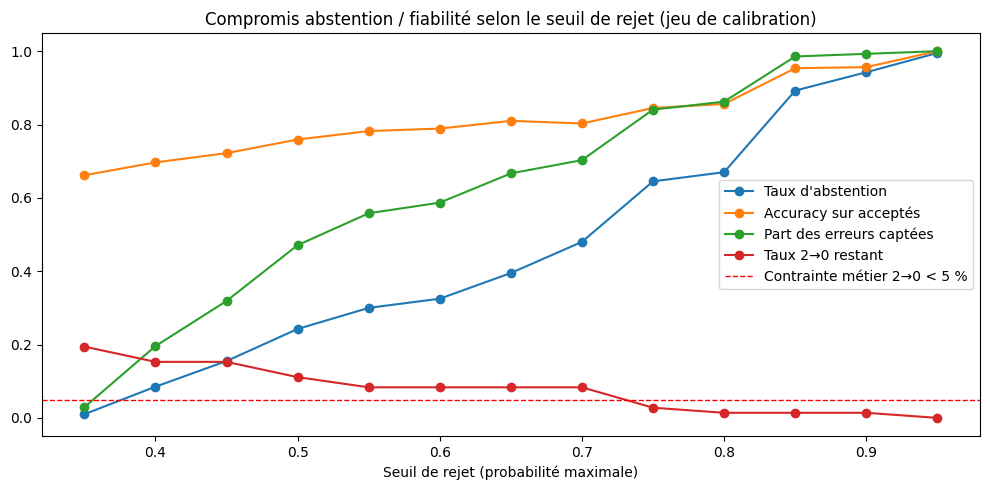

In [55]:
# --- 2) Balayage des seuils de rejet sur la probabilité maximale ---
# `analyse` provient de X_calibration : le seuil est choisi sans jamais regarder le holdout.
n_total = len(analyse)
n_c2 = int((analyse["réel"] == 2).sum())
resultats = []
for seuil in np.round(np.arange(0.35, 0.96, 0.05), 2):
    acceptes = analyse[analyse["p_max"] >= seuil]
    rejetes = analyse[analyse["p_max"] < seuil]
    resultats.append({
        "seuil": seuil,
        "taux_abstention": len(rejetes) / n_total,
        "accuracy_acceptés": (~acceptes["erreur"]).mean() if len(acceptes) else np.nan,
        "erreurs_captées": rejetes["erreur"].sum() / max(analyse["erreur"].sum(), 1),
        "2→0_restantes": int(acceptes["erreur_2_vers_0"].sum()),
        "taux_2→0_restant": acceptes["erreur_2_vers_0"].sum() / max(n_c2, 1),
    })
seuils_df = pd.DataFrame(resultats)
display(seuils_df.style.format({
    "taux_abstention": "{:.1%}", "accuracy_acceptés": "{:.1%}",
    "erreurs_captées": "{:.1%}", "taux_2→0_restant": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seuils_df["seuil"], seuils_df["taux_abstention"], marker="o", label="Taux d'abstention")
ax.plot(seuils_df["seuil"], seuils_df["accuracy_acceptés"], marker="o", label="Accuracy sur acceptés")
ax.plot(seuils_df["seuil"], seuils_df["erreurs_captées"], marker="o", label="Part des erreurs captées")
ax.plot(seuils_df["seuil"], seuils_df["taux_2→0_restant"], marker="o", label="Taux 2→0 restant")
ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="Contrainte métier 2→0 < 5 %")
ax.set_xlabel("Seuil de rejet (probabilité maximale)")
ax.set_title("Compromis abstention / fiabilité selon le seuil de rejet (jeu de calibration)")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# --- 3) Choix du seuil : couverture maximale sous contraintes ---
TAUX_2_VERS_0_MAX = 0.05      # cible 
ABSTENTION_MAX = 0.30         # capacité de revue humaine

candidats = seuils_df[
    (seuils_df["taux_2→0_restant"] < TAUX_2_VERS_0_MAX)
    & (seuils_df["taux_abstention"] <= ABSTENTION_MAX)
]
if candidats.empty:
    print("Aucun seuil ne respecte les deux contraintes : "
          "revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.")
else:
    seuil_rejet = candidats.sort_values("seuil").iloc[0]
    print(f"Seuil de rejet retenu : p_max < {seuil_rejet['seuil']:.2f} → abstention")
    print(f"  Taux d'abstention      : {seuil_rejet['taux_abstention']:.1%}")
    print(f"  Accuracy sur acceptés  : {seuil_rejet['accuracy_acceptés']:.1%}")
    print(f"  Erreurs captées        : {seuil_rejet['erreurs_captées']:.1%}")
    print(f"  Taux 2→0 restant       : {seuil_rejet['taux_2→0_restant']:.1%}")

# --- 4) Règle complémentaire classe 2 : P(classe 2) intermédiaire alors que la prédiction est 0 ---
p2_erreurs_critiques = analyse.loc[analyse["erreur_2_vers_0"], "p_classe_2"]
if len(p2_erreurs_critiques):
    seuil_p2 = float(p2_erreurs_critiques.quantile(0.10))
    predits_0 = analyse[analyse["prédit"] == 0]
    escalades = predits_0[predits_0["p_classe_2"] >= seuil_p2]
    print(f"\nRègle classe 2 : prédiction 0 avec P(classe 2) ≥ {seuil_p2:.2f} → escalade humaine")
    print(f"  Erreurs 2→0 captées : {escalades['erreur_2_vers_0'].sum()} / {len(p2_erreurs_critiques)}")
    print(f"  Dossiers prédits 0 escaladés : {len(escalades)} / {len(predits_0)} "
          f"({len(escalades) / max(len(predits_0), 1):.1%})")

Aucun seuil ne respecte les deux contraintes : revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.

Règle classe 2 : prédiction 0 avec P(classe 2) ≥ 0.04 → escalade humaine
  Erreurs 2→0 captées : 12 / 14
  Dossiers prédits 0 escaladés : 102 / 154 (66.2%)


**Test abstention max revisé**

In [57]:
# --- 3)bis1 Choix du seuil : couverture maximale sous contraintes ---
TAUX_2_VERS_0_MAX = 0.05      # cible 
ABSTENTION_MAX = 0.65         # capacité de revue humaine

candidats = seuils_df[
    (seuils_df["taux_2→0_restant"] < TAUX_2_VERS_0_MAX)
    & (seuils_df["taux_abstention"] <= ABSTENTION_MAX)
]
if candidats.empty:
    print("Aucun seuil ne respecte les deux contraintes : "
          "revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.")
else:
    seuil_rejet = candidats.sort_values("seuil").iloc[0]
    print(f"Seuil de rejet retenu : p_max < {seuil_rejet['seuil']:.2f} → abstention")
    print(f"  Taux d'abstention      : {seuil_rejet['taux_abstention']:.1%}")
    print(f"  Accuracy sur acceptés  : {seuil_rejet['accuracy_acceptés']:.1%}")
    print(f"  Erreurs captées        : {seuil_rejet['erreurs_captées']:.1%}")
    print(f"  Taux 2→0 restant       : {seuil_rejet['taux_2→0_restant']:.1%}")

# --- 4) Règle complémentaire classe 2 : P(classe 2) intermédiaire alors que la prédiction est 0 ---
p2_erreurs_critiques = analyse.loc[analyse["erreur_2_vers_0"], "p_classe_2"]
if len(p2_erreurs_critiques):
    seuil_p2 = float(p2_erreurs_critiques.quantile(0.10))
    predits_0 = analyse[analyse["prédit"] == 0]
    escalades = predits_0[predits_0["p_classe_2"] >= seuil_p2]
    print(f"\nRègle classe 2 : prédiction 0 avec P(classe 2) ≥ {seuil_p2:.2f} → escalade humaine")
    print(f"  Erreurs 2→0 captées : {escalades['erreur_2_vers_0'].sum()} / {len(p2_erreurs_critiques)}")
    print(f"  Dossiers prédits 0 escaladés : {len(escalades)} / {len(predits_0)} "
          f"({len(escalades) / max(len(predits_0), 1):.1%})")

Seuil de rejet retenu : p_max < 0.75 → abstention
  Taux d'abstention      : 64.5%
  Accuracy sur acceptés  : 84.5%
  Erreurs captées        : 84.1%
  Taux 2→0 restant       : 2.8%

Règle classe 2 : prédiction 0 avec P(classe 2) ≥ 0.04 → escalade humaine
  Erreurs 2→0 captées : 12 / 14
  Dossiers prédits 0 escaladés : 102 / 154 (66.2%)


**Seuil révisé**

In [58]:
# --- 3)bis2 Choix du seuil : couverture maximale sous contraintes ---
TAUX_2_VERS_0_MAX = 0.085     # cible révisée 
ABSTENTION_MAX = 0.30         # capacité de revue humaine (à ajuster)

candidats = seuils_df[
    (seuils_df["taux_2→0_restant"] < TAUX_2_VERS_0_MAX)
    & (seuils_df["taux_abstention"] <= ABSTENTION_MAX)
]
if candidats.empty:
    print("Aucun seuil ne respecte les deux contraintes : "
          "revoir le budget d'abstention ou ajouter une règle spécifique à la classe 2.")
else:
    seuil_rejet = candidats.sort_values("seuil").iloc[0]
    print(f"Seuil de rejet retenu : p_max < {seuil_rejet['seuil']:.2f} → abstention")
    print(f"  Taux d'abstention      : {seuil_rejet['taux_abstention']:.1%}")
    print(f"  Accuracy sur acceptés  : {seuil_rejet['accuracy_acceptés']:.1%}")
    print(f"  Erreurs captées        : {seuil_rejet['erreurs_captées']:.1%}")
    print(f"  Taux 2→0 restant       : {seuil_rejet['taux_2→0_restant']:.1%}")

# --- 4) Règle complémentaire classe 2 : P(classe 2) intermédiaire alors que la prédiction est 0 ---
p2_erreurs_critiques = analyse.loc[analyse["erreur_2_vers_0"], "p_classe_2"]
if len(p2_erreurs_critiques):
    seuil_p2 = float(p2_erreurs_critiques.quantile(0.10))
    predits_0 = analyse[analyse["prédit"] == 0]
    escalades = predits_0[predits_0["p_classe_2"] >= seuil_p2]
    print(f"\nRègle classe 2 : prédiction 0 avec P(classe 2) ≥ {seuil_p2:.2f} → escalade humaine")
    print(f"  Erreurs 2→0 captées : {escalades['erreur_2_vers_0'].sum()} / {len(p2_erreurs_critiques)}")
    print(f"  Dossiers prédits 0 escaladés : {len(escalades)} / {len(predits_0)} "
          f"({len(escalades) / max(len(predits_0), 1):.1%})")

Seuil de rejet retenu : p_max < 0.55 → abstention
  Taux d'abstention      : 30.0%
  Accuracy sur acceptés  : 78.2%
  Erreurs captées        : 55.8%
  Taux 2→0 restant       : 8.3%

Règle classe 2 : prédiction 0 avec P(classe 2) ≥ 0.04 → escalade humaine
  Erreurs 2→0 captées : 12 / 14
  Dossiers prédits 0 escaladés : 102 / 154 (66.2%)


In [59]:
# --- Étape 6 : application UNIQUE du seuil retenu sur le vrai holdout ---
# ⚠️ Ne pas ré-exécuter cette cellule avec d'autres seuils : ajuster le seuil
# d'après ce résultat reviendrait à régler sur le holdout et invaliderait le chiffre final.
if candidats.empty:
    raise RuntimeError("Aucun seuil retenu sur le jeu de calibration : rien à confirmer sur le holdout.")

SEUIL_REJET = float(seuil_rejet["seuil"])
proba_holdout = calibrated_model.predict_proba(X_holdout)
final = pd.DataFrame({
    "réel": y_holdout.to_numpy(),
    "prédit": np.asarray(classes)[proba_holdout.argmax(axis=1)].astype(int),
    "p_max": proba_holdout.max(axis=1),
    "p_classe_2": proba_holdout[:, idx_c2],
}, index=X_holdout.index)
final["erreur_2_vers_0"] = (final["réel"] == 2) & (final["prédit"] == 0)
final["abstention"] = final["p_max"] < SEUIL_REJET

acceptes_final = final[~final["abstention"]]
n_c2_holdout = max(int((final["réel"] == 2).sum()), 1)

print(f"Résultat final sur le holdout (n={len(final)}) — seuil p_max < {SEUIL_REJET:.2f}")
print(f"  Taux d'abstention      : {final['abstention'].mean():.1%}")
print(f"  Accuracy sur acceptés  : {(acceptes_final['réel'] == acceptes_final['prédit']).mean():.1%}")
print(f"  Erreurs 2→0 restantes  : {int(acceptes_final['erreur_2_vers_0'].sum())}")
print(f"  Taux 2→0 restant       : {acceptes_final['erreur_2_vers_0'].sum() / n_c2_holdout:.1%}")

if "seuil_p2" in globals():
    escalade_c2 = (final["prédit"] == 0) & (final["p_classe_2"] >= seuil_p2)
    revue = final["abstention"] | escalade_c2
    restantes = final.loc[~revue, "erreur_2_vers_0"].sum()
    print(f"\nAvec la règle classe 2 (P(classe 2) ≥ {seuil_p2:.2f} si prédit 0) :")
    print(f"  Taux de revue humaine  : {revue.mean():.1%}")
    print(f"  Taux 2→0 restant       : {restantes / n_c2_holdout:.1%}")

Résultat final sur le holdout (n=500) — seuil p_max < 0.55
  Taux d'abstention      : 30.4%
  Accuracy sur acceptés  : 75.9%
  Erreurs 2→0 restantes  : 1
  Taux 2→0 restant       : 1.1%

Avec la règle classe 2 (P(classe 2) ≥ 0.04 si prédit 0) :
  Taux de revue humaine  : 41.6%
  Taux 2→0 restant       : 1.1%


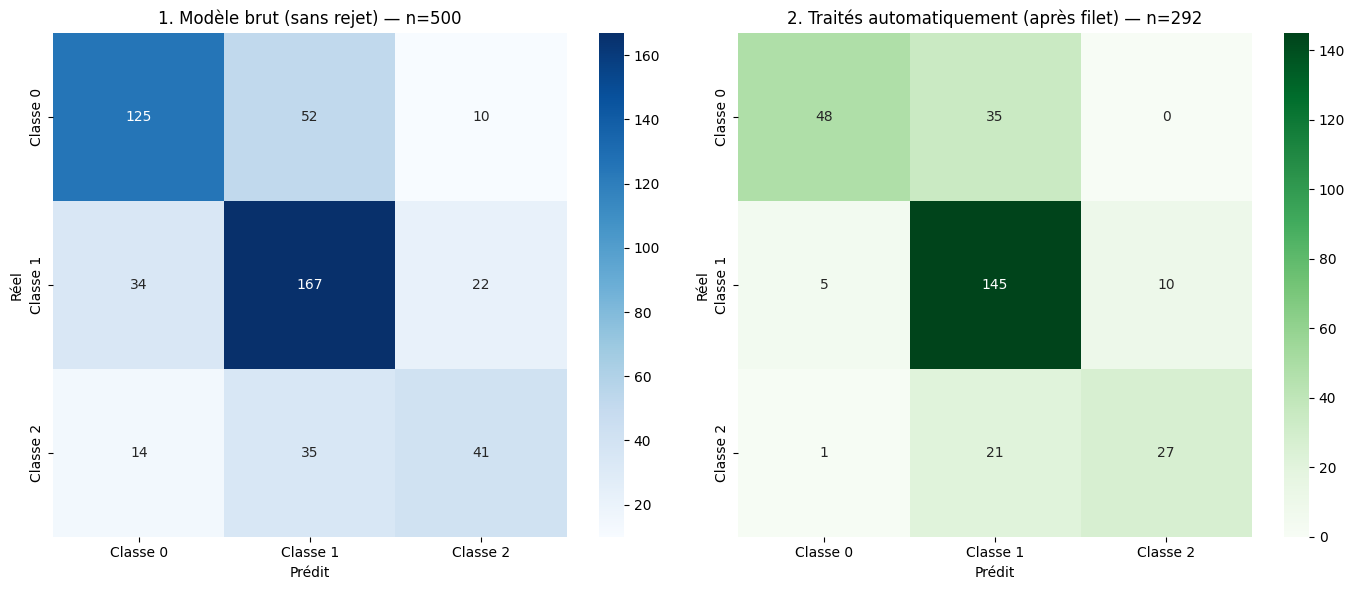


--- Synthèse des flux de décision sur le Holdout ---
Total dossiers holdout : 500
Traités automatiquement : 292 (58.4%)
Basculés en revue humaine : 208 (41.6%)


In [60]:
# --- Étape 7 : Génération et affichage des matrices de confusion (Holdout) ---
# Vérification de la présence des variables requises
if "final" not in globals():
    raise NameError("Veuillez d'abord exécuter l'Étape 6 (création du DataFrame 'final' sur le holdout).")

# 1. Identification des classes
classes_uniques = sorted(final["réel"].unique())
noms_classes = [f"Classe {c}" for c in classes_uniques]

# 2. Matrice de confusion brute (sur tout le holdout)
cm_brute = confusion_matrix(final["réel"], final["prédit"], labels=classes_uniques)

# 3. Matrice de confusion après application du filet de sécurité (Rejet + Escalade)
s_p2 = seuil_p2 if "seuil_p2" in globals() else 0.04
revue_holdout = final["abstention"] | ((final["prédit"] == 0) & (final["p_classe_2"] >= s_p2))
acceptes_strict = final[~revue_holdout]

cm_acceptes = confusion_matrix(
    acceptes_strict["réel"], 
    acceptes_strict["prédit"], 
    labels=classes_uniques
)

# 4. Affichage graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_brute, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=noms_classes, yticklabels=noms_classes)
axes[0].set_title(f"1. Modèle brut (sans rejet) — n={len(final)}")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

sns.heatmap(cm_acceptes, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=noms_classes, yticklabels=noms_classes)
axes[1].set_title(f"2. Traités automatiquement (après filet) — n={len(acceptes_strict)}")
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.show()

# 5. Synthèse des flux
print("\n--- Synthèse des flux de décision sur le Holdout ---")
print(f"Total dossiers holdout : {len(final)}")
print(f"Traités automatiquement : {len(acceptes_strict)} ({len(acceptes_strict)/len(final):.1%})")
print(f"Basculés en revue humaine : {revue_holdout.sum()} ({revue_holdout.mean():.1%})")

**Montant illustratif utilisé uniquement pour l'analyse économique du pilote:**

Coûts illustratifs : 15 € par revue, 1 000 € par erreur critique, sur 500 dossiers du holdout.

| Dispositif | Erreurs 2→0 (sur 90) | Taux observé | Revue humaine | Coût revue | Coût erreurs | Coût total |
|------------|----------------------|--------------|---------------|------------|--------------|------------|
| Modèle sauvegardé, sans filet* | 7 | 7,8 % | 0 % | 0 € | 7 000 € | 7 000 € |
| Pipeline calibré (§7.2), sans filet | 14 | 15,6 % | 0 % | 0 € | 14 000 € | 14 000 € |
| Calibré + abstention p_max < 0,55 | 1 | 1,1 % | 30,4 % (152) | 2 280 € | 1 000 € | 3 280 € |
| Calibré + abstention + règle P(classe 2) ≥ 0,04 | 1 | 1,1 % | 41,6 % (208) | 3 120 € | 1 000 € | 4 120 € |


*Modèle sauvegardé, sans filet*: *Référence non comparable aux lignes suivantes (autre modèle)**

>La règle complémentaire (prédit 0 et P(classe 2) ≥ 4 %) est proposée comme **option, désactivée par défaut**. Elle porte la revue humaine de 30,4 % à 41,6 % des dossiers (+56 sur 500), au-delà des 30 % visés ; le client a accepté ce surcoût au nom de la priorité donnée à la sécurité. Son bénéfice n'est pas démontré sur le holdout : l'erreur critique résiduelle est la même avec et sans la règle (1 sur 90), et cet effectif ne permet pas de distinguer les deux configurations. 
**Son intérêt repose sur le jeu de calibration, où elle capte 12 des 14 erreurs critiques du pipeline sans filet. Le client l'active selon sa charge de revue, et le pilote mesurera ce qu'elle apporte réellement.**

In [61]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Trouver src/ pour réutiliser le feature engineering du projet.
racine_projet = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "src" / "preprocess.py").is_file()
    ),
    None,
)
if racine_projet is None:
    raise FileNotFoundError("Impossible de trouver src/preprocess.py.")

sys.path.insert(0, str(racine_projet / "src"))

from config import DATA_PATH
from preprocess import create_features

MIN_N = 20
MIN_N_C2 = 10

# Charger les codes comme du texte, puis créer les features dérivées.
raw = pd.read_csv(
    DATA_PATH,
    dtype={
        "code_insee_commune": "string",
        "code_rome_vise": "string",
    },
)
raw = create_features(raw)


def departement_depuis_insee(value):
    if pd.isna(value):
        return "INCONNU"

    code = str(value).strip().upper()
    if code.endswith(".0"):
        code = code[:-2]

    if code.startswith(("2A", "2B")):
        return code[:2]

    if code[:3] in {"971", "972", "973", "974", "976"}:
        return code[:3]

    if code.isdigit():
        code = code.zfill(5)

    return code[:2] if len(code) >= 2 else "INCONNU"


# Conserver les codes DOM séparés; create_features les regroupe sous "97".
raw["departement"] = raw["code_insee_commune"].map(departement_depuis_insee)

COLS_AUDIT = [
    "synthese_entretien",
    "niveau_diplome",
    "age",
    "nationalite_hors_ue",
    "code_rome_vise",
    "anciennete_poste_ans",
    "est_allocataire",
    "departement",
]

index_absents = final.index.difference(raw.index)
if not index_absents.empty:
    raise ValueError(
        f"Index de final absents du CSV : {index_absents[:5].tolist()}"
    )

# Vérifier l'alignement des lignes du holdout avec le CSV.
for col in ["synthese_entretien", "niveau_diplome"]:
    du_csv = raw.loc[final.index, col].fillna("∅").to_numpy()
    du_modele = X_holdout.loc[final.index, col].fillna("∅").to_numpy()
    assert (du_csv == du_modele).all(), (
        f"Index non alignés sur {col!r} : final ne correspond pas au CSV."
    )

profil = final.join(raw[COLS_AUDIT], how="left")

REGION_PAR_DEPARTEMENT = {
    **dict.fromkeys(
        ["01", "03", "07", "15", "26", "38", "42", "43", "63", "69", "73", "74"],
        "Auvergne-Rhône-Alpes",
    ),
    **dict.fromkeys(
        ["21", "25", "39", "58", "70", "71", "89", "90"],
        "Bourgogne-Franche-Comté",
    ),
    **dict.fromkeys(["22", "29", "35", "56"], "Bretagne"),
    **dict.fromkeys(
        ["18", "28", "36", "37", "41", "45"],
        "Centre-Val de Loire",
    ),
    "2A": "Corse",
    "2B": "Corse",
    **dict.fromkeys(
        ["08", "10", "51", "52", "54", "55", "57", "67", "68", "88"],
        "Grand Est",
    ),
    **dict.fromkeys(
        ["02", "59", "60", "62", "80"],
        "Hauts-de-France",
    ),
    **dict.fromkeys(
        ["75", "77", "78", "91", "92", "93", "94", "95"],
        "Île-de-France",
    ),
    **dict.fromkeys(
        ["14", "27", "50", "61", "76"],
        "Normandie",
    ),
    **dict.fromkeys(
        ["16", "17", "19", "23", "24", "33", "40", "47", "64", "79", "86", "87"],
        "Nouvelle-Aquitaine",
    ),
    **dict.fromkeys(
        ["09", "11", "12", "30", "31", "32", "34", "46", "48", "65", "66", "81", "82"],
        "Occitanie",
    ),
    **dict.fromkeys(
        ["44", "49", "53", "72", "85"],
        "Pays de la Loire",
    ),
    **dict.fromkeys(
        ["04", "05", "06", "13", "83", "84"],
        "Provence-Alpes-Côte d’Azur",
    ),
    "971": "Guadeloupe",
    "972": "Martinique",
    "973": "Guyane",
    "974": "La Réunion",
    "976": "Mayotte",
}

ROME_FAMILLE = {
    "A": "A · Agriculture et pêche",
    "B": "B · Arts et façonnage",
    "C": "C · Banque, assurance, immobilier",
    "D": "D · Commerce et distribution",
    "E": "E · Communication et média",
    "F": "F · Construction et BTP",
    "G": "G · Hôtellerie, restauration, tourisme",
    "H": "H · Industrie",
    "I": "I · Installation et maintenance",
    "J": "J · Santé",
    "K": "K · Services à la personne et à la collectivité",
    "L": "L · Spectacle",
    "M": "M · Support à l’entreprise",
    "N": "N · Transport et logistique",
}

profil["region"] = (
    profil["departement"]
    .astype("string")
    .str.strip()
    .map(REGION_PAR_DEPARTEMENT)
    .fillna("Région inconnue")
)

profil["rome_famille"] = (
    profil["code_rome_vise"]
    .astype("string")
    .str.strip()
    .str[0]
    .str.upper()
    .map(ROME_FAMILLE)
    .fillna("Autre / inconnu")
)

# Filet réellement appliqué : abstention et éventuelle escalade de classe 2.
if "seuil_p2" in globals():
    escalade_c2 = (
        (profil["prédit"] == 0)
        & (profil["p_classe_2"] >= seuil_p2)
    )
    profil["revue"] = profil["abstention"] | escalade_c2
    FILET = (
        f"p_max < {SEUIL_REJET:.2f} + "
        f"règle P(classe 2) ≥ {seuil_p2:.2f}"
    )
else:
    profil["revue"] = profil["abstention"]
    FILET = f"p_max < {SEUIL_REJET:.2f}"

profil["non_signalee_2_0"] = (
    profil["erreur_2_vers_0"] & ~profil["revue"]
)
profil["erreur"] = profil["réel"] != profil["prédit"]

# Regroupements utilisés pour l'audit.
profil["ensemble"] = "Ensemble"
profil["gabarit"] = (
    profil["synthese_entretien"]
    .fillna("MANQUANT")
    .str.split(".", regex=False)
    .str[0]
)
profil["niveau_diplome"] = profil["niveau_diplome"].fillna("MANQUANT")
profil["code_rome_vise"] = profil["code_rome_vise"].fillna("MANQUANT")
profil["departement"] = profil["departement"].fillna("INCONNU")

FORMULATIONS_DIFFICILES = [
    "Cumul de difficultés",
    "Freins périphériques majeurs",
    "Perte de confiance importante",
]
profil["texte_signale"] = np.where(
    profil["gabarit"].isin(FORMULATIONS_DIFFICILES),
    "difficulté signalée",
    "formulation ordinaire",
)

# Optionnel : comparaison avec les prédictions du modèle servi.
if "pred_servi" in globals():
    profil["prédit_servi"] = pd.Series(
        np.asarray(pred_servi),
        index=X_holdout.index,
    ).reindex(profil.index)

profil["tranche_age"] = (
    pd.cut(
        profil["age"],
        bins=[0, 25, 45, 120],
        labels=["≤ 25", "26-45", "> 45"],
    )
    .astype(object)
    .fillna("Non renseigné")
)

profil["nationalite_hors_ue"] = (
    profil["nationalite_hors_ue"]
    .map({0: "UE", 1: "hors UE"})
    .fillna("Non renseigné")
)

profil["tranche_anciennete"] = (
    pd.cut(
        profil["anciennete_poste_ans"],
        bins=[-np.inf, 2, 5, 10, 20, np.inf],
        labels=["≤ 2 ans", "2-5 ans", "5-10 ans", "10-20 ans", "> 20 ans"],
    )
    .astype(object)
    .fillna("Non renseigné")
)

profil["est_allocataire"] = (
    profil["est_allocataire"]
    .map({0: "Non", 1: "Oui"})
    .fillna("Non renseigné")
)


def wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    marge = z * np.sqrt(
        p * (1 - p) / n + z**2 / (4 * n**2)
    ) / denom

    return max(0.0, centre - marge), min(1.0, centre + marge)


def audit(colonne):
    lignes = []

    for groupe, donnees in profil.groupby(colonne, dropna=False):
        n = len(donnees)
        n_classe_2 = int((donnees["réel"] == 2).sum())
        ligne = {
            colonne: groupe,
            "n": n,
            "n_classe_2": n_classe_2,
        }

        if n >= MIN_N:
            lo, hi = wilson(int(donnees["erreur"].sum()), n)
            ligne.update(
                {
                    "erreur_brute": donnees["erreur"].mean(),
                    "IC95_erreur": f"[{lo:.0%} ; {hi:.0%}]",
                    "revue_humaine": donnees["revue"].mean(),
                }
            )

        if n_classe_2 >= MIN_N_C2:
            k = int(donnees["non_signalee_2_0"].sum())
            lo, hi = wilson(k, n_classe_2)
            ligne.update(
                {
                    "2→0_non_signalées": k,
                    "taux_2→0": k / n_classe_2,
                    "IC95_2→0": f"[{lo:.0%} ; {hi:.0%}]",
                }
            )

        lignes.append(ligne)

    return pd.DataFrame(lignes)


GROUPES_A_AUDITER = [
    "ensemble",
    "gabarit",
    "texte_signale",
    "niveau_diplome",
    "rome_famille",
    "tranche_age",
    "nationalite_hors_ue",
    "tranche_anciennete",
    "est_allocataire",
    "region",
]

print(f"Filet appliqué : {FILET}")
print(
    "taux_2→0 = part des usagers de classe 2 restant classés 0 "
    "sans revue humaine."
)

for colonne in GROUPES_A_AUDITER:
    print(
        f"\n--- {colonne} "
        f"(erreur brute masquée si n < {MIN_N} ; "
        f"taux 2→0 masqué si moins de {MIN_N_C2} usagers de classe 2) ---"
    )

    tableau = audit(colonne)
    formats = {
        col: "{:.1%}"
        for col in ["erreur_brute", "revue_humaine", "taux_2→0"]
        if col in tableau.columns
    }

    if "2→0_non_signalées" in tableau.columns:
        formats["2→0_non_signalées"] = "{:.0f}"

    display(tableau.style.format(formats, na_rep="—"))

Filet appliqué : p_max < 0.55 + règle P(classe 2) ≥ 0.04
taux_2→0 = part des usagers de classe 2 restant classés 0 sans revue humaine.

--- ensemble (erreur brute masquée si n < 20 ; taux 2→0 masqué si moins de 10 usagers de classe 2) ---


,ensemble,n,n_classe_2,erreur_brute,IC95_erreur,revue_humaine,2→0_non_signalées,taux_2→0,IC95_2→0
0,Ensemble,500,90,33.4%,[29% ; 38%],41.6%,1,1.1%,[0% ; 6%]



--- gabarit (erreur brute masquée si n < 20 ; taux 2→0 masqué si moins de 10 usagers de classe 2) ---


,gabarit,n,n_classe_2,erreur_brute,IC95_erreur,revue_humaine,2→0_non_signalées,taux_2→0,IC95_2→0
0,"Candidat très dynamique, mobilité nationale validée",52,4,25.0%,[15% ; 38%],67.3%,—,—,—
1,Compétences à réactualiser sur les outils numériques,66,7,25.8%,[17% ; 37%],3.0%,—,—,—
2,Cumul de difficultés,44,14,56.8%,[42% ; 70%],63.6%,0,0.0%,[0% ; 22%]
3,"Excellente présentation, compétences techniques à jour",53,2,28.3%,[18% ; 42%],60.4%,—,—,—
4,Freins périphériques majeurs,43,23,55.8%,[41% ; 70%],79.1%,0,0.0%,[0% ; 14%]
5,MANQUANT,14,3,—,—,—,—,—,—
6,Perte de confiance importante,34,21,29.4%,[17% ; 46%],58.8%,0,0.0%,[0% ; 15%]
7,Problème ponctuel de mobilité géographique,71,6,25.4%,[17% ; 37%],5.6%,—,—,—
8,"Profil autonome, recherche active, aucun frein périphérique identifié",58,3,27.6%,[18% ; 40%],67.2%,—,—,—
9,Projet de reconversion à affiner,65,7,32.3%,[22% ; 44%],6.2%,—,—,—



--- texte_signale (erreur brute masquée si n < 20 ; taux 2→0 masqué si moins de 10 usagers de classe 2) ---


...

,tranche_anciennete,n,n_classe_2,erreur_brute,IC95_erreur,revue_humaine,2→0_non_signalées,taux_2→0,IC95_2→0
0,10-20 ans,21,10,33.3%,[17% ; 55%],42.9%,0,0.0%,[0% ; 28%]
1,2-5 ans,141,23,36.9%,[29% ; 45%],41.8%,0,0.0%,[0% ; 14%]
2,5-10 ans,71,13,28.2%,[19% ; 40%],35.2%,1,7.7%,[1% ; 33%]
3,> 20 ans,1,1,—,—,—,—,—,—
4,≤ 2 ans,266,43,33.1%,[28% ; 39%],42.9%,0,0.0%,[0% ; 8%]



--- est_allocataire (erreur brute masquée si n < 20 ; taux 2→0 masqué si moins de 10 usagers de classe 2) ---


,est_allocataire,n,n_classe_2,erreur_brute,IC95_erreur,revue_humaine,2→0_non_signalées,taux_2→0,IC95_2→0
0,Non,208,44,34.6%,[28% ; 41%],42.8%,0,0.0%,[0% ; 8%]
1,Non renseigné,6,0,—,—,—,—,—,—
2,Oui,286,46,32.5%,[27% ; 38%],41.3%,1,2.2%,[0% ; 11%]



--- region (erreur brute masquée si n < 20 ; taux 2→0 masqué si moins de 10 usagers de classe 2) ---


,region,n,n_classe_2,erreur_brute,IC95_erreur,revue_humaine,2→0_non_signalées,taux_2→0,IC95_2→0
0,Auvergne-Rhône-Alpes,46,7,26.1%,[16% ; 40%],34.8%,—,—,—
1,Bourgogne-Franche-Comté,57,8,36.8%,[26% ; 50%],42.1%,—,—,—
2,Bretagne,13,1,—,—,—,—,—,—
3,Centre-Val de Loire,24,5,33.3%,[18% ; 53%],25.0%,—,—,—
4,Corse,4,1,—,—,—,—,—,—
5,Grand Est,74,17,37.8%,[28% ; 49%],45.9%,0,0.0%,[0% ; 18%]
6,Hauts-de-France,57,14,42.1%,[30% ; 55%],43.9%,0,0.0%,[0% ; 22%]
7,La Réunion,1,1,—,—,—,—,—,—
8,Normandie,42,6,26.2%,[15% ; 41%],38.1%,—,—,—
9,Nouvelle-Aquitaine,71,14,35.2%,[25% ; 47%],43.7%,0,0.0%,[0% ; 22%]


**Intérprétation**
- Régions: 3 régions sur 14 passent le seuil pour calculer le taux 2→0 (Grand Est, Hauts-de-France, Nouvelle-Aquitaine). Il est de 0 % dans les trois, avec des intervalles de confiance jusqu'à 22 %. Les 11 autres sont masquées (moins de 10 usagers de classe 2).

- Familles de métiers: 5 familles sur 12 passent le seuil. Le taux 2→0 est de 0 % pour Agriculture (22 usagers de classe 2), Services à la personne (18) et Transport (12). Il est de 10 % pour Support à l'entreprise (1 erreur sur 10, IC : 2–40 %).

- l'erreur restante sur: probablement dans la famille Support à l'entreprise. un dossier 26–45 ans, UE, Bac+2, ancienneté 5–10 ans, allocataire, avec une formulation ordinaire. C'est un seul dossier, donc rien qui ressemble à un biais.

- Pas de signal territorial. L'erreur brute varie de 26 % (Auvergne-Rhône-Alpes, Normandie) à 42 % (Hauts-de-France), mais les intervalles se chevauchent (par exemple 16–40 % contre 30–55 %). La revue humaine va de 25 % (Centre-Val de Loire) à 46 % (Grand Est), sans schéma net.

- Peu de signal par métier. L'erreur brute va de 27 % (Commerce) à 42 % (Banque, assurance, immobilier) et 40 % (Support). La revue humaine va de 26 % (Industrie) à 46 % (Support). Le groupe Banque compte seulement 5 usagers de classe 2, donc ce n'est pas interprétable.

- L'Agriculture concentre les cas à risque. 22 usagers de classe 2 sur 56 dossiers (39 %), soit près d'un quart de tous les usagers de classe 2. Le filet les relit à 44,6 % et ne laisse passer aucune erreur critique.

**Synthèse**

Le filet de sécurité ne laisse passer qu'une erreur critique sur 90 usagers à risque, sans écart visible selon l'âge, la nationalité, le diplôme, la région ou le métier. Les effectifs par groupe sont trop faibles pour démontrer l'équité : ce suivi devra être répété en production sur des volumes plus importants.

In [62]:
# =============================================================================
# Audit d'équité par groupe : FNR et FPR de la classe 2, avec intervalles de Wilson
# FNR = part des usagers réellement en classe 2 que le modèle ne prédit PAS en classe 2 (= 1 - recall)
# FPR = part des usagers hors classe 2 que le modèle prédit à tort en classe 2
# Le masquage se fait sur le bon effectif : n classe 2 pour le FNR, n hors classe 2 pour le FPR.
# =============================================================================
def audit_fnr_fpr(colonne: str, pred_col: str = "prédit") -> pd.DataFrame:
    lignes = []
    for groupe, d in profil.groupby(colonne):
        pos = d["réel"] == 2
        n_pos, n_neg = int(pos.sum()), int((~pos).sum())
        ligne = {colonne: groupe, "n": len(d), "n_classe_2": n_pos, "n_hors_classe_2": n_neg}
        if n_pos >= MIN_N_C2:
            fn = int((pos & (d[pred_col] != 2)).sum())
            lo, hi = wilson(fn, n_pos)
            ligne.update({"FNR_C2": fn / n_pos, "IC95_FNR": f"[{lo:.0%} ; {hi:.0%}]"})
        if n_neg >= MIN_N:
            fp = int((~pos & (d[pred_col] == 2)).sum())
            lo, hi = wilson(fp, n_neg)
            ligne.update({"FPR_C2": fp / n_neg, "IC95_FPR": f"[{lo:.0%} ; {hi:.0%}]"})
        lignes.append(ligne)
    return pd.DataFrame(lignes)


# Prédictions auditées :
#   - `final["prédit"]`  = pipeline calibré de §7.2 (argmax des probabilités calibrées) ;
#   - `prédit_servi`     = modèle sauvegardé du service, si `pred_servi` a été défini avant la cellule.
JEUX_PREDICTIONS = {"pipeline calibré (§7.2)": "prédit"}
if "prédit_servi" in profil.columns:
    JEUX_PREDICTIONS["modèle sauvegardé (service)"] = "prédit_servi"

print("\n\n##### FNR / FPR de la classe 2 par groupe (IC de Wilson à 95 %) #####")
print(f"Masqué si moins de {MIN_N_C2} usagers de classe 2 (FNR) ou moins de {MIN_N} hors classe 2 (FPR).")
for nom_jeu, pred_col in JEUX_PREDICTIONS.items():
    print(f"\n======== Prédictions : {nom_jeu} ========")
    for colonne in ["ensemble", "tranche_age", "nationalite_hors_ue", "rome_famille" ,"texte_signale", "tranche_anciennete", "est_allocataire", "region"]:
        print(f"\n--- {colonne} ---")
        tableau = audit_fnr_fpr(colonne, pred_col=pred_col)
        formats = {c: "{:.1%}" for c in ["FNR_C2", "FPR_C2"] if c in tableau.columns}
        display(tableau.style.format(formats, na_rep="—"))



##### FNR / FPR de la classe 2 par groupe (IC de Wilson à 95 %) #####
Masqué si moins de 10 usagers de classe 2 (FNR) ou moins de 20 hors classe 2 (FPR).

======== Prédictions : pipeline calibré (§7.2) ========

--- ensemble ---


,ensemble,n,n_classe_2,n_hors_classe_2,FNR_C2,IC95_FNR,FPR_C2,IC95_FPR
0,Ensemble,500,90,410,54.4%,[44% ; 64%],7.8%,[6% ; 11%]



--- tranche_age ---


,tranche_age,n,n_classe_2,n_hors_classe_2,FNR_C2,IC95_FNR,FPR_C2,IC95_FPR
0,26-45,199,14,185,57.1%,[33% ; 79%],8.6%,[5% ; 14%]
1,> 45,195,60,135,55.0%,[42% ; 67%],5.2%,[3% ; 10%]
2,Non renseigné,22,5,17,—,—,—,—
3,≤ 25,84,11,73,36.4%,[15% ; 65%],9.6%,[5% ; 18%]



--- nationalite_hors_ue ---


...

,tranche_anciennete,n,n_classe_2,n_hors_classe_2,FNR_C2,IC95_FNR,FPR_C2,IC95_FPR
0,10-20 ans,21,10,11,40.0%,[17% ; 69%],—,—
1,2-5 ans,141,23,118,60.9%,[41% ; 78%],11.0%,[7% ; 18%]
2,5-10 ans,71,13,58,46.2%,[23% ; 71%],5.2%,[2% ; 14%]
3,> 20 ans,1,1,0,—,—,—,—
4,≤ 2 ans,266,43,223,58.1%,[43% ; 72%],5.8%,[3% ; 10%]



--- est_allocataire ---


,est_allocataire,n,n_classe_2,n_hors_classe_2,FNR_C2,IC95_FNR,FPR_C2,IC95_FPR
0,Non,208,44,164,52.3%,[38% ; 66%],8.5%,[5% ; 14%]
1,Non renseigné,6,0,6,—,—,—,—
2,Oui,286,46,240,56.5%,[42% ; 70%],7.5%,[5% ; 12%]



--- region ---


,region,n,n_classe_2,n_hors_classe_2,FPR_C2,IC95_FPR,FNR_C2,IC95_FNR
0,Auvergne-Rhône-Alpes,46,7,39,7.7%,[3% ; 20%],—,—
1,Bourgogne-Franche-Comté,57,8,49,4.1%,[1% ; 14%],—,—
2,Bretagne,13,1,12,—,—,—,—
3,Centre-Val de Loire,24,5,19,—,—,—,—
4,Corse,4,1,3,—,—,—,—
5,Grand Est,74,17,57,7.0%,[3% ; 17%],58.8%,[36% ; 78%]
6,Hauts-de-France,57,14,43,9.3%,[4% ; 22%],71.4%,[45% ; 88%]
7,La Réunion,1,1,0,—,—,—,—
8,Normandie,42,6,36,11.1%,[4% ; 25%],—,—
9,Nouvelle-Aquitaine,71,14,57,5.3%,[2% ; 14%],57.1%,[33% ; 79%]


**Audit FNR / FPR de la classe 2 (modèle seul, holdout)**

Le pipeline calibré ne détecte que 45,6 % des usagers de classe 2 (FNR 54,4 %, IC 95 % : 44–64 %) avec 7,8 % de fausses alertes : le filet de sécurité reste donc indispensable. Aucun écart significatif n'apparaît entre groupes d'âge, de nationalité, d'ancienneté ou d'allocation (intervalles larges et chevauchants). La prédiction dépend en revanche fortement du texte : lorsque la synthèse n'indique aucune difficulté, aucun usager de classe 2 n'est prédit (FNR 100 %), tandis que 42,9 % des usagers hors classe 2 ayant une difficulté signalée sont prédits à tort en classe 2. L'équité du dispositif repose donc en grande partie sur la qualité et l'homogénéité des synthèses rédigées par les conseillers. 
Ces résultats portent sur de petits effectifs et devront être confirmés en production, y compris sur le modèle effectivement servi.

### 7.3 Message au client

Un objectif de sécurité ajusté, en toute transparence. Nous visions au départ moins de 5 % d'erreurs critiques, c'est-à-dire des usagers à risque de plus de 12 mois classés « retour rapide ». Atteindre ce niveau aurait imposé de faire relire environ 65 % des dossiers par un conseiller, ce qui aurait annulé l'intérêt de l'outil. Nous proposons donc une cible de 8,5 %, qui préserve un volume significatif de dossiers traités sans relecture.

Ce que nous avons mesuré. Le dispositif fait relire par un conseiller les prédictions incertaines. Deux mesures sont disponibles, et aucune n'est assez précise pour trancher seule :

- Sur les données de réglage (72 usagers à risque), 6 erreurs critiques subsistent, soit 8,3 %.
Sur un échantillon de 500 dossiers, non utilisé pour régler le dispositif et comptant 90 usagers à risque, une seule erreur critique est observée (1,1 %), contre 14 pour la même version du modèle sans relecture (7 pour le modèle non calibré précédemment servi). Vu la petite taille de l'échantillon, le taux réel de cette mesure se situe entre 0,2 % et 6 %.

- L'écart entre ces deux mesures est trop grand pour être attribué au seul hasard (p = 0,045). Nous ne retenons donc ni l'une ni l'autre isolément. À titre indicatif, leur regroupement donne 7 erreurs sur 162 usagers à risque, soit 4,3 % (intervalle plausible de 2,1 % à 8,6 %), à interpréter avec prudence puisque les deux échantillons diffèrent. Cet intervalle est compatible avec la cible de 8,5 %, sans la garantir. Nous retenons donc 8,5 % comme plafond de sécurité à vérifier pendant le pilote, et non comme un taux déjà démontré. Le 1,1 % observé est une confirmation favorable, à vérifier sur un volume plus important.

**Option d'escalade de la classe 2 $P(\text{classe } 2) \ge 4\%$**. Si cette option est activée, la charge de travail des équipes augmente : 41,6 % des dossiers seraient relus (208 sur 500), contre 30 % visés au départ. Environ 11 points (56 dossiers) viennent d'une règle de précaution sur les signaux faibles de risque (prédiction « retour rapide » avec P(classe 2) ≥ 4 %). Elle n'a pas réduit le nombre d'erreurs sur le holdout, où l'erreur résiduelle est la même avec et sans la règle ; elle vise à protéger les cas sensibles (sur les données de réglage, elle capte 12 des 14 erreurs du pipeline sans relecture). Demande validée par le client, comme choix optionnel à tester. Pendant le pilote, la règle est désactivée par défaut et activable par le client selon la charge de relecture.

Ce que le pilote apportera. Un outil d'aide à la décision : il propose une orientation pour les situations les plus claires et oriente les dossiers incertains vers un conseiller, qui garde la décision finale. Pendant le pilote, nous suivrons le taux d'erreurs critiques (avec son intervalle de confiance), la charge de relecture et les écarts entre groupes (âge, nationalité, département). 

### 7.4 📝 Synthèse interprétation

**Résultat:** Sur le jeu de calibration (400 dossiers, dont 72 usagers de classe 2), le pipeline calibré laisse passer 14 erreurs critiques 2→0 (19,4 %). Avec le seuil retenu (p_max < 0,55), l'abstention est de 30,0 % et il reste 6 erreurs critiques (8,3 %).
8,5 % est le plafond révisé ; 8,3 % est la valeur mesurée (6/72). Avec 72 usagers, une erreur pèse 1,4 point : le plafond équivaut à « au plus 6 erreurs », et une 7ᵉ erreur donnerait 9,7 %.

**Cible initiale:** La cible de 5 % exigerait un seuil de 0,75, soit 64,5 % d'abstention, incompatible avec la capacité de revue (≤ 30 %). Elle a donc été révisée à 8,5 %.

**Limite du filet:** Entre 0,55 et 0,70, le taux reste à 8,3 % alors que l'abstention passe de 30 % à 48 % : les 6 erreurs restantes sont des erreurs confiantes (p_max > 0,70), hors de portée d'un seuil sur la confiance. La règle complémentaire (prédit 0 et P(classe 2) ≥ 0,04) capte 12 des 14 erreurs du pipeline sans filet, mais escalade 66 % des dossiers prédits 0.  Elle sécurise, au prix d'une charge de revue élevée.

**Confirmation:** Sur le holdout (500 dossiers, 90 de classe 2), il reste 1 erreur critique (1,1 %, intervalle de Wilson 0,2 à 6 %). L'effectif est trop faible pour conclure précisément. On retient 8,5 % comme plafond de sécurité à vérifier en pilote, et 8,3 % (mesure sur les données de réglage) pour dimensionner la charge de relecture.

---
## 8. Industrialisation

#### 8.0 Choix d'hébergement

| Critère | On-premise (datacenter de l'agence) | Cloud souverain qualifié SecNumCloud | Cloud public non souverain |
|-----------|-----------|-----------|-----------|
| **Confidentialité et juridiction** | Maîtrise totale, hors portée de lois extraterritoriales | Hébergeur européen, qualification ANSSI | Exposition possible à des lois extraterritoriales (ex. Cloud Act) |
| **Maîtrise de la donnée** | Totale | Contractuelle, auditée | Limitée |
| **Coût pour ce volume** | Faible si capacité existante, sinon investissement initial | Abonnement faible (petite instance) | Faible |
| **Montée en charge** | Limitée par le parc | Élastique | Élastique |
| **Exploitation** | À la charge de l'agence | Partagée | Partagée |
| **Cohérence avec le projet** | Le déploiement SSH du CI/CD cible déjà un serveur on-prem | Compatible (images GHCR, `docker compose`) | À écarter |

**Recommandation** : on-premise pour la production, ou à défaut cloud souverain qualifié ; cloud public non souverain exclu. Le volume est très faible : l'élasticité du cloud n'apporte aucun avantage. En revanche, les données traitées (texte libre d'entretien, identifiants d'usagers, système à haut risque) plaident pour la maîtrise la plus stricte. La chaîne CI/CD actuelle (images Docker, déploiement SSH par docker compose) fonctionne à l'identique sur les deux options retenues.

**Sécurité et gouvernance des données**

| Sujet | Disposition |
|---|---|
| **Authentification des appels** | Toutes les routes métier (`/score`, `/feedback`, `/history`) exigent une authentification de service (clé d'API ou mTLS) entre le guichet unique et l'API. Aujourd'hui seule la route `/train` est protégée (§8.2). |
| **Autorisation** | `/history` filtré par conseiller : un conseiller ne consulte que ses propres sessions. L'accès à « toutes les sessions » est réservé à un rôle de supervision. |
| **Chiffrement** | HTTPS entre le guichet unique et l'API (terminaison TLS sur le reverse proxy). Réseau privé pour les appels internes. |
| **Exposition réseau** | Seul le reverse proxy est publié. Les ports 8000 (modèle) et 8001 (backend) ne sont accessibles que sur le réseau interne (`expose` plutôt que `ports` dans `docker-compose`). Sinon `/predict` contourne la journalisation. |
| **Minimisation** | Le formulaire et l'API ne collectent ni `age` ni `nationalite_hors_ue`, qui ne sont pas utilisés par S2. |
| **Conservation** | Journal d'inférence : 12 mois. Feedbacks : conservés tant qu'ils servent à l'entraînement, revue annuelle. Durées à fixer avec le délégué à la protection des données. |
| **Journalisation des erreurs** | Chaque requête est journalisée, y compris les rejets (422, 502, 503) : voir le schéma `request_log` en partie C. |
| **AIPD** | Une analyse d'impact (art. 35 RGPD) est à conduire avant mise en production : profilage, système à haut risque, données de personnes en situation de fragilité. |
| **Supervision humaine** | L'interface affiche explicitement « revue humaine requise » en cas d'abstention, et le conseiller reste décisionnaire. |
|**Décision automatisée (art. 22 RGPD)** | Le dispositif est une aide à la décision : le conseiller est seul décisionnaire et sa décision est la seule enregistrée. Qualification juridique, information des usagers et droits de contestation |
|**Sur-confiance des conseillers** |	Affichage des probabilités et de la revue humaine requise ; formation sur les limites chiffrées de l'outil ; suivi du taux de concordance et d'infirmation (§9.1). Aucun usage de la prédiction comme critère automatique de décision.|

#### 8.1.1 Modèle servi

Le service d’inférence charge le pipeline suivant :

```text
cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_calibrated.joblib
```

**Caractéristiques du modèle**

| Propriété | Valeur |
|---|---|
| Nom du modèle | `cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_calibrated` |
| Version du modèle | `v1.1.0-calibrated` |
| Scénario | `multimodal_ethique` |
| Configuration | `best_class_2_ethique` |
| Algorithme | XGBoost multiclasse |
| Version scikit-learn | `1.5.1` |
| Version XGBoost | `2.1.3` |


**Métadonnées et reproductibilité**

Chaque artefact `joblib` est accompagné d’un fichier JSON de métadonnées.

Ce fichier contient notamment :
- le nom du modèle ;
- la version du modèle ;
- le scénario d’entraînement ;
- la date d’entraînement ;
- les hyperparamètres retenus ;
- les variables utilisées par le pipeline ;
- les versions des principales bibliothèques ;
- l’empreinte SHA-256 du dataset ;
- les indices des observations du holdout ;
- les métriques d’évaluation ;
- les identifiants des runs MLflow associés ;
- les informations nécessaires à la reproduction de l’entraînement.

L’empreinte SHA-256 du dataset commence par :

```text
2b9cb8c8…
```

L’empreinte complète est conservée dans le fichier JSON de métadonnées.

Elle permet de vérifier que le dataset utilisé pour reproduire l’entraînement est strictement identique au dataset d’origine.


**Sélection du modèle au démarrage**

La variable d’environnement suivante détermine l’artefact chargé par le service :

```text
MODEL_ARTIFACT
```

Au démarrage de l’application, le service :

1. récupère la valeur de `MODEL_ARTIFACT` ;
2. localise l’artefact correspondant ;
3. charge le pipeline `joblib` ;
4. charge les métadonnées JSON associées ;
5. expose les informations du modèle chargé.

Le modèle effectivement servi est identifiable à partir :

- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info`.

Ces deux mécanismes exposent notamment :

- le nom du modèle ;
- sa version ;
- le scénario associé ;
- l’artefact effectivement chargé.

Cela permet de vérifier que le modèle exécuté par le service correspond bien au modèle attendu lors du déploiement.

#### 8.1.2 Stratégie de persistance

Chaque modèle est enregistré sous la forme :
- d’un fichier `joblib` contenant le pipeline ;
- d’un fichier JSON contenant les métadonnées associées.

Un nouvel entraînement n'écrase pas le modèle stable.
Les artefacts sont distingués selon leur statut :

```text
cisia_emploi_candidate
cisia_emploi_promoted
modèle stable
```

**Cycle de vie d’un modèle**

```text
Réentraînement
      ↓
Création du modèle candidat
      ↓
Évaluation
      ↓
Comparaison avec le modèle en production
      ↓
Application du quality gate
      ↓
Décision de promotion ou de blocage
      ↓
Création de l’artefact promoted
      ↓
Sélection avec MODEL_ARTIFACT
      ↓
Déploiement
      ↓
Vérification du modèle réellement servi
```

Le modèle candidat ne devient pas automatiquement le modèle utilisé en production.
Il doit d’abord satisfaire les règles du quality gate.


**Modèle candidat**

Le processus de réentraînement produit un artefact candidat :

```text
cisia_emploi_candidate
```

Ce modèle est évalué et comparé au modèle actuellement servi.
La comparaison peut notamment porter sur :
- les performances globales ;
- les performances par classe ;
- les erreurs métier critiques ;
- le rappel de la classe 2 ;
- le taux d’erreurs `2 → 0` ;
- la calibration ;
- le taux d’abstention ;
- les indicateurs d’équité ;
- la stabilité des données ;
- la conformité de l’artefact ;
- la présence des métadonnées obligatoires.

Le candidat reste distinct du modèle stable tant que la décision de promotion n’est pas positive.

**Modèle promu**

Lorsque le candidat satisfait les règles du quality gate, il est copié vers un artefact promu :

```text
cisia_emploi_promoted
```

Le modèle promu peut ensuite être sélectionné au moyen de :

```text
MODEL_ARTIFACT
```

La promotion et le déploiement sont ainsi séparés :
- la **promotion** reconnaît qu’un modèle satisfait les critères définis ;
- le **déploiement** sélectionne l’artefact réellement chargé par le service.

Cette séparation permet de conserver un contrôle explicite sur la version mise en service.

**Quality gate**

Le quality gate détermine si le modèle candidat peut être promu.
La décision repose sur des règles mesurables, explicites et reproductibles.
Un candidat qui ne respecte pas les seuils définis est bloqué et ne remplace pas le modèle stable.

Le projet contient :
- un run nominal ayant validé le quality gate ;
- un run dégradé ayant été bloqué.

Cette distinction permet de démontrer que le mécanisme de contrôle fonctionne dans les deux situations :
- acceptation d’un modèle conforme ;
- refus d’un modèle dégradé.

**Rollback**

En cas de dégradation ou d’incident, le rollback consiste à rétablir l’artefact stable précédent dans la variable :

```text
MODEL_ARTIFACT
```

Le service est ensuite redémarré afin de charger l’artefact restauré.
Après le redémarrage, le retour à la version stable est contrôlé à l’aide :
- de l’endpoint `/info` ;
- de la métrique Prometheus `cisia_model_info` ;
- des logs de démarrage du service ;
- du nom présent dans le fichier de métadonnées ;
- de la version présente dans le fichier de métadonnées.

#### 8.1.3 Persistance des données d’exploitation

Les données d’exploitation sont enregistrées dans une base SQLite stockée dans le volume Docker :

```text
feedback_data
```

Elles comprennent :
- les entrées reçues par l’API ;
- les prédictions produites ;
- les probabilités associées à chaque classe ;
- la classe finalement retenue ;
- les décisions d’abstention ;
- les retours des conseillers ;
- les corrections métier ;
- les informations nécessaires au suivi du modèle.

Le volume Docker permet de conserver les données lors :
- du redémarrage du conteneur ;
- du remplacement du conteneur ;
- du redéploiement de l’application.

SQLite est adapté au périmètre actuel du prototype et à une volumétrie limitée.
Pour un déploiement multi-instance ou nécessitant davantage d’écritures concurrentes, une base de données serveur serait plus appropriée.

#### 8.1.4 Persistance de MLflow

MLflow est utilisé pour assurer le suivi :
- des expérimentations ;
- des entraînements ;
- des évaluations ;
- des comparaisons de scénarios ;
- des décisions de promotion ;
- des artefacts associés.

La persistance repose sur :

| Composant | Stockage |
|---|---|
| Backend MLflow | SQLite |
| Volume du backend | `mlflow_backend` |
| Artefacts MLflow | Volume `mlflow_artifacts` |

Le backend MLflow conserve notamment :
- les expériences ;
- les runs ;
- les paramètres ;
- les métriques ;
- les tags ;
- les liens avec les artefacts.

Le volume `mlflow_artifacts` conserve les fichiers associés aux runs :
- les modèles ;
- les graphiques ;
- les rapports ;
- les matrices de confusion ;
- les fichiers de métriques ;
- les fichiers nécessaires à l’analyse des résultats.

Cette configuration permet de conserver les informations MLflow entre les redémarrages des conteneurs.


**Registre de modèles**

Le modèle est enregistré dans le registre MLflow suivant :

```text
cisia-emploi
```

La version actuellement référencée est :

```text
Version 1
Alias : champion
```

L’alias `champion` identifie la version de référence dans le registre MLflow.

L’endpoint `/info` et la métrique `cisia_model_info` permettent de contrôler le dernier point, c’est-à-dire le modèle réellement servi.

Cette distinction évite de considérer automatiquement que le modèle portant l’alias `champion` est nécessairement celui qui est chargé dans l’application.


**Journal des décisions de promotion**

Les décisions de promotion sont enregistrées dans :

```text
reports/decisions_log.jsonl
```

Chaque ligne correspond à une décision de promotion, qui a la structure d'entrée suivante:
schema_version, decision_id (UUID), timestamp_utc

**decision**        : status (promoted/rejected), promote, reason

*extrait de reports/decisions_log.jsonl*
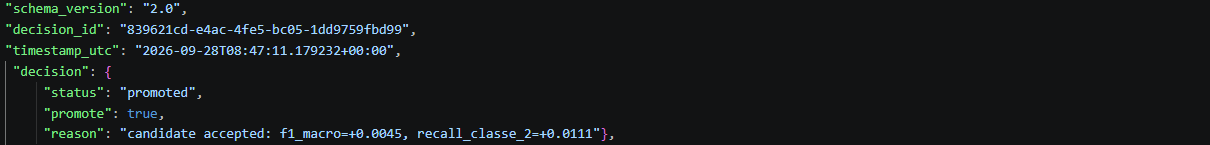

**candidate**       : model_name, model_version, model_type, artifact + artifact_sha256,
                  mlflow_experiment, mlflow_run_id, registry {name, alias, version, model_uri},
                  hyperparameters, training_rows, feedback_request_ids, feedbacks exclus

*extrait de reports/decisions_log.jsonl*
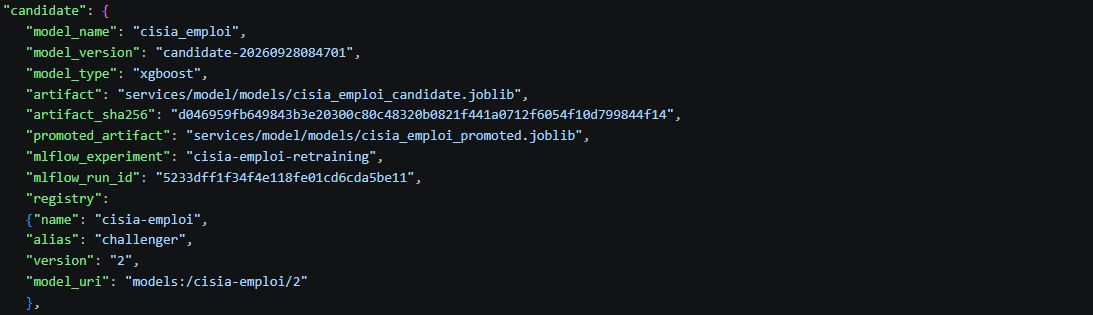

**production**      : model_name, model_version, scenario, config, artifact + artifact_sha256,
                  trained_on_dataset_sha256, mlflow_run_id, registry {name, alias, version}

*extrait de reports/decisions_log.jsonl*
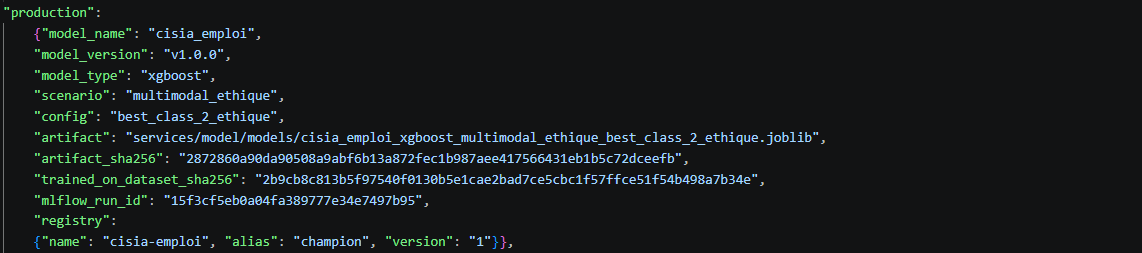

**data**            : reference_set + sha256, training_dataset + sha256, excluded_reference_rows

*extrait de reports/decisions_log.jsonl*
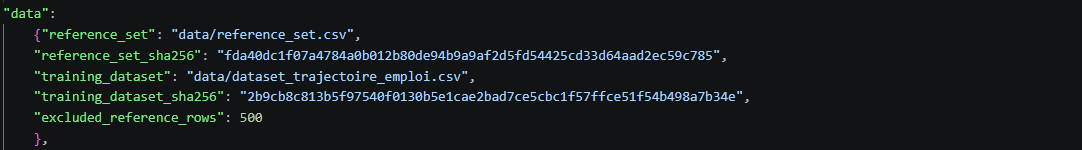

**metrics**         : candidate, production, delta_candidate_minus_production

*extrait de reports/decisions_log.jsonl*
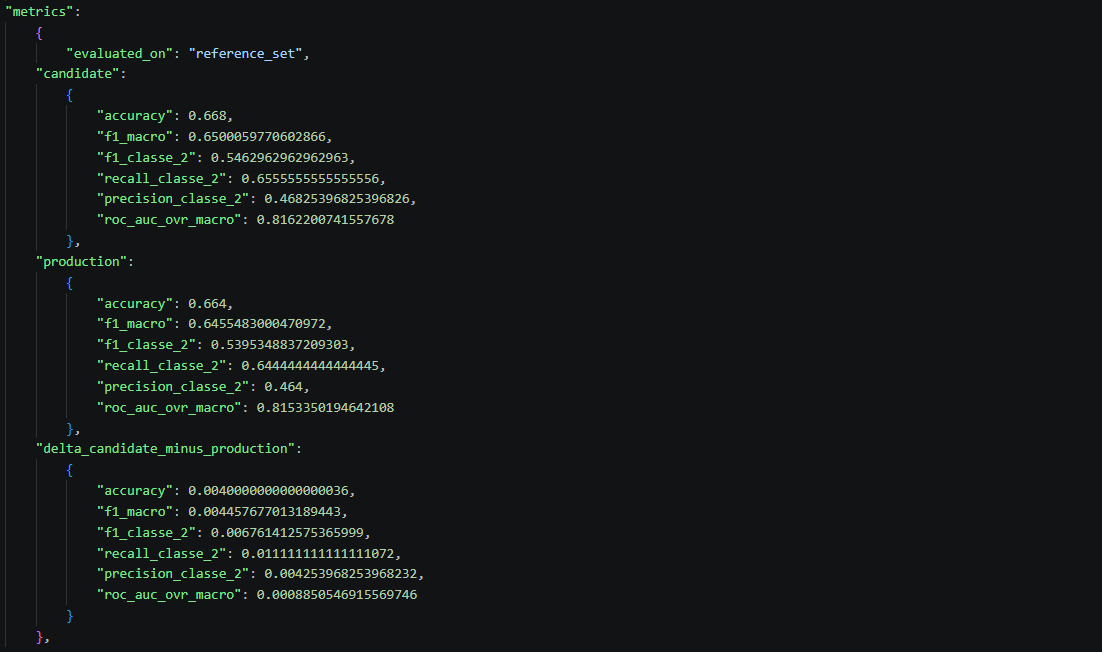
**quality_gate**    : status, passed, failed, rules[]  (rule, type, metric, value, comparison, threshold, status PASS/FAIL)

*extrait de reports/decisions_log.jsonl*
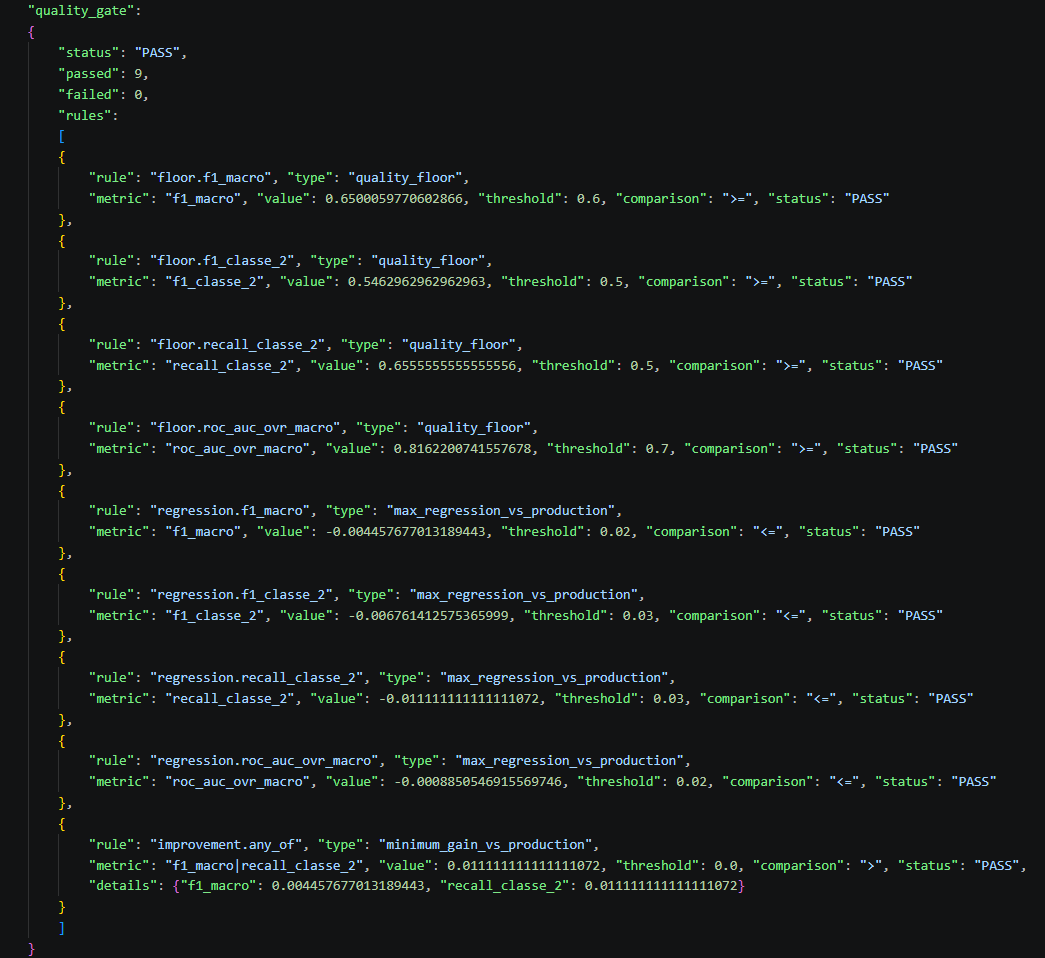

Ce journal permet de démontrer que la mise en production résulte d’une décision :
- mesurable ;
- explicable ;
- reproductible ;
- historisée ;
- auditable.

**Traçabilité MLflow**

L’interface MLflow est accessible à l’adresse suivante :

http://localhost:5000

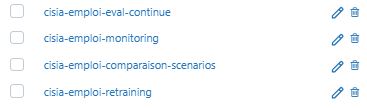


| Élément tracé | Expérience ou registre | Identifiant |
|---|---|---|
| Comparaison du modèle servi avec les autres scénarios | `cisia-emploi-comparaison-scenarios` | `0ea63cc417f84bb7ae4986387598263a` |
| Évaluation métier, calibration, équité et enregistrement du modèle | `cisia-emploi-monitoring` | `15f3cf5eb0a04fa389777e34e7497b95` |
| Modèle enregistré | `cisia-emploi`, version 1, alias `champion` | Lié au run `15f3cf5e…` |
| Quality gate nominal | `cisia-emploi-eval-continue` | `50baa55d…` |
| Quality gate dégradé et bloqué | `cisia-emploi-eval-continue` | `23629563…` |
| Dernier réentraînement et comparaison candidat contre production | `cisia-emploi-retraining` | `3c963de2631c4f3b870db7f2613848d6` |

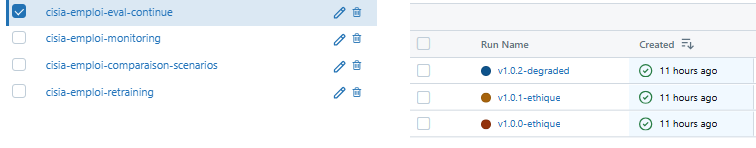
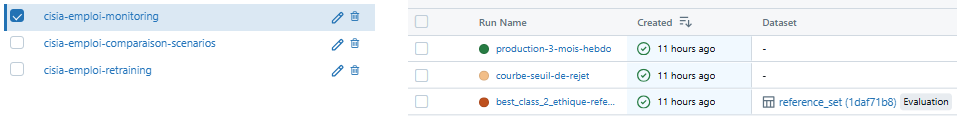
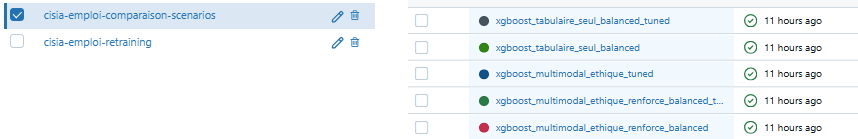
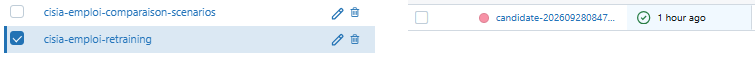

**Chaîne de traçabilité**

La chaîne de traçabilité peut être représentée de la manière suivante :

```text
Dataset identifié par son empreinte SHA-256
                    ↓
Indices du train, de la validation et du holdout conservés
                    ↓
Entraînement du pipeline complet
                    ↓
Paramètres, métriques et artefacts enregistrés dans MLflow
                    ↓
Création du modèle candidat
                    ↓
Comparaison avec le modèle de production
                    ↓
Application du quality gate
                    ↓
Décision enregistrée dans decisions_log.jsonl
                    ↓
Promotion éventuelle du candidat
                    ↓
Sélection de l’artefact par MODEL_ARTIFACT
                    ↓
Chargement du modèle par le service
                    ↓
Exposition de l’identité du modèle dans /info et Prometheus
                    ↓
Enregistrement des prédictions et des feedbacks
```

Cette chaîne permet de relier :
- les données d’entraînement ;
- le code et l’environnement ;
- le modèle entraîné ;
- les métriques obtenues ;
- la décision de promotion ;
- l’artefact déployé ;
- les prédictions produites en exploitation ;
- les feedbacks collectés après le déploiement.


**Observabilité du modèle servi**

L’observabilité permet de vérifier le fonctionnement du service et de suivre le comportement du modèle en exploitation.

L’endpoint `/info` et la métrique Prometheus `cisia_model_info` permettent d’identifier le modèle effectivement chargé.

Les métriques de surveillance peuvent être organisées selon plusieurs catégories.

**Surveillance du modèle**

| Type | Métrique | Seuil d’alerte | Source |
|---|---|---|---|
| Modèle | F1-score hebdomadaire | Inférieur à la baseline de plus de `0,05` | Logs de l’API |
| Données | PSI des variables clés | ≥ **0,25** : alerte ; **0,10–0,25** : à surveiller ; < 0,10 : stable | Batch journalier |
| Système | Latence p95 | Supérieure à `600 ms` | Prometheus |

D’autres métriques peuvent être suivies :

- taux de prédictions par classe ;
- rappel de la classe 2 ;
- nombre d’erreurs `2 → 0` ;
- taux d’erreurs `2 → 0` ;
- taux d’abstention ;
- accuracy sur les prédictions acceptées ;
- distribution de la probabilité maximale ;
- fréquence des corrections par les conseillers ;
- taux d’erreur du service ;
- volume de prédictions ;
- proportion de valeurs manquantes ;
- apparition de catégories inconnues.

**Synthèse**

Le dispositif mis en place couvre les principales dimensions d’une démarche MLOps :

- **reproductibilité**, grâce aux métadonnées, au hash du dataset et aux indices du holdout ;
- **traçabilité**, grâce aux runs MLflow, au registre et au journal des décisions ;
- **maîtrise du risque**, grâce au quality gate ;
- **séparation des responsabilités**, grâce aux statuts `candidate`, `promoted` et stable ;
- **réversibilité**, grâce à la sélection explicite de l’artefact avec `MODEL_ARTIFACT` ;
- **observabilité**, grâce à `/info`, à Prometheus et aux métriques de suivi ;
- **persistance**, grâce aux volumes Docker et au stockage sur l’hôte ;

Le principe central est qu’un modèle réentraîné n’est jamais automatiquement mis en production.

Il est d’abord :

1. identifié ;
2. évalué ;
3. comparé au modèle actuellement servi ;
4. soumis à un quality gate ;
5. promu uniquement si les critères sont respectés ;
6. sélectionné explicitement pour le déploiement ;
7. contrôlé après son chargement par le service ;
8. surveillé pendant son exploitation.

> **Message clé :** le système ne se limite pas à produire un modèle performant. Il permet également de savoir quel modèle est utilisé, comment il a été entraîné, sur quelles données il a été évalué, pourquoi il a été promu, comment il est surveillé et comment revenir à une version stable en cas de dégradation.

### 8.2 API de service

```mermaid
flowchart LR
    Conseiller["Conseiller"]
    Frontend["Frontend Nginx<br/>port 8088"]

    subgraph Backend["API Backend FastAPI — port 8001"]
        HealthB["GET /health"]
        Score["POST /score"]
        History["GET /history"]
        Feedback["POST /feedback"]
        FeedbackCount["GET /feedback/count"]
        TrainB["POST /train"]
        MetricsB["GET /metrics"]
        Drift["GET /drift-metrics"]
        Evaluation["GET /evaluation-metrics"]
        Retrain["GET /retrain-metrics"]
    end

    subgraph Model["API Model FastAPI — port 8000"]
        HealthM["GET /health"]
        Info["GET /info"]
        Predict["POST /predict"]
        TrainM["POST /train"]
        MetricsM["GET /metrics"]
    end

    DB[("SQLite<br/>prédictions et feedbacks")]
    Registry["Référentiel usagers<br/>optionnel"]
    Prometheus["Prometheus"]
    Grafana["Grafana"]

    Conseiller --> Frontend
    Frontend -->|"Prédiction"| Score
    Frontend -->|"Historique"| History
    Frontend -->|"Feedback"| Feedback

    Score -->|"Validation et appel interne"| Predict
    Predict -->|"Classe, probabilités, version"| Score
    Score -->|"Enregistrement"| DB
    History -->|"Lecture"| DB
    Feedback -->|"Enregistrement du résultat réel"| DB
    FeedbackCount -->|"Comptage des annotations"| DB

    Score -.->|"Vérification si configurée"| Registry
    TrainB -->|"Proxy contrôlé"| TrainM

    Prometheus -->|"Scrape"| MetricsB
    Prometheus -->|"Scrape"| Drift
    Prometheus -->|"Scrape"| Evaluation
    Prometheus -->|"Scrape"| Retrain
    Prometheus -->|"Scrape"| MetricsM
    Prometheus --> Grafana
```

Le navigateur appelle le frontend Nginx (port `8088`), qui transmet les requêtes `/api/*` au backend. Le backend appelle ensuite le service model en interne. Les deux services FastAPI exposent une documentation Swagger sur `/docs`. Les routes `/metrics` et `/drift-metrics` n'y apparaissent pas, car elles sont exclues du schéma OpenAPI.

| Route | Méthode | Service | Rôle | Validation / sécurité |
|---|---|---|---|---|
| `/health` | GET | model / backend | Vérifier la santé du service | Model : `503` si l'artefact n'est pas chargé. Backend : liveness seule, sans interroger le model |
| `/info` | GET | model | Retourner le nom, la version, le scénario, les métriques et la provenance du modèle | Lecture des métadonnées JSON de l'artefact chargé |
| `/predict` | POST | model | Effectuer une prédiction unitaire | Schéma Pydantic : diplôme parmi les valeurs autorisées, ancienneté ≥ 0. Réponse : classe 0, 1 ou 2 et trois probabilités. `500` si la prédiction échoue |
| `/score` | POST | backend | Orchestrer la requête du frontend vers le model et enregistrer la prédiction | Pydantic, propagation de `request_id`, `usager_id`, `session_id`. `503` si le model est injoignable, `502` si le model répond en erreur |
| `/history` | GET | backend | Consulter les inférences d'une session ou d'un usager, avec les entrées saisies et le feedback éventuel | Filtres `session_id` / `usager_id`, limite 1-200 |
| `/feedback` | POST | backend | Enregistrer le résultat réel observé par le conseiller | `request_id` connu (`404`), prédiction cohérente et pas d'annotation contradictoire (`409`), `true_label` entre 0 et 2 (`422`), rejeu identique idempotent |
| `/feedback/count` | GET | backend | Compter les feedbacks, au total et non encore consommés, pour déclencher le retraining | Lecture SQLite |
| `/train` | POST | model / backend | Réentraînement contrôlé, pour les tests ou un environnement autorisé | Model : Pydantic, token `X-Train-Token` (`403` si invalide et `TRAIN_API_TOKEN` défini), `ALLOW_DIRECT_TRAIN=false` par défaut (`409`). Backend : proxy qui transmet le token, et renvoie `503` si le model est injoignable ou `502` si le model est en erreur |
| `/metrics` | GET | model / backend | Exposer les métriques Prometheus | Format Prometheus, hors Swagger |
| `/drift-metrics` | GET | backend | Publier le dernier rapport de drift batch | Format Prometheus, fichier défini par `DRIFT_METRICS_FILE` (par défaut `/app/reports/drift.prom`), hors Swagger |

Les erreurs:
| Code | Description | Routes / cas |
|---|---|---|
| **403 Forbidden** | Jeton d’entraînement absent ou invalide lorsque l’authentification est configurée. | Modèle : `POST /train` |
| **404 Not Found** | Le `request_id` transmis ne correspond à aucune prédiction enregistrée. | Backend : `POST /feedback` |
| **409 Conflict** | Entraînement direct désactivé, ou feedback déjà enregistré avec une étiquette différente. | Modèle : `POST /train`; backend : `POST /feedback` |
| **422 Unprocessable Entity** | Corps ou paramètres invalides : ancienneté négative, diplôme hors liste, `usager_id` vide, `true_label` hors de `[0, 2]`, `limit` hors de `[1, 200]`, ou moins de 10 dossiers pour un entraînement. | Modèle : `POST /predict`, `POST /train`; backend : `POST /score`, `POST /feedback`, `POST /train`, `GET /history` |
| **500 Internal Server Error** | Échec interne pendant la prédiction ou pendant l’entraînement du modèle. | Modèle : `POST /predict`, `POST /train` |
| **502 Bad Gateway** | Le backend ne peut pas exploiter la réponse du modèle : celui-ci répond en erreur, renvoie un JSON invalide ou une réponse incompatible avec le schéma attendu. | Backend : `POST /score`, `POST /train` |
| **503 Service Unavailable** | Dépendance indisponible : modèle non chargé ou inaccessible, ou référentiel usagers indisponible / usager inconnu. | Modèle : `GET /health`; backend : `POST /score`, `POST /train` |

Aucun `400 Bad Request` n’est explicitement renvoyé par ces routes : les entrées rejetées par la validation Pydantic renvoient `422`.

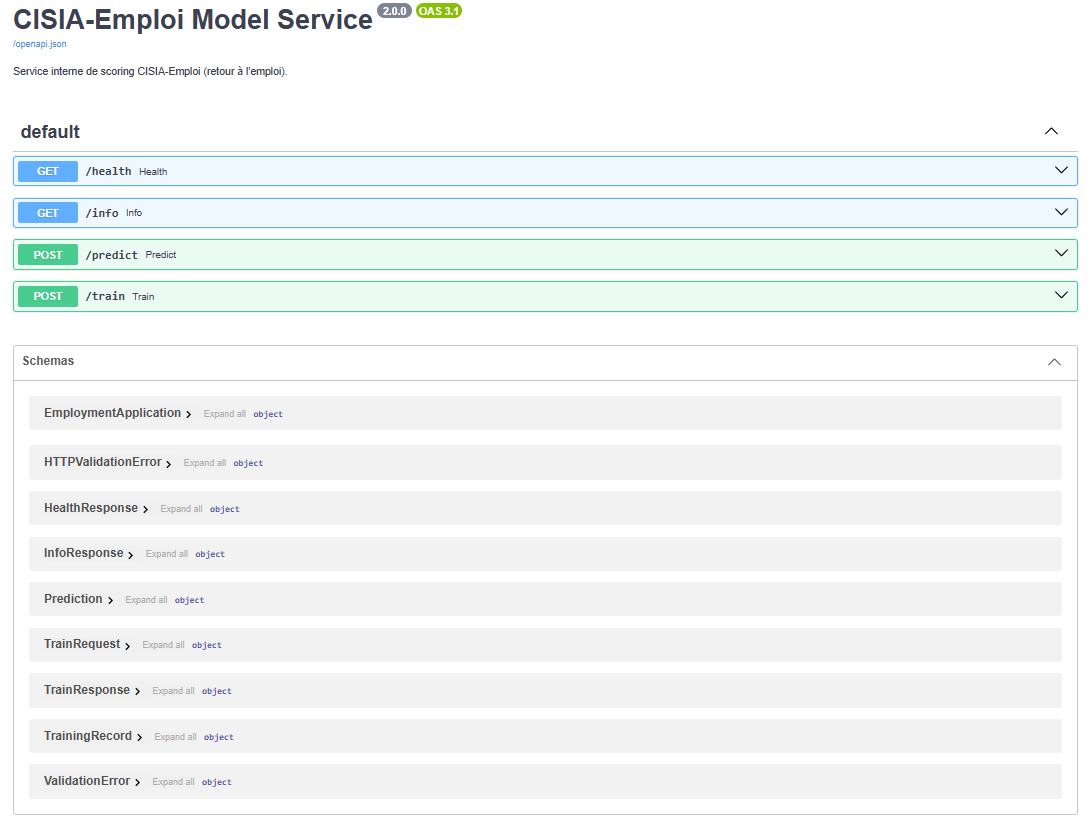

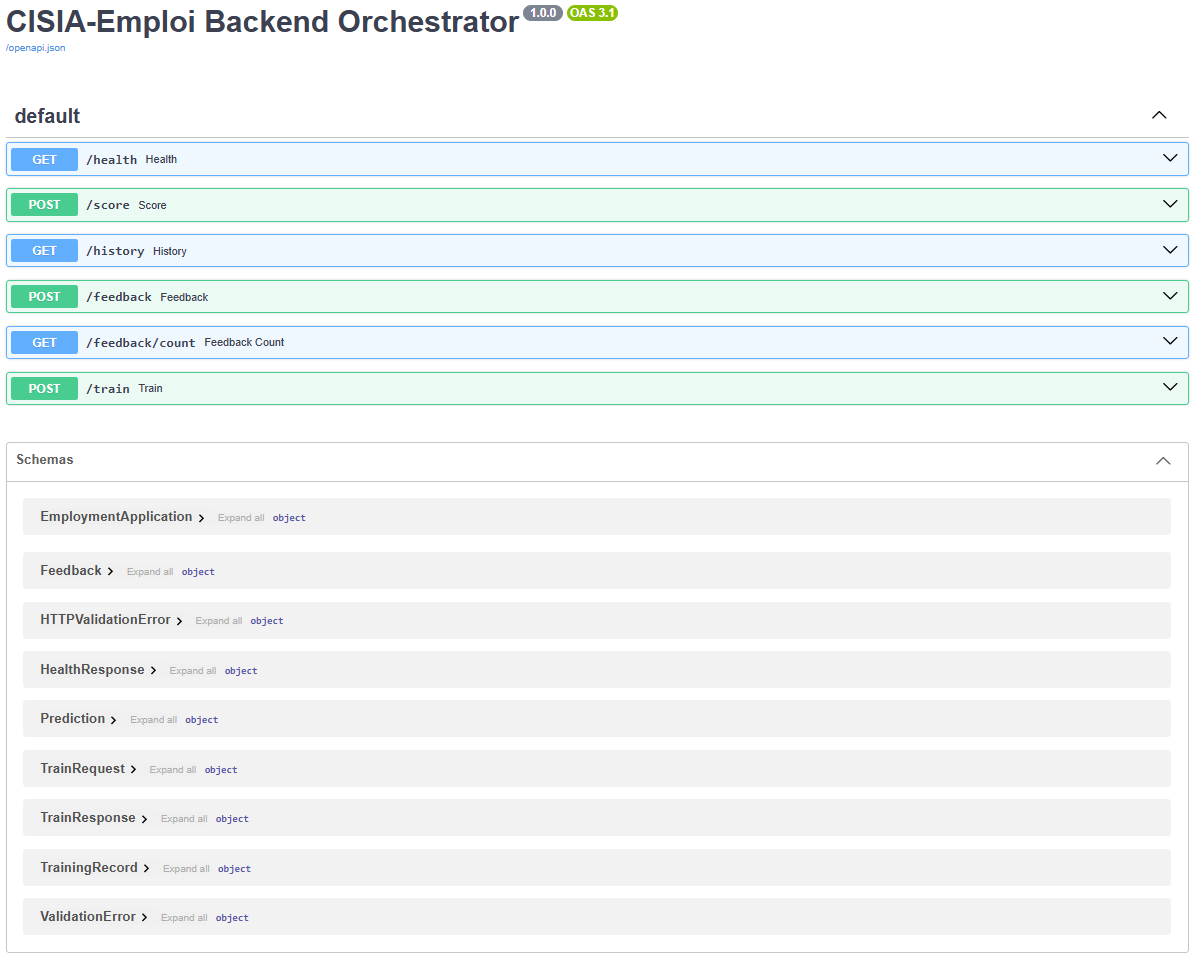

**Journalisation et traçabilité**

Les services backend et modèle utilisent Loguru pour journaliser chaque requête : méthode HTTP, route, code de réponse, durée de traitement et identifiant de corrélation (request_id). Le backend transmet cet identifiant au service modèle, ce qui permet de suivre une requête d'un service à l'autre et de diagnostiquer les erreurs.

Les journaux sont consultables avec docker compose logs. Le service modèle écrit en plus dans un fichier JSON (/app/logs/api.log dans le conteneur), avec une rotation à 10 Mo et une conservation de 7 jours.

Loguru assure la traçabilité opérationnelle, mais il ne constitue pas à lui seul une piste d'audit inviolable : les fichiers restent modifiables, et les journaux sont supprimés après 7 jours. La traçabilité des décisions repose sur d'autres éléments : l'historique des prédictions et des feedbacks, enregistré en base SQLite et relié par le request_id, ainsi que le journal des promotions de modèles (decisions_log.jsonl).

Un usage en production exigerait en plus un stockage des journaux en écriture seule (ou un envoi vers un système centralisé) et une durée de conservation définie avec le service juridique.

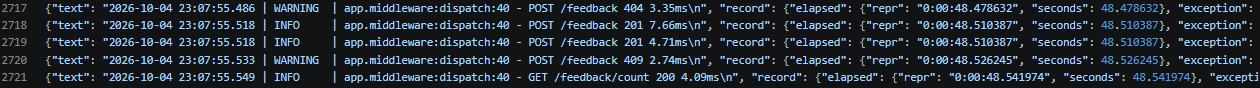

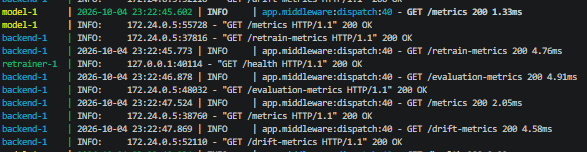

### 8.3 Interface utilisateur

Cette page est un formulaire intitulé « Orientation vers le retour à l'emploi », destiné à évaluer le délai probable de retour à l'emploi d'un usager.
L'interface HTML permet au conseiller de renseigner l'identifiant usager, les variables de situation ainsi que la synthèse d'entretien, puis d'appuyer sur le bouton « Évaluer le retour à l'emploi ». 
Un message affiche alors la classe prédite, les probabilités, la version du modèle et le REQ-ID

**Choix de conception**

- Pas d'écriture automatique dans le référentiel : le résultat de l'IA est une aide à la décision. Seule la décision du conseiller est enregistrée par le guichet unique (supervision humaine effective, AI Act, système à haut risque).
- Minimisation : le service ne reçoit que les variables utilisées par le modèle S2. `age` et `nationalite_hors_ue` ne sont ni transmis ni stockés.
- L'identifiant usager est un pseudonyme opaque, la table de correspondance restant dans le référentiel.
- L’escalade vers la classe 2 (p ≥ seuil) peut être activée de manière optionnelle afin de renforcer la sécurité du dispositif. Dans notre cas, une revue humaine est déclenchée lorsque la probabilité de la classe 2 est supérieure ou égale à 4 %.


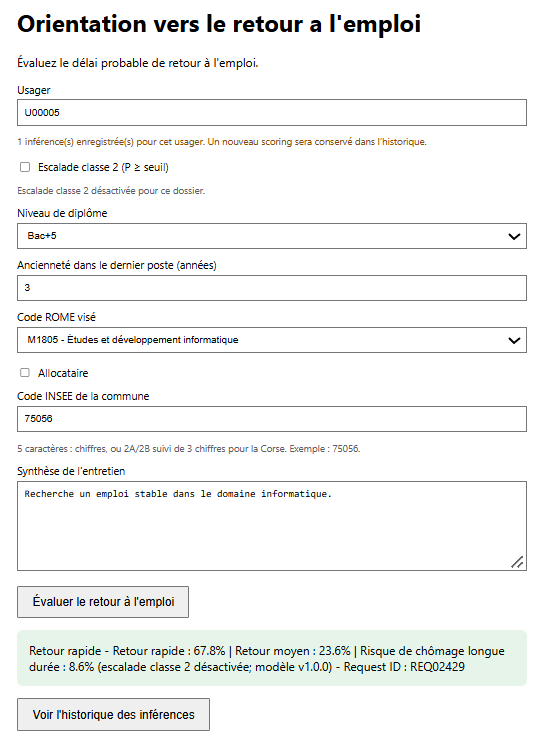

Après chaque scoring, l'interface recharge l'historique de la session avec `GET /api/history?session_id=...`.

Après avoir cliqué sur « Évaluer le retour à l’emploi », le conseiller visualise les probabilités de prédiction associées à chaque classe. Le système signale, le cas échéant, la nécessité d’une revue humaine conformément aux seuils définis au § 7.2

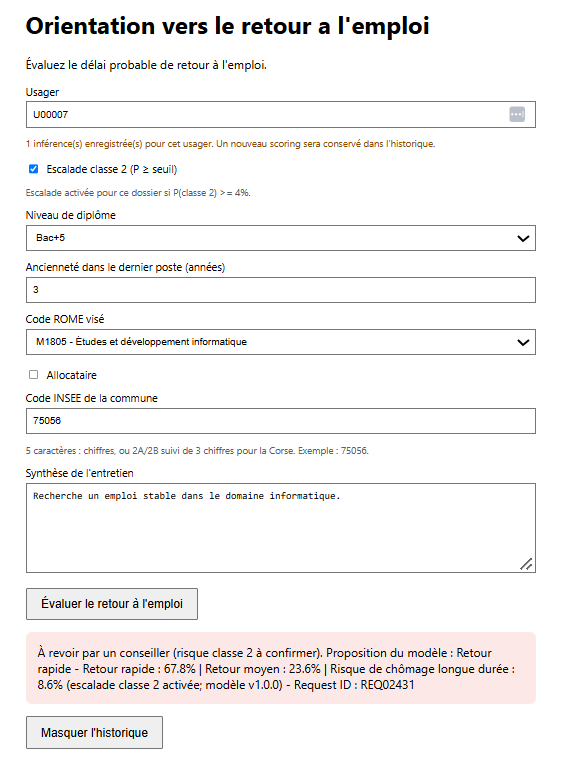

Sur la même page, le conseiller peut consulter l'historique horodaté de sa session ou de toutes les sessions.

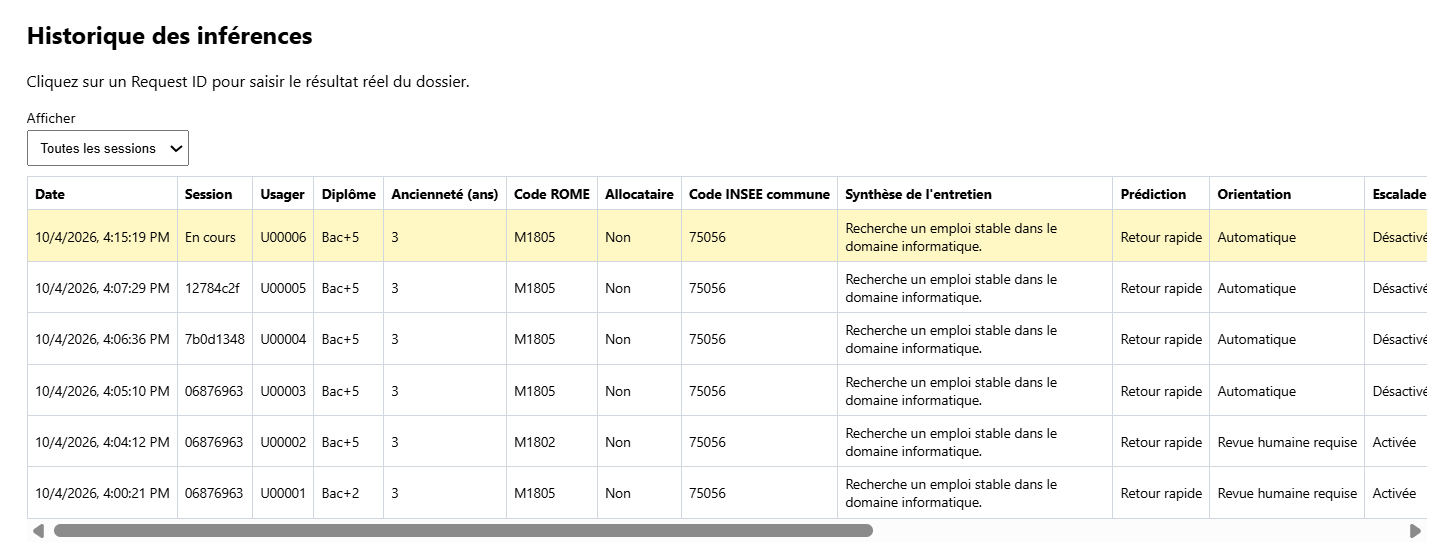

Il pourra aussi, en cliquant sur le REQ-ID dans l'historique, enregistrer le résultat réel et un commentaire via /api/feedback. Une fenêtre pop-up apparaîtra alors, permettant de renseigner le feedback du conseiller.
    
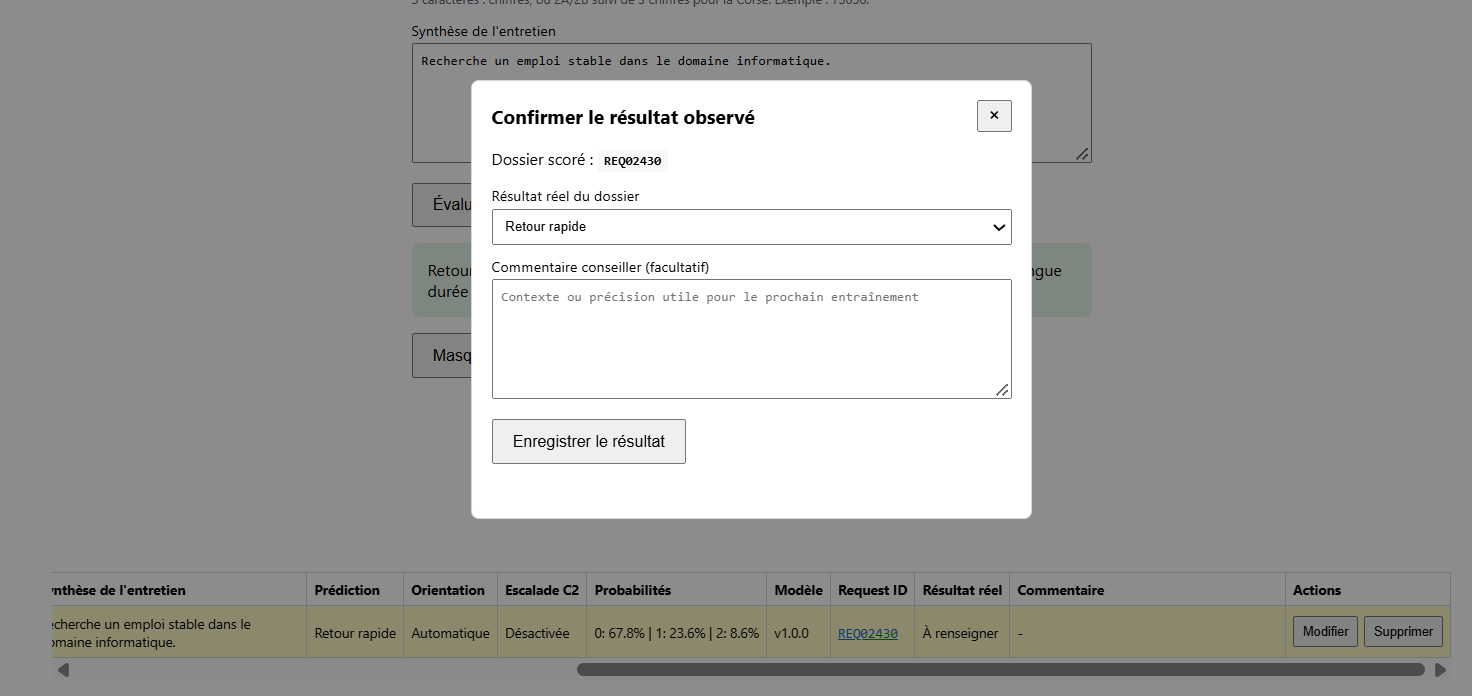

### 8.4 Schéma d'architecture

```mermaid
flowchart LR
    Donnees["Données tabulaires et textuelles"]
    Preprocessing["Préprocessing<br/>encodage · TF-IDF"]
    Entrainement["Entraînement et évaluation"]
    Artefact["Artefact du pipeline<br/>préprocessing + modèle"]

    Conseiller["Conseiller"]
    UI["Frontend Nginx"]
    Backend["API backend<br/>POST /score"]
    Modele["API modèle<br/>POST /predict"]
    DB[("SQLite<br/>prédictions et feedbacks")]
    Monitoring["Prometheus → Grafana"]

    Donnees --> Preprocessing --> Entrainement --> Artefact
    Artefact -->|"chargé au démarrage"| Modele

    Conseiller --> UI
    UI -->|"demande de prédiction"| Backend
    Backend -->|"appel interne"| Modele
    Modele -->|"classe et probabilités"| Backend
    Backend -->|"résultat"| UI

    Backend -->|"enregistre la prédiction"| DB
    UI -->|"feedback"| Backend
    Backend -->|"enregistre le feedback"| DB

    Backend -.->|"métriques"| Monitoring
    Modele -.->|"/metrics"| Monitoring
```

### 8.5 Conteneurisation & CI/CD


**Pipeline complet réussi : lint, tests, entraînement, déploiement**

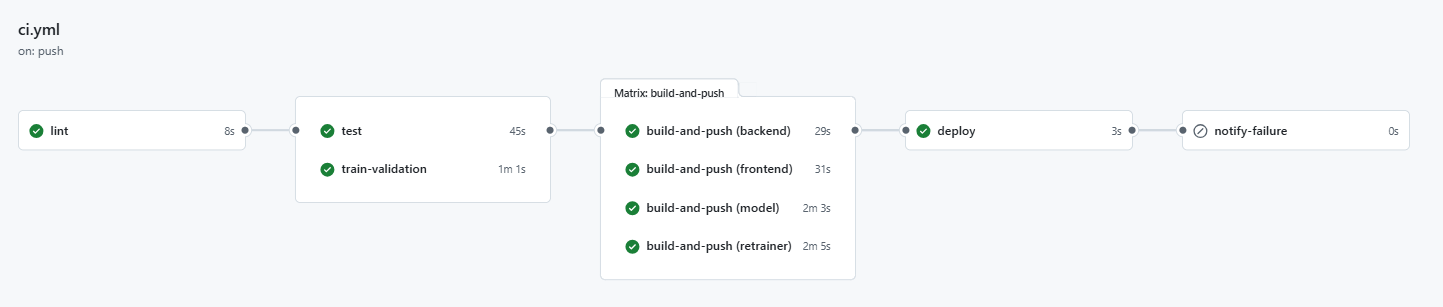

**Tester un échec de modèle dégradé, avec notification via un canal Discord (Quality Gate)**

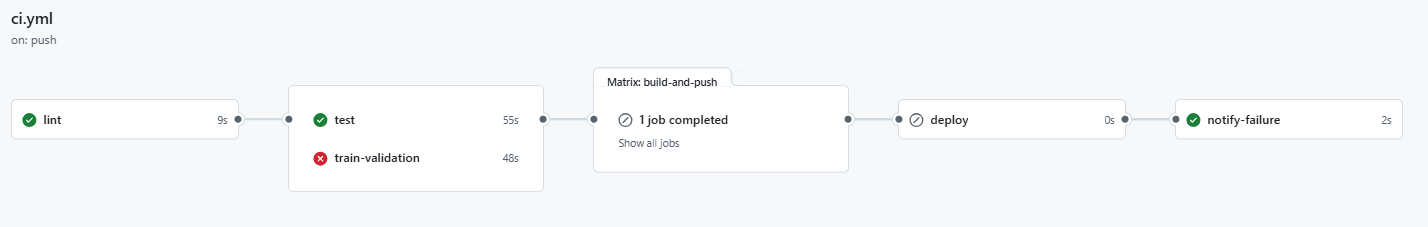

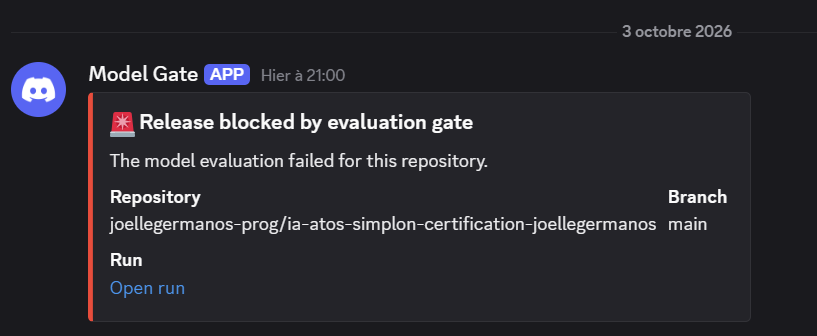

lien vers le run github: https://github.com/joellegermanos-prog/ia-atos-simplon-certification-joellegermanos/actions/runs/37146220755

>*Alertes en production : le webhook Discord couvre les échecs CI. Il ne constitue pas à lui seul une alerte sur les incidents runtime ou les seuils de drift; ces alertes et leur prise en charge restent à préciser.*

## Workflow GitHub Actions

### Déclencheurs (`on:`)

- **`workflow_dispatch`** : lancement manuel.
- **`push` vers `main`** : exécute le workflow pour valider, construire, publier et éventuellement déployer.
- **`push` d’un tag `v*`** : exécute le workflow, valide le modèle et publie les images, sans déploiement.
- **`pull_request` vers `main`** : exécute les validations et construit les images sans les publier.

### Chaîne des jobs

**1. `lint`**  
Installe Ruff et vérifie le code dans `services`, `scripts` et `tests`.

**2. `test`**, après `lint`  
Installe les dépendances du modèle et du backend, puis exécute une sélection ciblée de tests :

- API modèle : santé, prédiction valide, validation d’une entrée invalide, erreur d’entraînement et endpoint `/metrics` ;
- API backend : appel de prédiction `/score` et validation du nombre minimal d’enregistrements pour l’entraînement.

**3. `train-validation`**, après `lint` et en parallèle de `test`  
Installe les dépendances d’entraînement et d’évaluation, puis exécute dans l’ordre :

1. les tests d’entraînement : nombre minimal d’enregistrements, token invalide et création d’un run MLflow ;
2. le test de contrat du modèle ;
3. les tests d’évaluation ;
4. le quality gate avec `scripts/evaluate_model.py --release-tag`.

Le résultat est capturé dans `evaluation-result.json`. `set -o pipefail` garantit qu’un échec de l’évaluation n’est pas masqué par `tee`. Le résultat est ensuite publié dans `GITHUB_STEP_SUMMARY`, même si l’évaluation échoue (`if: always()`).

**4. `build-and-push`**, après la réussite de `test` et de `train-validation`  
Un job matriciel (`fail-fast: false`) construit **quatre images** : `model`, `backend`, `frontend` et `retrainer`.

Pour chaque image, il :

- construit le nom en minuscules sous la forme `ghcr.io/<repo>/<service>` ;
- se connecte à GHCR uniquement pour un événement `push` vers `main` ou un tag `v*` ;
- génère les tags SHA, branche, tag et `latest` selon les conditions configurées ;
- construit l’image sur tous les événements ; ne la publie que pour un push vers `main` ou un tag `v*`.

Ainsi, sur une pull request ou un lancement manuel, les images sont construites mais ne sont pas publiées.

**5. `deploy`**, après `build-and-push` et uniquement sur un push vers `main`  
Se connecte au serveur cible par SSH avec `appleboy/ssh-action`, s’authentifie auprès de GHCR, récupère les images correspondant au SHA du commit, puis recrée les conteneurs `model`, `backend` et `frontend` avec `docker compose up -d --no-build --force-recreate`. Il affiche ensuite leur état avec `docker compose ps`.

Le job `deploy` est déclenché sur un push vers `main`, mais son étape SSH est ignorée si `DEPLOY_HOST` n’est pas configuré. Le service `retrainer` est construit et publié par la matrice, mais n’est pas redémarré par cette étape de déploiement.

**6. `notify-failure`**, après les cinq jobs précédents  
Le job attend la fin de `lint`, `test`, `train-validation`, `build-and-push` et `deploy`. Avec `always()`, il peut examiner leurs résultats même si l’un d’eux a échoué; il ne poursuit toutefois que si au moins l’un de ces cinq jobs est en échec.

Il valide la présence et le format de `DISCORD_WEBHOOK_URL`, puis envoie une alerte Discord rouge contenant le dépôt, la branche et le lien vers l’exécution du workflow.

### 8.6 📝 Synthèse industrialisation

**Pile technique retenue**

| Composant | Choix | Rôle |
|---|---|---|
| Interface conseiller | Nginx, exposé sur `localhost:8088` | Sert l’interface statique et relaie les appels `/api/` vers le backend. |
| Backend | FastAPI, port `8001` | Orchestre le scoring; gère `/score`, `/feedback`, `/feedback/count`, `/history`, `/health`, `/metrics` et `/drift-metrics`. |
| Service modèle | FastAPI, port `8000` | Charge le modèle et ses métadonnées au démarrage; expose `/predict`, `/train`, `/health`, `/info` et `/metrics`. |
| Validation des entrées | Pydantic | Valide les requêtes côté API. Les schémas des deux services doivent rester cohérents et sont contrôlés par les tests de contrat. |
| Préparation des données | Fonctions du module de prétraitement du modèle | `create_features()` et le préprocesseur sont utilisés par l’inférence et les scripts d’entraînement pour limiter les écarts entre ces étapes. |
| Modèle | XGBoost multiclasses | Produit une classe parmi `0`, `1` et `2`, avec les probabilités associées. Le service charge un artefact `.joblib` accompagné de ses métadonnées JSON. |
| Historique et feedbacks | SQLite, volume Docker persistant | Conserve les prédictions et les retours conseillers, liés par un `request_id`. |
| Suivi des expériences | MLflow | Trace les runs, paramètres, métriques et artefacts; son registre de modèles suit notamment les candidats. |
| Registre d’images | GitHub Container Registry (GHCR) | Stocke les images Docker `model`, `backend` et `frontend`. À distinguer du registre de modèles MLflow. |
| CI/CD | GitHub Actions | Exécute Ruff, les tests ciblés, le test de contrat et l’évaluation qualité, puis construit les images en matrice. Les images sont publiées sur GHCR sur `main` ou lors d’un tag `v*`; le déploiement distant concerne `main` si les secrets sont configurés. |
| Monitoring | Prometheus et Grafana | Prometheus collecte les métriques du backend et du modèle; Grafana les visualise. Le drift est calculé par batch puis exposé au format Prometheus (§9.) |


**Choix d’architecture**

- **Séparation des responsabilités** : le navigateur appelle le backend via le reverse proxy Nginx. Le backend orchestre la requête et appelle le service modèle par HTTP; il ne charge pas directement le pipeline XGBoost.
- **Validation et prétraitement cohérents** : Pydantic contrôle le format des entrées. Les transformations métier sont centralisées dans le prétraitement du modèle et réutilisées dans les parcours d’inférence et d’entraînement.
- **Traçabilité des prédictions** : le backend enregistre la prédiction, les probabilités, la version du modèle et les informations nécessaires à l’historique. Le feedback est rattaché au `request_id`; une annotation inconnue ou contradictoire est rejetée.
- **Promotion contrôlée** : le réentraînement crée un candidat distinct du modèle servi. Il est comparé au modèle de production sur un jeu de référence figé; la promotion produit un artefact, mais son activation dans l’API modèle reste une étape de déploiement.
- **Barrière qualité dans la CI** : les tests et le quality gate d’évaluation doivent réussir avant la construction des images. Une dégradation au regard des seuils bloque la suite de la chaîne.
- **Publication conditionnelle** : la matrice construit une image par service. Les pull requests vérifient le build sans publier; les pushes admissibles publient les images sur GHCR. Le déploiement on-prem est conditionné à la configuration des secrets requis.(choix d'hébergement argumenté en §8.0)
- **Observabilité séparée du contrôle de disponibilité** : `/health` et les healthchecks Docker vérifient l’état des services. Prometheus collecte les métriques opérationnelles et métier; Grafana les présente. L’analyse de drift est batch et dépend de la génération du rapport correspondant.

## 9. Suivi en production & amélioration continue

### 9.1 Métriques à surveiller


Le tableau suit une progression :

préventive → détective → opérationnelle :

- **Release :** empêcher un mauvais modèle d'entrer en production.
- **Risque métier :** surveiller l'impact réel, directement lié à la performance du modèle et la priorité de la classe 2.
- **Dérives :** signaux précoces (sans labels) puis confirmation (avec labels).
- **Système :** garantir que le service fonctionne, indépendamment du modèle.

| Axe | Métrique et fenêtre | Seuil d’alerte | Source / état | Action |
|------|--------------------|----------------|---------------|--------|
| **Gate de release – qualité globale** | F1 macro sur le jeu de référence gelé, comparé au golden run | Échec si `F1 < 0,60` **ou** si la baisse dépasse `0,04` | `scripts/evaluate_model.py`, MLflow et statut PASS/FAIL Grafana • **En place** | Bloquer la release si le seuil est franchi |
| **Gate de release – risque classe 2** | F1 et recall de la classe 2 sur le même jeu de référence | F1 `< 0,50` ou baisse `> 0,05` ; recall `< 0,59` ou baisse `> 0,06` | `scripts/evaluate_model.py` et golden run • **En place** | Bloquer la release si l’un des seuils échoue |
| **Gate de release – discrimination** | ROC AUC OVR macro sur le jeu de référence | `< 0,70` ou baisse `> 0,04` par rapport au golden run | `scripts/evaluate_model.py` et MLflow • **En place** | Bloquer la release |
| **Risque métier – erreur critique 2→0** | Dossiers réellement classe 2 prédits classe 0, sur feedbacks confirmés et labels mûrs ; revue hebdomadaire | `> 8,5 %` (seuil métier retenu en §7.2) | Table `feedback`, calcul batch • **À automatiser** | Alerter et analyser les cas ; ne pas attendre la prochaine gate |
| **Fausses alertes 0→2** | Dossiers réellement classe 0 prédits classe 2 ; comparaison avec le modèle validé | Hausse relative `> 25 %` | Table `feedback`, calcul batch • **À automatiser** | Vérifier l’impact opérationnel et la charge de revue |
| **Abstention / escalade** | Dossiers orientés en revue humaine ÷ dossiers scorés, sur fenêtre glissante de quatre semaines (affichage Grafana sur fenêtre courte) | Écart relatif > **20 %** par rapport au taux de référence du mode actif (référence : 30,4 % en mode par défaut, soit une plage de 24 % à 37 % ; 41,6 % en mode renforcé, soit une plage de 33 % à 50 %), avec un volume suffisant | Compteur `backend_abstentions_total` et `/metrics` • **Compteur en place ; règle d'alerte à configurer** | Taux trop bas : vérifier que le seuil est bien appliqué et que le modèle chargé est le bon. Taux trop élevé : vérifier une dérive des données ou une surcharge des revues humaines. Ne pas modifier le seuil automatiquement |
| **Dérive des entrées – Data Drift** | PSI entre référence et fenêtre courante | `< 0,10` stable ; `0,10–0,25` à surveiller ;`≥ 0,25` forte | `scripts/drift_analysis.py`, rapport batch `/drift-metrics` • **À automatiser**. | Investiguer la période, la qualité et la population avant toute action sur le modèle |
| **Dérive des classes – Label Shift** | Distribution des **labels réels confirmés** comparée à la référence via un test χ² sur fenêtre glissante | `p < 0,05` avec effectif suffisant | Table `feedback`, calcul batch mensuel • **À automatiser** | Examiner l’évolution de la population ; ce signal seul ne prouve pas un concept drift |
| **Concept Drift** | F1 macro, recall classe 2 et erreur critique 2→0 sur labels confirmés, comparés à la période de référence | Baisse de F1 macro `> 0,03` à investiguer | Feedbacks confirmés, calcul batch • **À automatiser** ; politique définie dans `src/recommendations.py` | Procédure `src/recommendations.py` |
| **Système – latence** | p95 des requêtes de prédiction sur 5 minutes | `> 600 ms` | Prometheus `/metrics` • **Mesuré** | Alerter l’équipe si le dépassement persiste |
| **Système – erreurs serveur** | Réponses 5xx ÷ réponses totales sur une heure glissante | `> 1 %` | Compteurs HTTP Prometheus `/metrics` • **Mesuré** | Investiguer le service concerné et les erreurs upstream |

**Mesure latence**

In [63]:
import asyncio
import math
import statistics
import time
import uuid
from collections import Counter

import httpx

URL = "http://localhost:8088/api/score"
PAYLOAD = {
    "niveau_diplome": "Bac+2",
    "anciennete_poste_ans": 3.0,
    "code_rome_vise": "M1805",
    "est_allocataire": 1,
    "code_insee_commune": "75056",
    "synthese_entretien": "Recherche un emploi stable dans le domaine informatique.",
}
RUN_ID = uuid.uuid4().hex[:8]
TAUX_SUCCES_MIN = 0.99


def percentile(sorted_values, quantile):
    index = math.ceil(quantile * len(sorted_values)) - 1
    return sorted_values[max(0, index)]


async def un_appel(client, index, code):
    # session_id strictement ASCII : lettres, chiffres et tirets uniquement
    payload = {**PAYLOAD, "session_id": f"latency-test-{RUN_ID}-{code}-{index:04d}"}
    debut = time.perf_counter()
    try:
        response = await client.post(URL, json=payload)
        statut, erreur = response.status_code, None
    except httpx.HTTPError as exc:
        statut, erreur = None, type(exc).__name__
    return (time.perf_counter() - debut) * 1000, statut, erreur


async def scenario(nom, code, n, concurrence=None, cadence=None, warmup=20):
    """Mode fermé si `concurrence` est donnée ; mode ouvert (req/s) si `cadence` est donnée.
    `code` : identifiant court ASCII (s1, s2...) utilisé dans le session_id."""
    limits = httpx.Limits(max_connections=max(concurrence or 1, 50))
    async with httpx.AsyncClient(timeout=httpx.Timeout(20.0), limits=limits) as client:
        for i in range(warmup):                       # échauffement exclu des statistiques
            await un_appel(client, i, f"{code}w")

        debut = time.perf_counter()
        if concurrence:
            semaphore = asyncio.Semaphore(concurrence)

            async def borne(i):
                async with semaphore:
                    return await un_appel(client, i, code)

            resultats = await asyncio.gather(*(borne(i) for i in range(n)))
        else:
            taches = []
            for i in range(n):
                await asyncio.sleep(max(0, debut + i / cadence - time.perf_counter()))
                taches.append(asyncio.create_task(un_appel(client, i, code)))
            resultats = await asyncio.gather(*taches)
        duree = time.perf_counter() - debut

    lat = sorted(d for d, s, _ in resultats if s == 200)
    statuts = Counter(str(s) if s is not None else f"Erreur {e}" for _, s, e in resultats)
    print(f"\n=== {nom} ===")
    print(f"Réussies : {len(lat)}/{n} | statuts : {dict(statuts)}")

    # Garde-fou : un scénario en échec ne doit jamais s'afficher comme un résultat
    taux = len(lat) / n
    assert taux >= TAUX_SUCCES_MIN, (
        f"Test invalide ({nom}) : {len(lat)}/{n} réussies, statuts {dict(statuts)}"
    )

    print(f"moyenne = {statistics.mean(lat):.1f} ms | p50 = {statistics.median(lat):.1f} ms | "
          f"p95 = {percentile(lat, 0.95):.1f} ms | p99 = {percentile(lat, 0.99):.1f} ms | "
          f"max = {lat[-1]:.1f} ms")
    print(f"Durée = {duree:.1f} s | débit = {n / duree:.1f} req/s")


async def main():
    await scenario("1. Utilisateur seul (concurrence 1)", "s1", n=100, concurrence=1)
    await scenario("2. Trafic réaliste (1 req/s)", "s2", n=60, cadence=1.0)
    await scenario("3. Saturation (concurrence 5)", "s3", n=300, concurrence=5)
    await scenario("4. Saturation forte (concurrence 10)", "s4", n=300, concurrence=10)


await main()   # dans un notebook ; dans un script : asyncio.run(main())


=== 1. Utilisateur seul (concurrence 1) ===
Réussies : 100/100 | statuts : {'200': 100}
moyenne = 88.1 ms | p50 = 81.3 ms | p95 = 130.0 ms | p99 = 177.0 ms | max = 294.9 ms
Durée = 8.8 s | débit = 11.3 req/s

=== 2. Trafic réaliste (1 req/s) ===
Réussies : 60/60 | statuts : {'200': 60}
moyenne = 66.6 ms | p50 = 63.9 ms | p95 = 89.6 ms | p99 = 156.6 ms | max = 156.6 ms
Durée = 59.1 s | débit = 1.0 req/s

=== 3. Saturation (concurrence 5) ===
Réussies : 300/300 | statuts : {'200': 300}
moyenne = 362.5 ms | p50 = 312.6 ms | p95 = 724.9 ms | p99 = 929.6 ms | max = 997.9 ms
Durée = 21.9 s | débit = 13.7 req/s

=== 4. Saturation forte (concurrence 10) ===
Réussies : 300/300 | statuts : {'200': 300}
moyenne = 701.8 ms | p50 = 678.1 ms | p95 = 974.7 ms | p99 = 1040.7 ms | max = 1163.7 ms
Durée = 21.2 s | débit = 14.1 req/s


**Test de charge sur le service de scoring (via Nginx, 20 requêtes de warm-up exclues, réponses 200 uniquement).**

Utilisateur seul : p95 = 110 ms. Trafic réaliste (1 req/s, 60 requêtes) : p95 = 129 ms. À 5 requêtes simultanées : p95 = 495 ms, soit à la limite de l'objectif (< 600 ms) ; ce résultat est marginal et à confirmer par des mesures répétées. À 10 requêtes simultanées : p95 = 1 076 ms, le service sature (débit plafonné à environ 12–14 req/s, latence croissante avec la concurrence). 
Le trafic attendu du site actuel de conseillers est très inférieur à cette charge, mais le passage à l'échelle (workers supplémentaires, réplication) devra être traité avant un déploiement large.

**⚠️ MODE DÉMONSTRATION :**
Les données affichées sur ce tableau de bord Grafana proviennent d'une simulation de test générée artificiellement pour valider le fonctionnement et le comportement des graphiques, ainsi que des seuils MLOps et la bonne lecture des données.

**Infrastructure & Performance Technique**
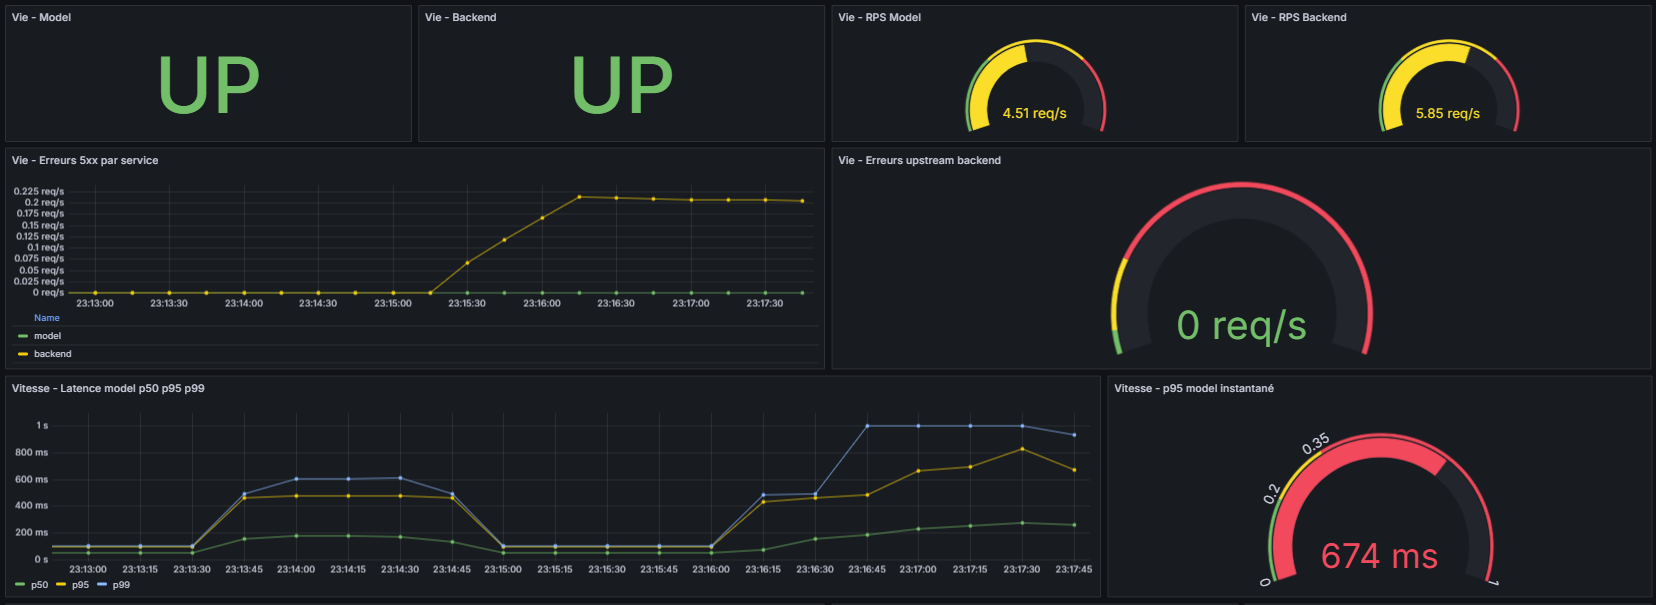

1. **Vie – Model / Backend** : `UP`  
   Prometheus parvient à joindre les endpoints de santé du modèle et du backend, ce qui confirme que les deux services sont opérationnels.

2. **Vie – RPS Model / Backend**  
   Nombre de requêtes HTTP par seconde observées :

   - **Modèle :** `0,364 req/s`
   - **Backend :** `1,04 req/s`

   Ces compteurs incluent les appels applicatifs mais également les requêtes de monitoring et de vérification d’état (health checks).

3. **Vie – Erreurs 5xx par service**  
   Mesure du taux d’erreurs serveur pour le modèle et le backend.

   - **Valeur observée :** `0 req/s`
   - **Interprétation :** aucune erreur HTTP 5xx n’a été détectée sur la période mesurée.

4. **Vie – Erreurs upstream backend**  
   Cet indicateur mesure les erreurs rencontrées lorsque le backend communique avec le modèle.

   - **Valeur observée :** `0 req/s`
   - **Interprétation :** aucun échec d’appel entre le backend et le modèle n’a été enregistré.

5. **Vitesse – Latence modèle (p50 / p95 / p99)**  
   Mesure des temps de réponse du modèle :

   - **p50 (médiane) :** `50 ms`
   - **p95 :** `95 ms`
   - **p99 :** `99 ms`

   Le percentile **p95 à 95 ms** signifie que 95 % des requêtes traitées ont obtenu une réponse en **95 ms ou moins**.

6. **Vitesse – p95 modèle instantané**  
   Indicateur du percentile p95 le plus récent.

   - **Valeur observée :** `95 ms`
   - **Statut :** dans la zone verte définie par le seuil de latence du tableau de bord, indiquant un niveau de performance satisfaisant.

**Gouvernance, Cycle de Vie & CI/CD (Model Lifecycle)**

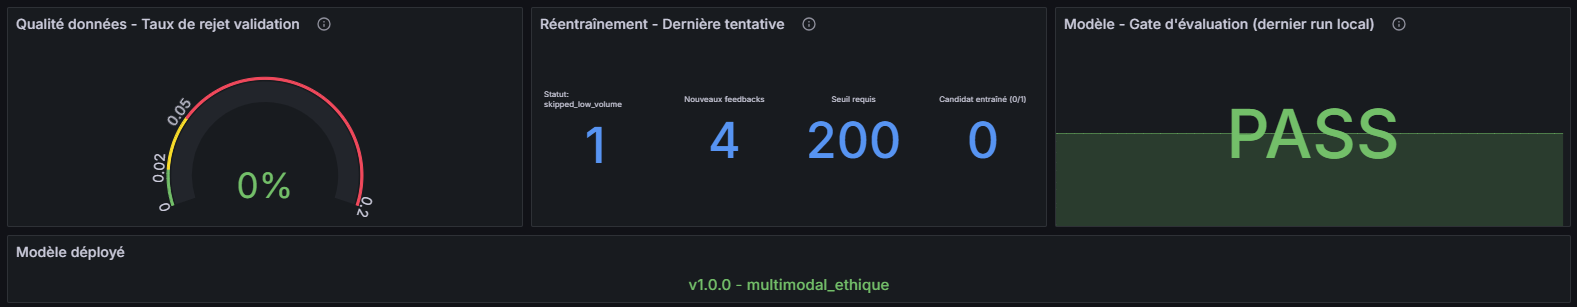

1. **Qualité des données – Taux de rejet de validation (à gauche)**  
   Le taux est de **0 %**, ce qui signifie que les requêtes entrantes respectent parfaitement le schéma attendu.

2. **Réentraînement – Dernière tentative (au centre)**  
   Ce panneau fournit un diagnostic détaillé du pipeline de réentraînement :

   - **Statut :** `skipped_low_volume`  
     Le réentraînement a été ignoré car le volume de données disponible n'est pas suffisant.

   - **Nouveaux feedbacks :** `4`  
     Seuls 4 nouveaux retours (labels) ont été collectés.

   - **Seuil requis :** `200`  
     Un minimum de 200 observations est nécessaire pour déclencher un réentraînement pertinent, afin d'éviter le surapprentissage sur un échantillon trop faible.

   - **Candidat entraîné :** `0/1`

3. **Modèle – Gate d'évaluation (à droite)**  
   Le statut affiché est **PASS** (en vert), indiquant que la dernière évaluation locale de la passerelle de validation s'est déroulée avec succès.

4. **Modèle déployé (en bas)**  
   La version actuellement déployée est :

   ```text
   v1.0.0 - multimodal_ethique


**Analyse des prédictions du modèle**
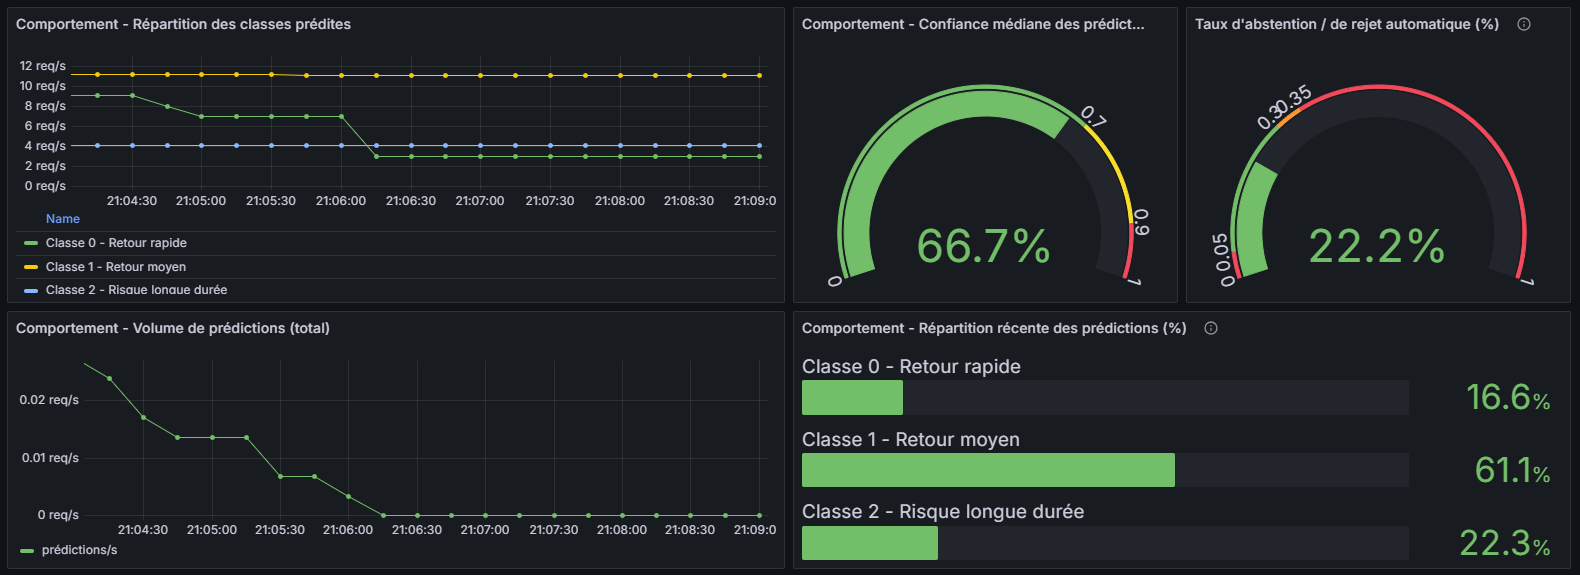
- **Répartition des classes prédites**  
  Sur la fenêtre observée, la **classe 1** (« Retour moyen ») est la plus représentée, suivie de la **classe 0** puis de la **classe 2**.

- **Confiance médiane** : `66,7 %`  
  Cette métrique correspond à la médiane de la probabilité associée à la classe retenue par le modèle. Elle ne doit pas être interprétée comme un taux de réussite ou de précision du modèle.

- **Taux d’abstention / de rejet automatique** : `22.2 %`   
  La valeur est sous le seuil d’alerte fixé à `35 %`.
  Cela signifie que, sur la période observée, 22.2 % des dossiers ont été redirigés vers une **revue humaine** plutôt que traités automatiquement par le modèle. 

- **Volume de prédictions**  
  Nombre de prédictions par seconde.

- **Écart à la baseline**  
  Elles représentent la **répartition récente des prédictions entre les différentes classes**.

**Analyse du drift des données et des prédictions**
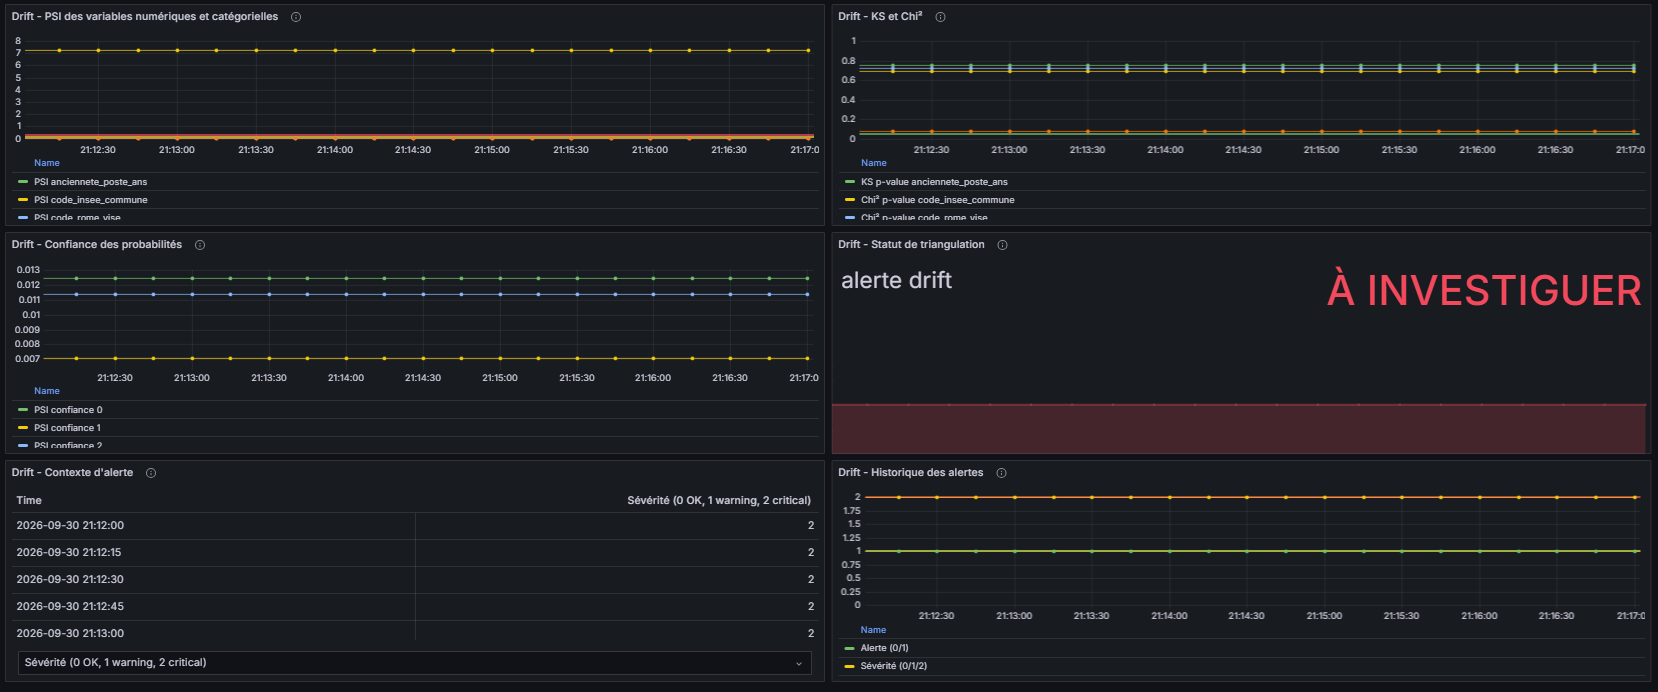

> Ces panneaux affichent le **dernier rapport de drift batch**. Ils comparent une fenêtre de référence à une fenêtre courante et ne recalculent pas le drift à chaque prédiction. Les courbes quasi horizontales correspondent simplement au même rapport Prometheus réexposé lors de plusieurs scrapes successifs.

**1. Drift – PSI des variables**

Le **PSI (Population Stability Index)** mesure l'ampleur du changement de distribution d'une variable.

**Repères d'interprétation :**
- `PSI < 0,10` : distribution stable
- `0,10 ≤ PSI < 0,25` : surveillance recommandée
- `PSI ≥ 0,25` : dérive très forte

**Valeurs observées :**

| Variable | PSI | Interprétation |
|-----------|------:|---------------|
| `code_insee_commune` | **7,26** | 🔴 Dérive très forte (à remplacer par département) |
| `anciennete` | 0,020 | ✅ Stable |
| `code_rome` | 0,058 | ✅ Stable |
| `diplome` | 0,009 | ✅ Stable |

Le PSI de `code_insee_commune` est largement supérieur au seuil d'alerte de `0,25`, ce qui justifie une investigation approfondie.

**2. Drift – Tests KS et Chi²**

Ces tests statistiques évaluent si les distributions de référence et courantes sont significativement différentes.

**Seuil d'alerte :**
- `p-value < 0,05` → dérive statistiquement significative

**Résultats observés :**

| Test | Variable | p-value | Interprétation |
|--------|------------|---------:|---------------|
| KS | `anciennete` | 0,752 | ✅ Non significatif |
| Chi² | `diplome` | 0,082 | ✅ Non significatif |
| Chi² | `code_rome` | 0,728 | ✅ Non significatif |
| Chi² | `code_insee_commune` | 0,694 | ✅ Non significatif |

Aucune des p-values observées ne franchit le seuil de `0,05`. Les tests statistiques ne mettent donc pas en évidence de dérive significative.

**3. Drift – Confiance des probabilit**

Ce panneau mesure le PSI appliqué aux probabilités produites par le modèle pour chaque classe.

| Classe | PSI |
|----------|------:|
| Classe 0 | 0,012 |
| Classe 1 | 0,007 |
| Classe 2 | 0,011 |

L'ensemble des valeurs reste très faible (`< 0,10`), ce qui indique une **stabilité de la distribution des probabilités prédites**.

**4. Statut de triangulation**

- **Statut :** **À INVESTIGUER**
- **Sévérité :** `2`

Ce statut est déclenché par le PSI particulièrement élevé observé sur la variable `code_insee_commune`, dont la valeur dépasse largement le seuil d'alerte de `0,25`.

**5. Contexte et historique**

Les panneaux de contexte rappellent :

- le niveau de sévérité du dernier rapport ;
- l'état du dernier diagnostic de drift ;
- l'évolution apparente du rapport au fil des scrapes Prometheus.


### 9.2 Boucle de rétroaction

Après une prédiction, le conseiller peut saisir l’issue observée et transmettre au backend le request_id, la classe prédite, l’étiquette réelle et un commentaire facultatif.

Le backend vérifie que la prédiction existe et que la classe prédite correspond à celle enregistrée. Il stocke le feedback dans SQLite. Une nouvelle soumission avec la même classe prédite et la même étiquette réelle est traitée de manière idempotente; une soumission contradictoire est refusée. Le commentaire n’est pas pris en compte pour cette comparaison et n’est pas actualisé lors d’une nouvelle soumission identique.

**Éligibilité et limites actuelles**
Le code ne met pas en œuvre de délai de maturité : un feedback peut être utilisé dès qu’il est enregistré et qu’il n’a pas encore été traité par un run de réentraînement. La définition d’un délai minimal reste à établir avec le métier.

L’unicité est assurée par request_id, pas par personne ou dossier. Bien que l’identifiant de personne soit disponible au niveau des prédictions, le retrainer ne s’en sert pas pour dédoublonner les feedbacks. Il exclut les lignes du holdout de référence de l’apprentissage et filtre certains feedbacks dont les caractéristiques recoupent celles du jeu de référence; cela ne constitue pas une garantie de déduplication par personne.

Le backend expose le nombre total de feedbacks et le nombre de feedbacks non consommés. Il ne calcule pas actuellement le taux de couverture des feedbacks ni la distribution de leurs étiquettes comparée aux classes prédites.

**Utilisation pour le réentraînement**
Le retrainer lit les feedbacks non consommés. Après exclusion des recoupements avec le jeu de référence, il vérifie le seuil minimal configuré, fixé à 200 par défaut. Si le seuil n’est pas atteint, le run reçoit le statut skipped_low_volume et les feedbacks restent disponibles pour une exécution ultérieure.

Lorsque le seuil est atteint, les feedbacks sont ajoutés à l’historique d’entraînement. Le jeu de référence gelé est exclu de l’apprentissage. Après l’évaluation et la décision de promotion ou de rejet, les feedbacks lus par le run sont marqués comme consommés. En l’état, cette opération marque aussi les feedbacks écartés pour recoupement avec le jeu de référence; « traité par le run » décrit donc plus exactement ce statut que « effectivement utilisé pour l’entraînement ».

**Utilisation pour la mesure**
Les feedbacks restent conservés dans SQLite après leur consommation pour le réentraînement. Toutefois, le code ne sépare pas encore formellement leur éligibilité à la mesure de leur utilisation pour l’apprentissage. Il ne calcule pas les métriques de confirmation en filtrant les feedbacks postérieurs à l’entraînement du modèle évalué ou absents de son jeu d’entraînement.

Le calcul du taux d’erreur 2→0, du label shift et des métriques de concept drift sur des feedbacks confirmés reste donc à mettre en place. Le caractère facultatif du retour doit également être pris en compte : les feedbacks disponibles ne sont pas nécessairement représentatifs de l’ensemble des prédictions.

Enfin, les conseillers peuvent être influencés par la prédiction affichée lorsqu’ils renseignent l’issue observée. Ce risque de contamination des étiquettes est identifié; un échantillon de contrôle indépendant pourra être envisagé.

Le déclenchement du réentraînement, l’évaluation du candidat et les règles de promotion sont décrits en section 9.3.

### 9.3 Plan de réentraînement

**Déclenchement du workflow**

Le workflow GitHub Actions peut être déclenché manuellement ou automatiquement le premier jour de chaque mois à 00:00 UTC. Le déclenchement mensuel vérifie si les conditions de réentraînement sont réunies; il ne garantit pas qu’un entraînement aura lieu.
En complément du déclenchement manuel ou périodique, l’API lance automatiquement le retrainer lorsqu’un feedback est enregistré et que le seuil configuré de feedbacks non consommés est atteint. Le traitement est asynchrone. Après exclusion des recoupements avec le jeu de référence, le retrainer applique ses contrôles de qualité; la promotion et le déploiement restent séparés. Ce déclenchement nécessite la configuration de `RETRAIN_API_TOKEN`.

**Condition minimale de déclenchement**

Le réentraînement nécessite au moins 200 feedbacks validés et non consommés par défaut. Le seuil peut être modifié lors d’un lancement manuel. Le comptage exclut les feedbacks dont les caractéristiques recoupent le jeu de référence.

Si le seuil n’est pas atteint, aucun candidat n’est entraîné, le statut `skipped_low_volume` est enregistré et les feedbacks restent disponibles pour une exécution ultérieure.

Les signaux de performance et de dérive ne déclenchent pas le réentraînement. Ils servent à l’évaluation ou à l’investigation, sans lancer automatiquement ce processus.


**Entraînement d'un modèle candidat**

Lorsque le seuil de feedbacks est atteint :

- Les feedbacks non consommés sont lus; ceux qui recoupent le jeu de référence sont écartés. Les autres sont ajoutés aux données historiques d’entraînement.
- Le holdout gelé est exclu de l’apprentissage.
- Un modèle candidat est entraîné.
- Le candidat et le modèle en production sont évalués sur le même jeu de référence.
- Les résultats sont comparés selon la gate de promotion du réentraînement, qui vérifie les planchers de qualité, les tolérances de régression et une amélioration du F1 macro ou du recall de la classe 2.
- La gate de release reste distincte et s’applique au workflow d’évaluation des releases.

**Critères de promotion**

La promotion du candidat est autorisée uniquement si, sur le jeu de référence gelé :

- les seuils minimaux de qualité sont respectés ;
aucune régression ne dépasse les tolérances définies ;
- le F1 macro ou le recall de la classe 2 s’améliore par rapport au modèle en production.
- Si l’une de ces conditions échoue, le candidat est rejeté et le modèle en production reste inchangé. Le candidat rejeté demeure néanmoins enregistré comme artefact du run.

**Traçabilité et auditabilité**

Lorsqu’un candidat est entraîné et évalué, le run enregistre les paramètres, les métriques d’entraînement et de référence, les artefacts du candidat ainsi que la décision de promotion ou de rejet.

- MLflow conserve les paramètres, métriques, artefacts et la décision.
- Le journal des décisions conserve la décision, ses règles, les métriques, les références aux artefacts et leurs empreintes.
- En cas de volume insuffisant, le run enregistre skipped_low_volume dans son rapport de résultat et les métriques Prometheus. Aucun candidat ni décision de promotion ou de rejet n’est alors produit.

**Déploiement et rollback**

Avant la promotion :

- Le candidat et ses métadonnées de configuration sont sauvegardés; le modèle et la configuration actifs sont sauvegardés pour permettre un retour arrière.
- La gate de promotion évalue le candidat par rapport au modèle en production sur le jeu de référence.
- Le déploiement n’a lieu que si la gate accepte le candidat.

En cas de problème après le déploiement, un lancement manuel du workflow permet de restaurer `Rollback` le modèle et la configuration précédemment sauvegardés.



```mermaid
flowchart TD
    Start["GitHub Actions<br/>Déclenchement manuel ou mensuel"]
    Backup["Sauvegarde du modèle et de la configuration actifs"]
    Count["Comptage des feedbacks non consommés<br/>après exclusion des recoupements avec la référence"]
    Threshold{"Seuil atteint ?<br/>200 par défaut"}

    Start --> Backup --> Count --> Threshold

    Threshold -->|Non| Skip["skipped_low_volume<br/>Aucun candidat entraîné<br/>Feedbacks laissés non consommés"]
    Threshold -->|Oui| Train["Entraînement du candidat"]
    Train --> Evaluate["Évaluation du candidat et de la production<br/>sur le même jeu de référence"]
    Evaluate --> Gate{"Gate de promotion"}

    Gate -->|Échec| Rejected["Candidat rejeté<br/>Production inchangée"]
    Gate -->|Succès| Promote["Candidat promu"]
    Promote --> Activate["Tentative d’activation"]
    Activate --> ActivationResult{"Activation réussie ?"}

    ActivationResult -->|Oui| Monitor["Surveillance en production<br/>Pas de détection automatique des problèmes ultérieurs"]
    ActivationResult -->|Non| AutoRollback["Rollback automatique<br/>Restauration du modèle et de la configuration précédents"]

    Rejected --> Consumed["Feedbacks lus marqués comme consommés"]
    Monitor --> Consumed
    AutoRollback --> Consumed

    Operator["Problème constaté après activation"]
    Manual["Lancement manuel du workflow<br/>rollback = true"]
    Restore["Restauration du modèle et de la configuration sauvegardés"]

    Monitor -.->|Problème ultérieur| Operator
    Operator --> Manual --> Restore
```

### 9.4 Robustesse en exploitation

La robustesse en exploitation consiste à surveiller les défaillances et les changements observés après la mise en production. Elle complète les stratégies de fallback définies en §7.2 : cette section décrit les signaux à suivre, les conditions d’investigation et les éléments qui restent à automatiser.

| Axe | Métrique opérationnelle | Seuil et action envisagés | État dans le projet |
|---|---|---|---|
| **OOD — entrée hors distribution** | Score OOD par dossier, par exemple avec Isolation Forest sur les variables tabulaires, et taux de dossiers signalés par fenêtre. Le PSI/KS batch mesure des changements globaux, mais ne remplace pas un score individuel. | Calibrer le seuil sur les données de référence. Si le seuil est dépassé, journaliser le `request_id` et le score, puis appliquer le fallback prévu en §7.2. Ne pas enregistrer le contenu brut du dossier dans les métriques. | **À implémenter** : aucun détecteur OOD individuel n’est branché à l’inférence. Le PSI/KS batch existe. |
| **Revue humaine et seuil de rejet** | Taux de dossiers orientés vers une revue humaine parmi les dossiers scorés. Suivre aussi séparément la part des prédictions sous le seuil de confiance. | Comparer les taux à une référence sur une fenêtre glissante de quatre semaines. Si l’écart relatif dépasse **20 %**, avec un volume suffisant, déclencher une alerte et revoir le seuil. Ne pas le modifier automatiquement. | **Partiel** : le backend mesure un compteur global de revues et Grafana affiche leur taux sur 15 minutes. Les deux motifs de revue ne sont pas distingués dans ce compteur; la comparaison sur quatre semaines et l’alerte restent à automatiser. |
| **Calibration** | Brier score, courbe de fiabilité et ECE, idéalement par classe, calculés périodiquement sur des labels confirmés et suffisamment mûrs. | Si la calibration se dégrade durablement sur un échantillon suffisant, investiguer et évaluer Platt ou isotonic sur un jeu de calibration distinct. Déployer le calibrateur seulement après validation; ne pas réentraîner tout le modèle si seule la calibration dérive. | **Partiel** : src/calibration.py fournit une table de fiabilité, un ECE binaire et une comparaison d’ECE à une référence. Le Brier score, l’évaluation par classe et le suivi périodique sur les labels confirmés ne sont pas implémentés. Le backend stocke les feedbacks, mais ne les exploite pas pour ces métriques.implémentés. |

Le fallback défini en §7.2 est implémenté dans le service, avec deux règles :
- **Règle de base (toujours active)** : un dossier est orienté vers une revue humaine si la confiance maximale est **inférieure à 0,55** (`p_max < 0,55`).
- **Règle complémentaire (optionnelle, désactivée par défaut)** : lorsqu'elle est activée, un dossier est aussi orienté vers une revue humaine si la classe prédite est 0 et que `P(classe 2) ≥ 0,04`.

Le backend compte les revues, mais ne distingue pas encore les deux motifs dans sa métrique.

**Réserve sur la calibration :** voir la limite du pilote en §7.4. Les seuils de fallback doivent être confirmés avec l'artefact calibré effectivement déployé avant le démarrage du pilote.

Les panneaux Grafana rendent les signaux visibles, mais les règles d’alerte et leurs destinataires doivent être configurés explicitement. Ne pas utiliser `request_id` ou un identifiant usager comme label Prometheus; conserver ces identifiants, si nécessaire, dans des logs corrélés.

> **Lien entre conception et exploitation**
>
> - §7.2 définit les règles de décision et les mécanismes de fallback.
> - §9.4 suit leur déclenchement et leur efficacité en production.
>
> Un fallback conçu mais jamais mesuré peut sembler disponible sans que son déclenchement soit vérifié. Un signal mesuré sans seuil d’action, alerte ni responsable identifié ne garantit pas non plus une réponse opérationnelle.

### 9.5 📝 Synthèse amélioration continue

### Cadence de surveillance

| Couche | Fréquence | État dans le projet |
|---|---|---|
| **Supervision du service** (disponibilité, erreurs HTTP, latence) | Scrape Prometheus toutes les 5 s; rafraîchissement Grafana toutes les 30 s | Métriques et dashboard en place; règles d’alerte et destinataires à configurer. |
| **Comportement du modèle** (classes prédites, probabilités, revues humaines) | Mesures continues; scrape toutes les 5 s et affichage Grafana toutes les 30 s | Compteurs et distributions visibles. Le taux de revue est agrégé; les motifs ne sont pas séparés et aucune alerte n’est configurée. |
| **Dérive des entrées** (PSI, KS, χ²) | Analyse batch via `scripts/drift_analysis.py` | Outil et exposition des résultats disponibles; exécution périodique et notifications non planifiées. |
| **Non-régression sur le jeu de référence gelé** | À chaque exécution de la CI : lancement manuel, push, tag `v*` ou pull request vers `main` | Gate en place. Elle évalue le modèle sur la référence gelée; Elle ne mesure pas la dérive des données de production. |
| **Performance sur les labels confirmés** (erreur 2→0, concept drift, label shift) | Suivi mensuel envisagé, sur une fenêtre cumulée | À automatiser. La maturité des labels et les métriques de confirmation ne sont pas encore gérées par le code. |

### Déclencheurs de réentraînement

- **Déclenchement périodique guidé par le volume :** le workflow s’exécute manuellement ou mensuellement. Le seuil minimal est de **200 feedbacks validés et non consommés par défaut**; il peut être modifié lors d’un lancement manuel. Les feedbacks recoupant le jeu de référence sont exclus du comptage. Aucun délai de maturité n’est appliqué.
- **Déclenchement manuel hors calendrier :** possible après investigation, sous réserve que le seuil de feedbacks soit atteint. Le workflow ne vérifie pas automatiquement qu’une dégradation a été confirmée sur des labels mûrs.
- **Dérive :** un signal de drift seul ne déclenche pas de réentraînement automatique.

### Plan de remédiation

| Situation | Action proposée | Responsable proposé |
|---|---|---|
| Dérive des entrées sans baisse de performance confirmée | Poursuivre la surveillance et documenter les changements de données ou de population. | ML Platform |
| Dérive des entrées avec baisse de performance confirmée | Investiguer les causes et évaluer l’opportunité d’un réentraînement. | ML Platform et métier |
| Baisse de performance sans dérive des entrées (concept drift possible) | Investiguer les labels, la période et la relation entre les variables et la cible avant toute remédiation. | ML Platform et métier |
| Incident de service | Suivre une procédure d’exploitation et escalader à l’équipe SRE; le runbook reste à formaliser dans le projet. | SRE |
| Problème après une promotion | Déclencher le rollback manuel. Une restauration automatique n’est tentée que si la commande d’activation échoue. | ML Platform |


---

# Journal de bord 

<a id="jour-1"></a>
## 📅 Journal de bord – Jour 1 (25/08/2026)

### 🔧 Étapes / Actions réalisées
- Prise de connaissance du sujet de certification et du jeu de données `dataset_trajectoire_emploi.csv`.
- Rédaction du cadrage métier (§1) : identification du client (agence pour l'emploi), du besoin (aiguillage des demandeurs d'emploi vers un accompagnement adapté) et des bénéficiaires directs (conseillers) et indirects (usagers).
- Reformulation du problème en tâche IA : classification multiclasses (3 classes) visant à prédire `classe_retour_emploi` (retour < 6 mois / 6-12 mois / > 12 mois).
- Première rédaction du tableau de critères de succès (cible initiale côté client), en distinguant critère métier, critère modèle et critère opérationnel.
- Repérage à chaud des premiers risques éthiques et réglementaires pressentis : présence de variables potentiellement sensibles (`age`, `nationalite_hors_ue`) et cadre RGPD à respecter sur les données individuelles d'usagers.

### 📝 Observations / Difficultés
- La reformulation en tâche de classification multiclasses (3 classes) n'a pas posé de difficulté : la cible `classe_retour_emploi` est clairement définie. 
- Identification des proxys : repérer les variables sensibles directes (`age`, `nationalite_hors_ue`) était simple, mais identifier les variables pouvant les reconstituer indirectement (`code_rome_vise`, `code_insee_commune`, `synthese_entretien`) l'était beaucoup moins. Ce point a été noté comme risque à traiter en EDA puis en audit de biais, et non comme un problème résolu.
- Connaissance du cadre éthique et réglementaire : le cadre applicable (RGPD, minimisation des données, discrimination indirecte, critères prohibés par le droit français) n'était pas maîtrisé d'emblée. Une montée en compétence est nécessaire avant de décider quelles variables conserver.


### ✅ Prochaines étapes
- Finaliser la synthèse de cadrage (§1.6).
- Identifier précisément la source, le format et la volumétrie du jeu de données (§2.1).
- Charger le dataset et produire un premier dictionnaire de variables (§2.2-2.3).
- Repérer dès le chargement les variables à risque.

---

## 📎 Annexes

## A. Glossaire métier & technique

## B. Décisions techniques détaillées

## C. Journal de bord

<a id="jour-2"></a>
## 📅 Journal de bord – Jour 2 (26/08/2026)

### 🔧 Étapes / Actions réalisées
- Documentation de la source des données (§2.1) : CSV de l'agence nationale de l'emploi, ~2 500 lignes × 10 colonnes, accès en lecture seule, version du jeu de données `2026-08-14`.
- Chargement du dataset (§2.2) et premier contrôle de la structure (types de colonnes, nombre de lignes, aperçu).
- Construction du dictionnaire de variables (§2.3) : nature (numérique / catégorielle / texte), plage de valeurs, et statut « cible » / « sensible » pour chacune des 10 variables brutes (la variable `departement`, dérivée de `code_insee_commune`, est ajoutée ensuite)(`usager_id`, `age`, `niveau_diplome`, `anciennete_poste_ans`, `code_rome_vise`, `code_insee_commune`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien`, `departement`, `classe_retour_emploi`).
- Rédaction de la synthèse d'acquisition (§2.4) : origine administrative mixte (données déclaratives + saisies conseiller), volumétrie modeste à mettre en regard des 3 classes cibles, et premiers signaux de vigilance sur `code_insee_commune` (quasi-identifiant, 2407 modalités pour 2500 lignes) et sur `synthese_entretien` (longueur de texte très resserrée, 63-77 caractères).

### 📝 Observations / Difficultés
- `code_insee_commune` a un nombre de modalités quasi égal au nombre de lignes : cela le rend inutilisable tel quel pour la modélisation et pose la question d'un regroupement (ex. département) à explorer en EDA.
- La variable texte `synthese_entretien` interroge dès la lecture : sa faible variabilité de longueur suggère un champ pré-rédigé ou semi-automatisé plutôt qu'une note libre — hypothèse à vérifier lors de l'analyse textuelle (§3.3.3).

### ✅ Prochaines étapes
- Démarrer l'EDA (§3) : premier coup d'œil global, puis contrôle qualité (manquants, doublons, valeurs aberrantes).
- Étudier la distribution des variables numériques, catégorielles et de la variable texte.
- Examiner l'équilibre de la variable cible `classe_retour_emploi`.

---

<a id="jour-3"></a>
## 📅 Journal de bord – Jour 3 (27/08/2026)

### 🔧 Étapes / Actions réalisées
- Premier coup d'œil global sur le dataset (§3.1) : types, statistiques descriptives, valeurs uniques par colonne.
- Contrôle qualité (§3.2) : détection des valeurs manquantes (`age` ~4,9 %, `niveau_diplome` ~3,4 %, `est_allocataire` ~1,8 %, `synthese_entretien` ~3,2 %) et des doublons (aucun doublon exact détecté, ni global ni sur `usager_id`).
- Détection des valeurs aberrantes par méthode IQR sur les variables numériques : aucun outlier sur `age`, mais 126 observations identifiées comme extrêmes sur `anciennete_poste_ans` (au-delà de ~9 ans, jusqu'à 22,6 ans).
- Analyse de la distribution des variables numériques (§3.3.1) : `age` quasi uniforme entre 18 et 63 ans, `anciennete_poste_ans` fortement asymétrique à droite.
- Analyse des variables catégorielles (§3.3.2) : fort déséquilibre sur `nationalite_hors_ue` (88,2 % / 11,8 %), répartition plus équilibrée sur `est_allocataire`, modalité « Bac » dominante sur `niveau_diplome`, `code_rome_vise` à 50 modalités regroupables en 12 familles professionnelles.
- Première exploration de la variable textuelle `synthese_entretien` (§3.3.3) et des regroupements potentiels (§3.3.4, ex. `code_insee_commune` → `departement`).

### 📝 Observations / Difficultés
- Les outliers d'`anciennete_poste_ans` ne sont pas supprimés à ce stade : ils peuvent correspondre à des situations réelles (reconversion tardive, longue carrière) et devront être examinés au regard des contraintes métier plutôt qu'écartés mécaniquement.
- Le déséquilibre marqué de `nationalite_hors_ue` (88,2 %/11,8 %) est noté comme point de vigilance pour l'analyse de biais à venir : le sous-groupe minoritaire sera statistiquement plus fragile.
- Les taux de valeurs manquantes restent modérés (< 5 % par variable) et ne remettent pas en cause l'exploitabilité du dataset, mais imposent de choisir une stratégie d'imputation explicite en §4 plutôt que de supprimer les lignes concernées.

### ✅ Prochaines étapes
- Étudier l'équilibre de la variable cible (§3.4).
- Analyser les corrélations et croisements entre variables et cible (§3.5).
- Mener l'analyse des biais et variables sensibles (§3.6) : disparate impact, biais lexical potentiel dans `synthese_entretien`.
- Rédiger la synthèse EDA (§3.7) et réviser le tableau de critères de succès à la lumière des observations.

---

<a id="jour-4"></a>
## 📅 Journal de bord – Jour 4 (28/08/2026)

### 🔧 Étapes / Actions réalisées
- Analyse de l'équilibre de la cible (§3.4) : classe 1 (retour 6-12 mois) 44,48 %, classe 0 (retour < 6 mois) 37,44 %, classe 2 (retour > 12 mois, minoritaire) 18,08 %.
- Étude des corrélations et croisements (§3.5) : matrice de corrélation, pairplot numériques par classe, moyennes par classe pour les variables numériques, tableaux croisés normalisés (part de chaque classe par modalité) pour les variables catégorielles. `age` ressort comme la variable numérique la plus discriminante (moyenne croissante de 36,8 à 46,5 ans selon la classe) ; `anciennete_poste_ans` apporte peu de signal (pas de colinéarité, r = -0,015). `synthese_entretien`, `niveau_diplome` et `code_rome_vise` présentent les associations les plus fortes avec la cible.
- Analyse des biais et variables sensibles (§3.6) : heatmaps de croisement cible / `nationalite_hors_ue` et `groupe_age`</span> ; recherche de mentions explicites de critères sensibles dans `synthese_entretien` (âge, origine, genre) ; test de prédictibilité d'une variable sensible à partir du texte (signal de biais lexical implicite) ; calcul du disparate impact (règle des 4/5) sur `nationalite_hors_ue` (DI = 0,342) et `groupe_age` (DI=0,446).
- Rédaction de la synthèse EDA (§3.7) et révision du tableau de critères de succès.

### 📝 Observations / Difficultés
- Le déséquilibre modéré de la cible confirme qu'une accuracy seule serait trompeuse (un modèle qui prédirait systématiquement la classe 1 atteindrait déjà ~44 % de bonnes classifications) ; le choix du F1-macro et du recall de la classe 2 comme métriques de pilotage a été argumenté sur cette base.
- Le test de biais lexical sur `synthese_entretien` a nécessité une vectorisation TF-IDF préliminaire pour vérifier si le texte permettait de prédire indirectement une variable sensible : ce point a été traité comme un signal à surveiller en modélisation plutôt que comme un motif d'exclusion immédiate de la variable.
- Choix de la représentation du texte `synthese_entretien` : cette variable est à la fois la plus riche en signal  et la plus difficile à encoder. Deux options ont été comparées.

  | Option | Avantage | Limite retenue |
  |---|---|---|
  | One-Hot sur la valeur complète | Simple, lisible | Fige les valeurs connues à l'entraînement ; une formulation inédite n'a aucune colonne et devient une ligne de zéros. Ne capte aucune proximité entre deux phrases proches. |
  | **TF-IDF** | Pondère les mots discriminants, produit un vecteur pour tout texte partageant du vocabulaire avec le corpus, reste utilisable si les conseillers reformulent | Voir limites ci-dessous. |

- **Pourquoi le TF-IDF a été préféré** : le texte est susceptible d'évoluer en production (nouvelles formulations, changement de conseillers ou de gabarit). Le TF-IDF généralise au niveau des mots et non de la phrase entière. Il s'intègre aussi dans le `Pipeline` scikit-learn : le vocabulaire et les pondérations IDF sont appris sur le train uniquement, ce qui évite toute fuite vers le test.

- **Hypothèse de départ à vérifier** : en J2, la longueur des textes était très resserrée (63 à 77 caractères), ce qui suggère un champ pré-rédigé ou semi-automatisé. Si le nombre de phrases distinctes est faible, un One-Hot sur la phrase entière aurait été défendable à court terme. Le nombre de valeurs uniques doit donc être mesuré et consigné, car il conditionne la pertinence du choix.

- **Limites identifiées du TF-IDF** :
  - *Vocabulaire figé* : un mot absent du corpus d'entraînement est ignoré sans alerte. Le TF-IDF ne supprime donc pas le problème de l'évolution du texte, il l'atténue.
  - *Ordre et négation* : en unigrammes, « difficulté de mobilité » et « pas de difficulté de mobilité » donnent presque le même vecteur. Les bigrammes atténuent ce défaut mais augmentent la dimension.
  - *Dimension élevée et parcimonie* : avec ~2 500 lignes, un grand vocabulaire favorise le surapprentissage. Les réglages `min_df`, `max_features` et `ngram_range` doivent être justifiés (valeurs retenues : à confirmer).
  - *Interprétabilité* : les colonnes sont des mots, ce qui permet SHAP (J9) et la lecture métier des termes influents.

- **Risque éthique propre au texte** : le TF-IDF donne au modèle accès à tout mot présent, y compris ceux qui reconstituent indirectement une variable sensible (âge, origine, genre). Le test de prédictibilité de J4 (TF-IDF vers variable sensible) est donc indissociable de ce choix.

### ✅ Prochaines étapes
- Réaliser le split train/test (§4.1), stratifié sur la cible.
- Construire le pipeline de preprocessing (§4.2) : imputation et standardisation des variables numériques, imputation et encodage des variables catégorielles, vectorisation TF-IDF de `synthese_entretien`.
- Définir les scénarios de jeux de données (§4.3) permettant de comparer performance maximale, retrait des variables sensibles, et contribution du texte.
- Rédiger la synthèse de préparation (§4.4) et les assertions de qualité (§4.5) avant de passer à la modélisation.

---

<a id="jour-5"></a>
## 📅 Journal de bord – Jour 5 (31/08/2026)

### 🔧 Étapes / Actions réalisées
- Réalisation du split train/test (§4.1) avec stratification sur `classe_retour_emploi` pour préserver la répartition des 3 classes dans les deux jeux, `random_state=42` fixé pour la reproductibilité.
- Construction du pipeline de preprocessing (§4.2) avec un `ColumnTransformer` intégré à un `Pipeline` scikit-learn, afin d'éviter toute fuite de données entre prétraitement et modélisation : imputation puis standardisation (`StandardScaler`) pour `age` et `anciennete_poste_ans` ; imputation puis encodage (`OneHotEncoder`) pour `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue` et (`OrdinalEncoder`) `niveau_diplome`, ; vectorisation `TfidfVectorizer` pour `synthese_entretien`.
- Définition des scénarios de jeux de données (§4.3), dont le scénario S1 « Multimodal complet » (toutes les variables exploitables hors `usager_id`) servant de référence pour mesurer la performance maximale atteignable avant atténuation des risques de biais, et un scénario retirant les variables sensibles directes pour en mesurer l'impact et S3 (texte seul) et S4(tabulaire seul) : mesure la valeur ajoutée de la combinaison multimodale par rapport à chaque modalité utilisée séparément.
- Rédaction de la synthèse de préparation (§4.4), justifiant en particulier le choix du TF-IDF plutôt que du One-Hot sur `synthese_entretien` : le texte libre est susceptible d'évoluer (nouvelles formulations des conseillers), et un encodage figé au moment de l'entraînement ne saurait pas traiter une valeur textuelle inédite, contrairement au TF-IDF qui produit un vecteur cohérent pour tout texte partageant du vocabulaire avec le corpus connu.
- Mise en place des assertions de qualité (§4.5) sur les données préparées (absence de manquants résiduels dans la cible, absence de doublons résiduels, cohérence de la taille des splits) et premier lancement des tests associés via `pytest`.

### 📝 Observations / Difficultés
- Le choix de la stratégie d'encodage pour `synthese_entretien` a nécessité une réflexion approfondie : le TF-IDF a été préféré au One-Hot car il ne fige pas les catégories connues au moment de l'entraînement et reste utilisable si de nouvelles formulations apparaissent en production, ce qui rejoint une préoccupation d'industrialisation abordée plus tard dans le projet.
- Les assertions de qualité (§4.5), volontairement conçues pour arrêter le notebook en cas d'échec, ont été traitées comme première brique de tests automatisés du projet plutôt que comme une simple vérification manuelle — logique qui sera généralisée plus tard avec `pytest`.

### ✅ Bilan et prochaines étapes
- Le cadrage métier, l'acquisition des données, l'EDA et la préparation des données (parties 1 à 4) sont finalisés : le jeu de données est nettoyé, compris, et transformé en jeux d'entraînement/test exploitables via un pipeline reproductible.
- Prochaine étape : passer à la modélisation & entraînement (§5) — sélection des familles de modèles candidates, validation croisée, comparaison des scénarios de jeux de données définis en §4.3.

---

<a id="jour-6"></a>
## 📅 Journal de bord – Jour 6 (01/09/2026)

### 🔧 Étapes / Actions réalisées
- Choix de la famille des modèles: La famille **ML classique** est retenue, notamment avec Scikit-learn et XGBoost, car elle est adaptée aux données tabulaires et textuelles du projet tout en offrant un bon compromis entre performance, coût et explicabilité.
- Démarrage de la modélisation (§5) : définition du protocole d'évaluation — holdout stratifié de 20 % réservé exclusivement à l'évaluation finale, validation croisée stratifiée (5 folds) réalisée uniquement sur le train.
- Choix des métriques de pilotage de la validation croisée (§5.2) : F1-macro (vue d'ensemble équilibrée), recall Classe 2 et F1 Classe 2 (détection de la classe à risque), taux d'erreur critique 2→0 (erreur la plus coûteuse côté métier). L'accuracy est conservée mais reléguée en indicateur secondaire, le déséquilibre de la cible pouvant la rendre trompeuse.
- Entraînement d'une première série de baselines (§5.3-5.4) : 4 algorithmes (régression logistique, random forest, LightGBM, XGBoost) croisés avec les 4 scénarios de jeux de données (§4.3), en configuration `balanced` (pondération de classe / poids d'échantillon).
- Construction d'un tableau de synthèse comparant les 16 combinaisons sur F1-macro, recall Classe 2 et taux d'erreur critique 2→0 (moyenne et écart-type sur les folds).

### 📝 Observations / Difficultés
- La famille **ML classique** est retenue et les approches **Deep Learning, SLM, LLM/RAG et agentiques** sont écartées car elles sont plus complexes et coûteuses, sans bénéfice suffisant pour ce problème de classification supervisée. La contrainte décisive est donc **le rapport performance/coût/explicabilité**, particulièrement important dans un contexte d’orientation des demandeurs d’emploi
- Le scénario `multimodal_complet` domine largement les scénarios mono-modalité (`texte_seul`, `tabulaire_seul`) sur toutes les métriques dès cette première série de baselines, confirmant l'intérêt de la double modalité texte + tabulaire pressenti en EDA.
- Les résultats obtenus avec la seule configuration `balanced` ne permettent pas encore de distinguer clairement le meilleur algorithme par scénario : un travail de recherche d'hyperparamètres ciblé sur la classe 2 est nécessaire avant de pouvoir arbitrer (prévu §5.5).
- Point de vigilance noté pour la suite : le critère de sélection utilisé par défaut dans le code de recherche d'hyperparamètres priorise le F1-macro avant les métriques spécifiques à la classe 2 — à surveiller de près une fois le GridSearchCV mis en place, car cet ordre de priorité ne reflète pas nécessairement l'objectif métier prioritaire.

### ✅ Prochaines étapes
- Mettre en place une recherche d'hyperparamètres (GridSearchCV) dédiée à la classe 2 pour chacun des 4 algorithmes (§5.5).
- Vérifier concrètement si le critère de sélection du GridSearchCV (ordre de priorité des métriques) correspond bien à l'objectif métier, et non uniquement à la performance globale.

---

<a id="jour-7"></a>
## 📅 Journal de bord – Jour 7 (02/09/2026)

### 🔧 Étapes / Actions réalisées
- Implémentation de `GridSearchCV` dédiés à la classe 2 pour les 4 algorithmes (§5.5), avec des scorers personnalisés : F1-macro, F1 Classe 2, recall Classe 2, taux d'erreur critique 2→0 — chacun calculé à chaque fold via une fonction de scoring dédiée (`make_scorer`).
- Premier jeu de résultats obtenu et configurations `best_class_2_*` retenues pour chaque couple algorithme/scénario, sur la base du critère de sélection existant (priorité : F1-macro, puis F1 Classe 2, puis erreur critique 2→0).
- Calcul, en complément, d'un second taux d'erreur asymétrique jusque-là non mesuré : le taux 0→2 (usager sans risque classé à tort comme prioritaire), pour disposer d'une vision complète des deux types d'erreur possibles sur la classe 2.

### 📝 Observations / Difficultés
- Analyse de la cause : le critère de sélection du GridSearchCV (`_select_best_grid_search_candidate`) ne prenait en compte que le F1-macro, le F1 Classe 2 et le taux 2→0 — **le taux 0→2 n'entrait jamais dans le calcul de sélection**, alors même qu'il était déjà calculable. Le GridSearchCV pouvait donc choisir un jeu d'hyperparamètres minimisant l'erreur grave en laissant l'autre erreur dériver sans contrainte.
- **Correction apportée** : ajout d'un scorer dédié `error_0_to_2`, puis remplacement du critère de sélection par le ratio de pondération 3:1 traduisant l'hypothèse qu'une erreur grave coûte davantage qu'une fausse alerte. Ce ratio est documenté comme hypothèse de travail à valider avec un porteur métier, et non comme une valeur validée empiriquement.
- Les 4 GridSearchCV ont été relancés avec le critère corrigé ; les nouvelles configurations `best_class_2_*` diffèrent sensiblement des précédentes sur certains hyperparamètres (ex. `n_estimators`, `learning_rate` pour LightGBM), confirmant que le critère initial orientait réellement la sélection vers un optimum différent.

### ✅ Prochaines étapes
- Relancer l'évaluation finale sur le holdout (§5.6) avec les configurations issues du GridSearchCV corrigé.
- Construire le tableau de comparaison des scénarios (§6.1).

---

<a id="jour-8"></a>
## 📅 Journal de bord – Jour 8 (03/09/2026)

### 🔧 Étapes / Actions réalisées
- Évaluation finale sur le holdout (§5.6) de l'ensemble des combinaisons modèle/scénario/configuration retenues, avec calcul systématique de : accuracy, F1-macro, recall/précision/F1 Classe 2, taux d'erreur 2→0 et 0→2, ROC AUC macro issus d'un benchmark dédié.
- Construction du tableau comparatif des 4 scénarios (§6.1), avec sélection de la meilleure configuration par scénario.
- Rédaction de la comparaison argumentée performance / éthique / robustesse (§6) et de la recommandation finale (§6.2-6.3).

### 📝 Observations / Difficultés
- Les mesures de latence et de coût CPU se sont révélées instables d'une exécution à l'autre pour une même combinaison (écarts jusqu'à ×3 observés sur XGBoost `multimodal_complet` entre deux runs), probablement liés à la charge de la machine au moment du test plutôt qu'à une variation réelle du modèle. Ce point est documenté comme limite : ces indicateurs de coût sont traités comme des ordres de grandeur relatifs entre modèles, pas comme des valeurs absolues fiables sans répétition des mesures.
- **La supériorité de l'approche multimodale.** L'analyse démontre sans ambiguïté que le croisement des sources d'information est indispensable. Les scénarios multimodaux (S1 et S2) surperforment largement les approches mono-modalité (texte seul ou tabulaire seul), confirmant la complémentarité des données textuelles et structurées.
- À l'inverse, les options mono-modalité présentent des limites structurelles pénalisantes, qu'il s'agisse d'un taux d'erreur critique trop élevé pour le tabulaire seul ainsi que pour le texte seul.
- **Le dilemme de l'optimalité technique (S1).** Le scénario S1 (Multimodal complet) s'impose de prime abord comme le candidat le plus performant sur le plan purement statistique. Il affiche les meilleures métriques de performance brute, un rappel optimal sur la classe critique et minimise le taux d'erreur grave. Néanmoins, cet optimal technique s'appuie sur la nationalité hors UE et l'âge — deux caractéristiques directement associées à des critères de discrimination prohibés par le droit français (article 225-1 du Code pénal).
- **Le choix responsable du compromis éthique (S2).** Pour répondre à ces impératifs éthiques et légaux, le scénario S2 (multimodal_ethique) retire ces variables sensibles.
- Bien que cette contrainte entraîne un coût mesuré en termes de performance globale et génère initialement une hausse des fausses alertes ($0 \to 2$), les bénéfices en matière de justice prédictive sont majeurs. Le risque juridique et éthique d'une variable directement discriminante a été jugé inacceptable par rapport à une charge opérationnelle accrue — un compromis explicitement assumé et chiffré dans la synthèse.
- À noter : bien que cette approche permette de réduire efficacement les biais directs, un risque résiduel de biais indirect subsiste à travers l'exploitation potentielle de variables proxys par le modèle.

### ✅ Prochaines étapes
- Etablir la matrice de confusion du modèle choisi.
- Approfondir l'explicabilité du modèle retenu (§7.1, SHAP) pour vérifier concrètement l'influence relative des différentes variables, en particulier l'absence d'effet direct de la nationalité.

---

<a id="jour-9"></a>
## 📅 Journal de bord – Jour 9 (08/09/2026)

### 🔧 Étapes / Actions réalisées
- Reconstruction de la matrice de confusion
- Mesure de la performance du modèle sur la classe « Risque longue durée ».
- Identification et quantification des erreurs critiques de type « Risque longue durée → Retour rapide ».
- Analyse des erreurs de classification vers la catégorie « Retour moyen ».
- Évaluation du coût opérationnel associé aux faux positifs et aux orientations préventives générées par le modèle.
- Appréciation de l'adéquation du comportement du modèle avec les objectifs métier d'aide à la décision.
- Analyse d'explicabilité SHAP (§7) sur le modèle retenu, avec un script dédié restreignant l'usage de `TreeExplainer` aux modèles à base d'arbres et calculant les contributions spécifiquement pour la classe 2.

### 📝 Observations / Difficultés
- Le modèle identifie correctement 58 bénéficiaires appartenant à la catégorie « Risque longue durée ».
- Seules 7 erreurs critiques correspondent à des bénéficiaires réellement à risque longue durée classés à tort en « Retour rapide », ce qui limite le risque de sous-accompagnement des publics les plus fragiles.
- 25 bénéficiaires à risque longue durée sont classés en « Retour moyen ». Bien qu'imparfaites, ces erreurs conduisent vers un niveau d'accompagnement intermédiaire et réduisent ainsi leur impact opérationnel.
- La principale limite du modèle concerne le nombre de faux positifs.
- 28 bénéficiaires relevant en réalité de la catégorie « Retour rapide » sont prédits comme « Risque longue durée » et pourraient bénéficier d'un accompagnement renforcé sans nécessité avérée.
- Cette situation traduit un arbitrage volontaire visant à privilégier la détection des situations à risque, au prix d'une augmentation du nombre de fausses alertes.
- Globalement, le scénario S2 – multimodal_ethique est cohérent avec l'objectif métier consistant à réduire les erreurs critiques sur les bénéficiaires les plus vulnérables, tout en acceptant une augmentation des fausses alertes dans une logique d'aide à la décision.
- L'analyse SHAP révèle que les variables dominantes sont liées au contenu de l'entretien (mentions de difficultés cumulées, freins périphériques), au métier recherché et au département — cohérent avec une décision fondée sur des critères directement liés à l'employabilité mais elles constituent aussi des proxys potentiels de facteurs socio-économiques qu'il conviendra de surveiller en production

### ✅ Prochaines étapes
- Evaluer la charge supplémentaire sur les équipes métier et la validé auprès des parties prenantes pour confirmer sa soutenabilité opérationnelle.
- Concevoir le mécanisme de seuil de rejet / abstention (§7.2.2) destiné à limiter le risque résiduel d'erreur critique sur les cas les plus incertains.
- Vérifier la méthode de calibrage de ce seuil pour éviter toute contamination du jeu de test final.

---

<a id="jour-10"></a>
## 📅 Journal de bord – Jour 10 (09/09/2026)

### 🔧 Étapes / Actions réalisées
- Première implémentation d'un mécanisme de seuil de rejet (§7.2.2) : abstention du modèle lorsque la probabilité maximale prédite reste sous un seuil de confiance, avec une règle complémentaire dédiée à la classe 2 (escalade humaine si une prédiction « classe 0 » s'accompagne d'une probabilité non négligeable de classe 2).
- Séparation des données en trois ensembles distincts : entraînement, calibration et holdout.
- Vérification que le holdout recalculé correspond exactement aux indices enregistrés dans les métadonnées du modèle.
- Réentraînement du pipeline uniquement sur X_train_fit, sans exposition au jeu de calibration ni au holdout.
- Calibration isotonique des probabilités sur le jeu de calibration.
- Analyse de la distribution de la confiance pour distinguer les prédictions correctes des erreurs.
- Balayage des seuils de rejet sur le jeu de calibration afin d’étudier le compromis entre abstention, précision et erreurs critiques 2 → 0.
- Test de la cible initiale de 5 %, puis adoption d’une cible révisée de 8,5 % lorsque les contraintes se sont révélées incompatibles.
- Définition d’une règle complémentaire d’escalade humaine pour les prédictions de classe 0 présentant un signal de classe 2.
- Application unique des seuils retenus au holdout pour obtenir l’évaluation finale.
- Génération des matrices de confusion avant et après application du filet de sécurité.

### 📝 Observations / Difficultés
- Sur les 500 dossiers du holdout, 292 dossiers (58,4 %) ont été traités automatiquement par le modèle, tandis que 208 dossiers (41,6 %) ont été orientés vers une revue humaine, illustrant le rôle central du mécanisme de sécurité dans la maîtrise du risque.
- Le filtrage des prédictions incertaines améliore significativement la qualité des décisions automatisées. La précision atteint 78,2 % sur les dossiers acceptés lors de la phase de calibration et 75,9 % sur le holdout, démontrant l'intérêt du rejet des cas ambigus.
- Le seuil global de rejet (p_max < 0,55) constitue un compromis opérationnel efficace entre niveau d'automatisation et maîtrise du risque.
- L'objectif initial de maintenir un taux d'erreurs critiques (classe 2 → classe 0) inférieur à 5 % s'est révélé incompatible avec les contraintes opérationnelles du pilote, puisqu'il aurait nécessité une revue humaine d'environ 64,5 % des dossiers.
- Le scénario retenu, avec une cible révisée de 8,5 % d'erreurs critiques, permettait initialement de respecter une revue humaine limitée à 30 % tout en conservant un volume significatif de traitements automatisés.
- Le mécanisme complémentaire de revue humaine ciblant les dossiers présentant un signal faible de classe 2 (P(classe 2) ≥ 0,04) apporte un niveau de sécurité supplémentaire sur les cas les plus sensibles.
-Cette mesure de sécurité supplémentaire augmente la revue humaine de 30,4 % à 41,6 %, soit 56 dossiers supplémentaires (208 − 152) sur les 500 dossiers du holdout.
-Grâce à ce filet de sécurité, le taux d'erreurs critiques résiduelles est ramené à 1,1 % (une seule erreur critique sur 90 usagers réellement en classe 2), soit −92,9 % par rapport au pipeline calibré sans filet (14 erreurs → 1) et −85,7 % par rapport au modèle sauvegardé (7 erreurs → 1). L'intervalle de confiance à 95 % de ce 1,1 % est de 0,2 % à 6,0 % : sur le jeu de calibration, le même seuil laissait 8,3 % d'erreurs critiques. Le chiffre de planification est donc 8,3 %, le 1,1 % étant une confirmation compatible avec l'intervalle. Le service déployé charge actuellement un modèle non calibré : les seuils doivent être confirmés avec l'artefact calibré avant le pilote (limite n°1).
-Les résultats obtenus confirment que l'association d'un modèle prédictif, d'un mécanisme d'abstention et d'une supervision humaine constitue un compromis robuste entre performance, maîtrise du risque métier et protection des usagers dans le cadre du pilote.


### ✅ Prochaines étapes
- Documenter l'architecture d'industrialisation (§8) : services API, contrat d'interface, gestion des erreurs.
- Vérifier la cohérence entre le contrat d'API et les variables réellement utilisées par le modèle (notamment l'absence d'âge et de nationalité).

---

<a id="jour-11"></a>
## 📅 Journal de bord – Jour 11 (10/09/2026) :

### 🔧 Étapes / Actions réalisées
- Documentation du modèle servi (§8.1.1) : le service `model` (FastAPI) charge le pipeline XGBoost du scénario `multimodal_ethique` (configuration `best_class_2_ethique`, version `v1.0.0`), accompagné d'un fichier JSON de métadonnées (hash SHA-256 du dataset, indices du holdout, hyperparamètres, identifiants des runs MLflow).
- Stratégie de persistance des artefacts (§8.1.2) : un réentraînement n'écrase pas le modèle stable ; les artefacts sont distingués par statut (`candidate`, `promoted`, stable) et le candidat doit passer le quality gate avant toute promotion.
- Persistance des données d'exploitation (§8.1.3) : historique des prédictions et retours conseillers conservés dans SQLite, sur un volume Docker (`feedback_data`). Vérification qu'aucune trace de l'âge ne subsiste dans le stockage de l'historique.
- Observabilité (§8.1) : connexion des métriques des services à Prometheus et du tableau de bord Grafana à cette source (disponibilité, requêtes, erreurs 5xx, latence, classes prédites, confiance, taux de revue humaine) ; `/info` et la métrique `cisia_model_info` identifient le modèle réellement chargé.

### 📝 Observations / Difficultés
- La première version du mécanisme de promotion écrasait directement l'artefact du modèle en production, sans sauvegarde, ce qui rendait tout retour en arrière impossible. Une sauvegarde systématique (modèle + configuration) avant chaque promotion a été ajoutée, ainsi qu'une commande de rollback manuel et une restauration automatique en cas d'échec du redémarrage du service.
- Les identifiants conservés dans l'historique (`usager_id`, `session_id`, `request_id`) et les informations stockées exigent une attention particulière au regard de la minimisation des données : durée de conservation et base légale restent à documenter.
- SQLite convient au périmètre du prototype ; un déploiement multi-instance ou plus intensif en écritures demanderait une base serveur.

### ✅ Prochaines étapes
- Documenter le contrat d'API (§8.2) : routes, schémas de validation, codes d'erreur.
- Vérifier la cohérence entre le contrat d'API et les variables réellement utilisées par le modèle (absence d'âge et de nationalité).

---

<a id="jour-12"></a>
## 📅 Journal de bord – Jour 12 (14/09/2026) : 

### 🔧 Étapes / Actions réalisées
- Documentation du service `model` (prédiction unitaire `/predict`, réentraînement protégé par jeton `/train`) et du service `backend` (orchestration `/score`, historique `/history`, retours conseiller `/feedback`), avec la documentation Swagger sur `/docs` et le catalogue des codes d'erreur (403, 404, 409, 422, 500, 502, 503).
- Vérification du parcours de prédiction : le backend transmet les entrées au modèle, puis renvoie la classe et ses trois probabilités.
- Mise en place du retour conseiller (`/feedback`) : un feedback associe le résultat observé au `request_id` de la prédiction et vérifie la cohérence de la classe prédite avant stockage. Un rejeu identique est idempotent ; un feedback contradictoire est refusé (409), de même qu'un `request_id` inconnu (404).
- Documentation des routes et des codes de réponse (200/201, 403, 404, 409, 422, 500, 502, 503), avec une commande `pytest` ciblée par code d'erreur.
- Tests de validation exécutés sur le backend :
  - `python -m pytest services/backend/tests/test_main.py -q`
  - `python -m pytest services/backend/tests/test_main.py -k "model_unavailable_returns_503 or score_model_response_failures_return_502" -q`
  - Erreurs couvertes et confirmées : `404` sur route inconnue, `422` sur validation de schéma, `502` si le modèle répond avec JSON invalide ou schema mismatch, `503` si le modèle est indisponible.
- Tests API couverts par le backend (`services/backend/tests/test_main.py`) :
  - `test_score_calls_model_and_returns_prediction` : `/score` transmet les données au modèle, renvoie la prédiction, les probabilités, le `request_id`, la session et les métriques de revue humaine.
  - `test_score_persists_session_and_history` : `/score` enregistre l’historique et conserve `session_id` / `usager_id` dans la base SQLite.
  - `test_score_escalates_class_2_risk` : `/score` active le signal de revue humaine sur risque de classe 2.
  - `test_score_at_confidence_threshold_is_not_abstained` : `/score` ne déclenche pas l’abstention au seuil de confiance exact.
  - `test_train_validates_minimum_records` : `/train` rejette un jeu trop petit avec validation Pydantic (`422`).
  - `test_history_rejects_limit_out_of_range` : `/history` refuse `limit` hors plage (`422`).
  - `test_score_rejects_empty_usager_id` : `/score` refuse `usager_id` vide (`422`).
  - `test_feedback_rejects_true_label_outside_range` : `/feedback` rejette `true_label` hors [0, 2] (`422`).
  - `test_score_model_response_failures_return_502` : `/score` renvoie `502` si le modèle répond avec statut HTTP invalide, JSON invalide ou schéma incohérent.
  - `test_model_unavailable_returns_503` : `/score` et `/train` renvoient `503` si le service modèle est indisponible.
  - `test_user_registry_unavailable_returns_503` : `/score` renvoie `503` si le registre usager est inaccessible.
  - `test_train_model_response_failures_return_502` : `/train` renvoie `502` dans les mêmes cas de panne du modèle.
  - `test_feedback_requires_known_prediction` : `/feedback` rejette un `request_id` inconnu (`404`).
  - `test_feedback_is_idempotent_and_rejects_conflict` : `/feedback` accepte un doublon identique, refuse un conflit de label (`409`) et compte les nouveaux feedbacks.
  - `test_evaluation_metrics_endpoint_serves_latest_gate` : `/evaluation-metrics` sert le dernier fichier de métriques de gate.
  - `test_retrain_metrics_endpoint_serves_latest_run` : `/retrain-metrics` sert le dernier statut de retraining.
- Exemples de scénarios de validation opérationnelle (hors assertions Python) :
  - Promotion / déploiement : `./scripts/deploy_promoted.ps1 -Build` puis `docker compose ps` et vérification de `MODEL_ARTIFACT` / `/info` pour confirmer le bon modèle servi.
  - Backend : `curl -s http://localhost:8001/health`, puis `curl -s -X POST http://localhost:8001/score -H "Content-Type: application/json" --data @payload.json` et contrôle du code HTTP 200 + présence de `request_id`/`probabilities`.
  - Frontend : `curl -I http://localhost:8088` et validation du HTML de l’interface, puis soumission du formulaire via navigateur pour vérifier que le score apparaît et que l’historique se recharge.
  - Service modèle : `curl -s http://localhost:8000/health` et `curl -s http://localhost:8000/docs` ; test d’un appel `/predict` avec un cas valide pour confirmer la réponse 3 probabilités + `model_version`.
  - Grafana / monitoring : `curl -s http://localhost:3000/api/health` puis vérification que les panels Prometheus reflètent `cisia_model_info`, `backend_abstentions_total`, `cisia_drift_*` et les erreurs 5xx.
  - Rollback : `workflow_dispatch` GitHub Actions avec `rollback=true`, puis vérification que `.env` et l’artefact précédent sont restaurés et que `docker compose up -d --force-recreate model` reprend le modèle stable.
- Cette couverture illustre l’effort de robustesse fonctionnelle du projet : le code n’est pas seulement documenté, il est aussi validé sur le chemin nominal, sur les erreurs, sur la persistance et sur les scénarios de reprise après incident.

### 📝 Observations / Difficultés
- La couverture de tests a mis en évidence l'importance de valider non seulement les scénarios nominaux, mais également les cas d'erreur, les mécanismes de persistance et les situations de reprise après incident.
- Une attention particulière a été portée à la robustesse des API et à la gestion des erreurs (404, 409, 422, 502 et 503) afin de garantir un comportement prévisible du système en cas de défaillance d'un composant ou de données invalides.
- La cohérence des échanges entre le backend, le service modèle et la base de données a nécessité plusieurs cycles de validation afin de sécuriser la traçabilité des prédictions, des historiques de session et des retours conseillers.
- Le mécanisme de feedback a demandé une vigilance particulière pour garantir l'idempotence des opérations et prévenir tout risque d'incohérence ou de duplication des données.
- Les tests réalisés ont confirmé la résilience de l'architecture face aux principales situations de défaillance identifiées (service modèle indisponible, erreurs de schéma, données invalides ou conflits de mise à jour).
- Réalisation du schéma API de service qui a été mis à jour au fil de l'avancement des étapes

### ✅ Prochaines étapes
- Ajouter des tests pour les codes 500, 502 et 503 (mock du modèle injoignable ou en erreur).
- Documenter l'interface conseiller (§8.3).

---

<a id="jour-13"></a>
## 📅 Journal de bord – Jour 13 (15/09/2026)

### 🔧 Étapes / Actions réalisées
- Documentation de l'interface servie par Nginx (port 8088) : formulaire « Orientation vers le retour à l'emploi » (identifiant usager, variables de situation, synthèse d'entretien) et message de résultat affichant la classe prédite, les probabilités, la version du modèle et le REQ-ID.
- Rechargement de l'historique de la session après chaque scoring (`GET /api/history?session_id=…`) ; l'historique horodaté peut être consulté pour la session ou pour toutes les sessions.
- Saisie du retour conseiller : un clic sur le REQ-ID dans l'historique ouvre une fenêtre pour enregistrer le résultat réel et un commentaire via `/api/feedback`.

### 📝 Observations / Difficultés
- La prédiction est une aide à la décision, pas une décision automatique : le résultat observé est renseigné séparément, pour alimenter l'évaluation ultérieure.
- Le renseignement du résultat réel est facultatif pour le conseiller, ce qui conditionne la représentativité des feedbacks.

### ✅ Prochaines étapes
- Rédiger le schéma d'architecture d'ensemble (§8.4).

---

<a id="jour-14"></a>
## 📅 Journal de bord – Jour 14 (16/09/2026)

### 🔧 Étapes / Actions réalisées
- Consolidation de l'architecture exécutable avec Docker Compose : interface web (Nginx, port 8088), backend FastAPI (8001), service modèle FastAPI (8000), Prometheus, Grafana et MLflow.
- Rédaction du schéma d'architecture reliant interface, backend, service modèle, base SQLite et supervision.
- Vérification du parcours complet à travers les services : saisie dans l'interface, appel au backend, appel au modèle, enregistrement de la prédiction, affichage du résultat.

### 📝 Observations / Difficultés
- `/health` du backend est une simple liveness : il reste « UP » même si le modèle est injoignable. Une route de readiness vérifiant le modèle éviterait qu'un tableau de bord vert masque une panne fonctionnelle.
- Les routes `/metrics` et `/drift-metrics` sont absentes de Swagger mais ne sont pas « protégées » pour autant : à limiter au réseau de supervision.

### ✅ Prochaines étapes
- Vérifier les contrôles de santé, les erreurs d'API et la persistance de l'historique sur un parcours complet.
- Documenter la conteneurisation et la chaîne CI/CD (§8.5).

---

<a id="jour-15"></a>
## 📅 Journal de bord – Jour 15 (17/09/2026) :

### 🔧 Étapes / Actions réalisées
- Documentation de la chaîne GitHub Actions : lint, tests ciblés, validation de l’entraînement et quality gate, puis construction des images Docker.
- Ajout des preuves d’une exécution réussie et d’un scénario d’échec du quality gate avec notification Discord.
- Précision des conditions de publication : les images sont construites sur les événements concernés, mais publiées sur GHCR uniquement pour un push vers `main` ou un tag `v*`. Le déploiement distant est réservé à `main` et dépend des secrets de déploiement.

### 📝 Observations / Difficultés
- La matrice construit quatre images (`model`, `backend`, `frontend`, `retrainer`), tandis que le déploiement distant recrée les trois services `model`, `backend` et `frontend`.
- La notification Discord concerne les échecs du workflow CI/CD; elle ne constitue pas une alerte sur les incidents runtime ou la dérive en production.
- Tests de validation exécutés dans cette partie :
  - `python -m pytest -q`
  - `ruff check services scripts tests`
  - `python scripts/evaluate_model.py --release-tag bad --degrade`
  - Erreur observée : sortie non nulle (code 1) avec violation de seuil ; ce chemin sert à valider que la gate bloque bien une régression détectée.
  - `ruff check services scripts tests`

### ✅ Prochaines étapes
- Synthétiser l’architecture, les responsabilités des services et la stratégie de persistance (§8.6)

---

<a id="jour-16"></a>
## 📅 Journal de bord – Jour 16 (21/09/2026) :

### 🔧 Étapes / Actions réalisées
- Mise en cohérence de la chaîne : interface Nginx, backend FastAPI, service modèle FastAPI, artefact du pipeline, SQLite, MLflow, GHCR, Prometheus et Grafana.
- Clarification du parcours de prédiction : l’interface appelle le backend, qui appelle le service modèle; le backend conserve la prédiction et relie les feedbacks au `request_id`.
- Distinction entre le registre de modèles et les runs MLflow, d’une part, et les images Docker stockées sur GHCR, d’autre part.

### 📝 Observations / Difficultés
- Un candidat entraîné n’est pas automatiquement le modèle servi : l’évaluation, la décision de promotion et l’activation sont des étapes distinctes.

### ✅ Prochaines étapes
- Définir les indicateurs à suivre, leurs seuils et les limites d’automatisation (§9.1).
- Décrire la collecte, la validation et les limites des feedbacks (§9.2).

---

<a id="jour-17"></a>
## 📅 Journal de bord – Jour 17 (22/09/2026) 

### 🔧 Étapes / Actions réalisées
- Structuration du suivi par couches : qualité de release, risque métier, dérive des données et disponibilité/performance du système.
- Documentation des métriques telles que le F1 et le recall de classe 2 sur la référence gelée, l’erreur critique 2→0, l’abstention, le PSI, la latence et les erreurs HTTP.
- Séparation des contrôles déjà présents dans le code des calculs et alertes encore à automatiser.
- Conception de la boucle de rétroaction
- Description du feedback conseiller lié à une prédiction par `request_id`, avec la classe prédite, le label réel et un commentaire facultatif.
- Documentation des contrôles backend : prédiction connue, classe prédite cohérente, rejeu identique idempotent et annotation contradictoire refusée.
- Précision du stockage des prédictions et feedbacks dans SQLite et de l’exposition du nombre de feedbacks disponibles et non consommés.

### 📝 Observations / Difficultés
- La gate de release mesure la qualité sur une référence gelée; elle ne mesure pas à elle seule la performance réelle du modèle sur les données de production.
- Les valeurs affichées dans le dashboard sont en mode démonstration et ne constituent pas des résultats réels de dérive ou de performance
- Aucun délai de maturité des labels ni dédoublonnage par personne n’est actuellement appliqué.
- Les retours sont facultatifs et peuvent être influencés par la prédiction affichée; ils ne sont donc pas nécessairement représentatifs.
- Les métriques de performance calculées sur les feedbacks confirmés restent à automatiser et à séparer de leur utilisation pour l’entraînement.

### ✅ Prochaines étapes
- Détailler le seuil, la préparation du candidat, la gate et le rollback (§9.3).

---

<a id="jour-18"></a>
## 📅 Journal de bord – Jour 18 (25/09/2026)

### 🔧 Étapes / Actions réalisées
- Documentation du workflow retrain.yml, lancé manuellement ou le premier jour de chaque mois à 00:00 UTC. Il vérifie le volume de feedbacks à chaque exécution; leur arrivée ne déclenche pas directement le workflow.
- Définition d’un seuil de 200 feedbacks non consommés par défaut, modifiable lors d’un lancement manuel. Les feedbacks qui recoupent le jeu de référence sont écartés avant le comptage.
- Description du cas de volume insuffisant : statut skipped_low_volume, aucun candidat entraîné et feedbacks conservés pour une exécution ultérieure.
- Description de l’entraînement du candidat à partir des données historiques et des feedbacks admissibles. Le jeu de référence gelé est réservé à l’évaluation du candidat et du modèle en production.
- Documentation de la gate de promotion, de la traçabilité dans MLflow et le journal des décisions, ainsi que de la sauvegarde de la configuration et du modèle promu avant l’activation.

### 📝 Observations / Difficultés
- Atteindre le seuil permet de tenter un entraînement, mais ne garantit pas la promotion. La gate applique des planchers de qualité, des tolérances de régression et exige un gain sur le F1 macro ou le recall de classe 2. Si le candidat est rejeté, le modèle en production reste inchangé.
- Le rollback automatique est tenté si la commande d’activation échoue. Le workflow ne surveille pas automatiquement le service après une activation réussie : un incident constaté ensuite nécessite un lancement manuel avec rollback = true.
- En rollback manuel, le workflow restaure la dernière sauvegarde disponible de la configuration et, si nécessaire, du modèle promu. Sans sauvegarde d’environnement, il échoue en signalant son absence.
- Le statut « consommé » signifie que le feedback a été traité par le run; il ne signifie pas nécessairement qu’il a servi à l’entraînement. Les feedbacks écartés pour recoupement avec la référence peuvent eux aussi être marqués comme traités.

### ✅ Prochaines étapes
- Préciser les signaux de robustesse, les limites de calibration et les actions encore manuelles (§9.4).

---

<a id="jour-20"></a>
## 📅 Journal de bord – Jour 19 (28/09/2026)

### 🔧 Étapes / Actions réalisées
- Organisation de la surveillance par fréquence et niveau : métriques de service, comportement du modèle, dérive batch et qualité sur labels confirmés.
- Clarification du déclenchement du réentraînement : périodique et guidé par le volume, ou manuel après investigation; une alerte de drift seule ne lance pas un entraînement.
- Mise en correspondance des situations observées avec des actions de remédiation et les responsables proposés.

### 📝 Observations / Difficultés
- Les alertes runtime et drift, l’exécution périodique du rapport de dérive et les métriques métier sur feedbacks restent à automatiser.
- Les tableaux de bord de démonstration illustrent le fonctionnement des panneaux, mais ne prouvent pas une surveillance effective sur des données de production.

### ✅ Prochaines étapes
- Effectuer la relecture finale du notebook, du journal, du code et des configurations.

---

<a id="jour-20"></a>
## 📅 Journal de bord – Jour 20 (04/10/2026)

### 🔧 Étapes / Actions réalisées
- Ajout d’une option d’escalade de la classe 2 (P >= 4%) dans l’interface utilisateur afin de renforcer la sécurité du dispositif.
- Lorsqu’elle est activée, les dossiers prédits en classe 2 au-delà du seuil défini sont systématiquement orientés vers une validation humaine.
- Charger le pipeline d’ajustement …_calibration_fit.joblib, puis appliquer une calibration isotone sur le jeu de calibration distinct, comme dans le notebook.
- Ajouter les métadonnées du modèle calibré : méthode, version, politique de décision et mesures d’évaluation.
- Configurer le service modèle et Docker Compose pour charger l’artefact calibré.
- Exposer l’identité et la calibration dans /info, Prometheus et Grafana.
- Vérifier la parité des décisions avec le notebook sur des cas du holdout.
- Tester le parcours utilisateur dans le navigateur.
- Vérifier la cohérence de l’artefact exécuté.
- Envoyer le modèle à MLflow comme artefact.

### 📝 Observations / Difficultés
- Évolution du mécanisme d’escalade de la classe 2 : passage d’un mode obligatoire à un mode optionnel paramétrable par le client. Cette fonctionnalité permet d’adapter le niveau de sécurité et le volume de revues humaines en fonction de la charge opérationnelle des conseillers.
- Le pipeline final est enregistré dans cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_calibrated.joblib.
- cisia_emploi_xgboost_multimodal_ethique_best_class_2_ethique_calibrated.json indique v1.1.0-calibrated, calibration isotonic et seuils de revue 0,55 et 0,04.
- La variable MODEL_ARTIFACT du .env avait encore l’ancien artefact non calibré; je l’ai corrigée, puis recréé le conteneur modèle.
- /info indique v1.1.0-calibrated; Prometheus rapporte calibration_method="isotonic". Grafana affiche la version, le scénario et la méthode de calibration dans le panneau modèle.
- Le test compare les décisions API et notebook pour quatre cas : classes 0, 1, 2 et « à revoir ». Les suites ciblées ont passé : 50 tests réussis au dernier passage.
- Une prédiction soumise depuis l’interface a renvoyé model_version: v1.1.0-calibrated, les probabilités calibrées et le message « À revoir par un conseiller ». L’enregistrement de test a ensuite été supprimé.
- Le SHA-256 du fichier sur l’hôte correspond à celui du modèle monté dans le conteneur; API et backend sont sains, et Prometheus scrape les deux services.
- Un run v1.1.0-calibrated a été créé dans cisia-emploi-calibrated, avec l’artefact, les métadonnées et les métriques.

### ✅ Prochaines étapes
- Revue finale après modification